# Recommender Systems: Yelp Dataset
## System Development for Marketing 
### Amsterdam University of Applied Sciences: 2025/2026

## Overview

This notebook implements two recommender system techniques on the Yelp Academic Dataset:

- Technique B: Content-based User-KNN and Item-KNN
- Technique C: Collaborative Filtering using User-based rating prediction (UserKNN) and User-based classification (UserKNN)

The notebook follows a structured pipeline:
1. Data Loading
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering and Preprocessing
5. Train / Validation / Test Split
6. Model Implementation
7. Evaluation and Insights

## Dataset

The Yelp Academic Dataset contains:
- Approximately 7 million reviews of local businesses
- Approximately 150,000 businesses across multiple cities
- Approximately 1.9 million users with profile information
- Approximately 900,000 tips (short recommendations)
- Check-in data for businesses

Due to computational constraints, a stratified sample of 500,000 reviews is used from the full review dataset. The sample is stratified by star rating to preserve the original rating distribution. This sample size is 50 times larger than the MovieLens dataset and is statistically sufficient for reliable recommender system training and evaluation.

## Techniques

| Technique | Method | Task |
|-----------|--------|------|
| B | Content-based UserKNN | Rating prediction using user profiles |
| B | Content-based ItemKNN | Rating prediction using item profiles |
| C | UserKNN Collaborative Filtering | Rating prediction |
| C | UserKNN Collaborative Filtering | Binary classification |

Author: Sanjeev Dubey

Student ID: 500975381

GitHub: https://github.com/sanjeev-gitt/SDM-RecSys-Assignment


## Step 1: Environment Setup and Library Imports

All necessary Python libraries for the Yelp analysis are imported here. The library set is identical to the MovieLens notebook with the addition of the json module for loading Yelp JSON files.

In [2]:
# =============================================================
# STEP 1: ENVIRONMENT SETUP AND LIBRARY IMPORTS
# =============================================================

# standard library imports
import os        # file and directory operations
import json      # loading Yelp JSON data files
import time      # timing operations
import warnings  # suppress non-critical warnings

# numerical and data manipulation libraries
import numpy as np
import pandas as pd

# visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn: train/test splitting and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# scikit-learn: evaluation metrics for regression and classification
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error,
                             precision_score,
                             recall_score,
                             f1_score,
                             roc_auc_score,
                             roc_curve,
                             confusion_matrix)

# scikit-learn: similarity computation for KNN models
from sklearn.metrics.pairwise import cosine_similarity

# suppress all non-critical warnings for cleaner output
warnings.filterwarnings('ignore')

# configure pandas display settings for wide DataFrames
pd.set_option('display.max_rows', 100)    # show up to 100 rows
pd.set_option('display.max_columns', 50)  # show up to 50 columns
pd.set_option('display.width', 1000)      # set display width

# set global random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# define path to the raw Yelp data directory
DATA_PATH = r"C:\Users\sanje\OneDrive\Desktop\Typeit\SDM\raw_data\Yelp"

print("=" * 55)
print("ENVIRONMENT SETUP")
print("=" * 55)

# confirm successful library loading and print configuration
print(f"\nPython libraries loaded successfully")
print(f"Random seed      : {RANDOM_SEED}")

# list all files in the data directory with their sizes in MB
print(f"\nFiles available  :")
for f in os.listdir(DATA_PATH):
    # compute file size in megabytes
    size_mb = os.path.getsize(
        os.path.join(DATA_PATH, f)
    ) / (1024 * 1024)
    print(f"  {f:<45} {size_mb:>8.1f} MB")

ENVIRONMENT SETUP

Python libraries loaded successfully
Random seed      : 42

Files available  :
  Dataset_User_Agreement.pdf                         0.1 MB
  yelp_academic_dataset_business.json              113.4 MB
  yelp_academic_dataset_checkin.json               273.7 MB
  yelp_academic_dataset_review.json               5094.4 MB
  yelp_academic_dataset_tip.json                   172.2 MB
  yelp_academic_dataset_user.json                 3207.5 MB


## Step 2: Data Loading

The Yelp dataset consists of five JSON files. Each file contains one JSON object per line (JSON Lines format).

| File | Description | Loading Strategy |
|------|-------------|-----------------|
| business.json | Business information | Load all rows |
| checkin.json | Business check-in data | Load all rows |
| tip.json | Short user tips | Load all rows |
| review.json | User reviews and ratings | Sample 500,000 rows |
| user.json | User profile information | Load only users in sampled reviews |

Sampling justification: The review file is 5,094 MB which exceeds available RAM for full loading. A stratified sample of 500,000 reviews is drawn, preserving the original star rating distribution. Users are then filtered to only those present in the sampled reviews, reducing the user file from approximately 1.9 million to a manageable subset.

In [3]:
# =============================================================
# STEP 2: DATA LOADING
# =============================================================
# 2.1 Load business data (full)
# 2.2 Load checkin data (full)
# 2.3 Load tip data (full)
# 2.4 Load review data (stratified sample of 500,000)
# 2.5 Load user data (only users in sampled reviews)
# 2.6 Initial shape and preview
# =============================================================


def load_json_file(filepath, desc=""):
    """
    Load a JSON Lines file into a pandas DataFrame.
    Each line in the file is a separate JSON object.

    Parameters
    ----------
    filepath : str, full path to the JSON file
    desc     : str, description for progress printing

    Returns
    -------
    df : pandas DataFrame
    """
    records = []  # list to collect parsed JSON objects
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # parse each line as a separate JSON object
            records.append(json.loads(line.strip()))
    return pd.DataFrame(records)  # convert list of dicts to DataFrame


def load_json_sample(filepath, sample_size,
                     stratify_col=None, random_seed=42):
    """
    Load a stratified sample from a JSON Lines file.
    Reads the full file line by line and samples efficiently
    without loading everything into memory at once.

    Parameters
    ----------
    filepath     : str, full path to the JSON file
    sample_size  : int, number of rows to sample
    stratify_col : str, column name to stratify on
    random_seed  : int, random seed for reproducibility

    Returns
    -------
    df : pandas DataFrame of sampled rows
    """
    print(f"  Reading file line by line...")
    records = []  # list to collect all parsed records
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # parse each line as a separate JSON object
            records.append(json.loads(line.strip()))

    # convert full file to DataFrame
    df_full = pd.DataFrame(records)
    print(f"  Full file loaded: {len(df_full):,} rows")

    if stratify_col and stratify_col in df_full.columns:
        # perform stratified sampling to preserve column distribution
        sampled_parts = []
        total  = len(df_full)                             # total row count
        groups = df_full[stratify_col].value_counts()    # group sizes

        for val, count in groups.items():
            proportion = count / total                   # fraction for this group
            n_sample   = max(1, int(proportion * sample_size))  # proportional count
            group_df   = df_full[df_full[stratify_col] == val]  # rows for this group
            n_sample   = min(n_sample, len(group_df))   # cap at group size
            sampled_parts.append(
                group_df.sample(n=n_sample,
                                random_state=random_seed)
            )

        # concatenate all group samples and shuffle
        df_sampled = pd.concat(sampled_parts).sample(
            frac=1, random_state=random_seed
        ).reset_index(drop=True)

        # trim to exact sample size if concatenation exceeded it
        if len(df_sampled) > sample_size:
            df_sampled = df_sampled.sample(
                n=sample_size, random_state=random_seed
            ).reset_index(drop=True)

        print(f"  Stratified sample: {len(df_sampled):,} rows")
        return df_sampled
    else:
        # fall back to simple random sampling if no stratify column given
        df_sampled = df_full.sample(
            n=min(sample_size, len(df_full)),
            random_state=random_seed
        ).reset_index(drop=True)
        print(f"  Random sample: {len(df_sampled):,} rows")
        return df_sampled


# -------------------------------------------------------------
# 2.1 LOAD BUSINESS DATA (FULL)
# -------------------------------------------------------------
print("=" * 55)
print("2.1 LOADING BUSINESS DATA")
print("=" * 55)

# record start time to measure load duration
start = time.time()

# load full business JSON file
business = load_json_file(
    os.path.join(DATA_PATH, 'yelp_academic_dataset_business.json'),
    desc="business"
)

# print load time, shape, and column names
print(f"  Loaded in {time.time()-start:.1f}s")
print(f"  Shape: {business.shape}")
print(f"  Columns: {list(business.columns)}")

# -------------------------------------------------------------
# 2.2 LOAD CHECKIN DATA (FULL)
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("2.2 LOADING CHECKIN DATA")
print("=" * 55)

start = time.time()

# load full checkin JSON file
checkin = load_json_file(
    os.path.join(DATA_PATH, 'yelp_academic_dataset_checkin.json'),
    desc="checkin"
)

# print load time, shape, and column names
print(f"  Loaded in {time.time()-start:.1f}s")
print(f"  Shape: {checkin.shape}")
print(f"  Columns: {list(checkin.columns)}")

# -------------------------------------------------------------
# 2.3 LOAD TIP DATA (FULL)
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("2.3 LOADING TIP DATA")
print("=" * 55)

start = time.time()

# load full tip JSON file
tip = load_json_file(
    os.path.join(DATA_PATH, 'yelp_academic_dataset_tip.json'),
    desc="tip"
)

# print load time, shape, and column names
print(f"  Loaded in {time.time()-start:.1f}s")
print(f"  Shape: {tip.shape}")
print(f"  Columns: {list(tip.columns)}")

# -------------------------------------------------------------
# 2.4 LOAD REVIEW DATA (STRATIFIED SAMPLE OF 500,000)
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("2.4 LOADING REVIEW DATA (STRATIFIED SAMPLE)")
print("=" * 55)

# warn user that loading the 5 GB file will take several minutes
print("\nThis will take several minutes due to file size (5GB)...")
start = time.time()

# load stratified sample of 500,000 reviews, stratified by star rating
review = load_json_sample(
    os.path.join(DATA_PATH, 'yelp_academic_dataset_review.json'),
    sample_size=500000,       # target sample size
    stratify_col='stars',     # preserve star rating distribution
    random_seed=RANDOM_SEED
)

# print load time, shape, and column names
print(f"  Loaded in {time.time()-start:.1f}s")
print(f"  Shape: {review.shape}")
print(f"  Columns: {list(review.columns)}")

# -------------------------------------------------------------
# 2.5 LOAD USER DATA (ONLY USERS IN SAMPLED REVIEWS)
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("2.5 LOADING USER DATA (FILTERED)")
print("=" * 55)

# collect unique user IDs from the sampled review set
review_user_ids = set(review['user_id'].unique())
print(f"\n  Unique users in sampled reviews: {len(review_user_ids):,}")
print(f"  Loading user file and filtering...")
print(f"  This will take several minutes...")

start = time.time()
user_records = []  # list to collect matching user records

# stream through the full user file and keep only relevant users
with open(
    os.path.join(DATA_PATH, 'yelp_academic_dataset_user.json'),
    'r', encoding='utf-8'
) as f:
    for line in f:
        record = json.loads(line.strip())  # parse each user record
        if record['user_id'] in review_user_ids:
            user_records.append(record)    # keep only users in sampled reviews

# convert filtered user records to DataFrame
users = pd.DataFrame(user_records)

# print load time, shape, and column names
print(f"  Loaded in {time.time()-start:.1f}s")
print(f"  Shape: {users.shape}")
print(f"  Columns: {list(users.columns)}")

# -------------------------------------------------------------
# 2.6 INITIAL SHAPE AND PREVIEW
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("2.6 DATASET OVERVIEW")
print("=" * 55)

# print row and column counts for all five datasets
print(f"\n{'Dataset':<12} {'Rows':>10} {'Columns':>10}")
print("-" * 34)
print(f"{'Business':<12} {business.shape[0]:>10,} "
      f"{business.shape[1]:>10}")
print(f"{'Checkin':<12} {checkin.shape[0]:>10,} "
      f"{checkin.shape[1]:>10}")
print(f"{'Tip':<12} {tip.shape[0]:>10,} "
      f"{tip.shape[1]:>10}")
print(f"{'Review':<12} {review.shape[0]:>10,} "
      f"{review.shape[1]:>10}")
print(f"{'Users':<12} {users.shape[0]:>10,} "
      f"{users.shape[1]:>10}")

# print sample rows from each dataset for inspection
print("\n-- Business Sample --")
print(business[['business_id', 'name', 'city',
                 'state', 'stars', 'review_count',
                 'categories']].head(3))

print("\n-- Review Sample --")
print(review[['review_id', 'user_id', 'business_id',
              'stars', 'date']].head(3))

print("\n-- User Sample --")
print(users[['user_id', 'name', 'review_count',
             'average_stars', 'yelping_since']].head(3))

print("\n-- Tip Sample --")
print(tip[['user_id', 'business_id',
           'text', 'date', 'compliment_count']].head(3))

print("\n-- Checkin Sample --")
print(checkin.head(3))

print("\n" + "=" * 55)
print("STEP 2 DATA LOADING COMPLETE")
print("=" * 55)

2.1 LOADING BUSINESS DATA
  Loaded in 2.5s
  Shape: (150346, 14)
  Columns: ['business_id', 'name', 'address', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'stars', 'review_count', 'is_open', 'attributes', 'categories', 'hours']

2.2 LOADING CHECKIN DATA
  Loaded in 1.0s
  Shape: (131930, 2)
  Columns: ['business_id', 'date']

2.3 LOADING TIP DATA
  Loaded in 3.6s
  Shape: (908915, 5)
  Columns: ['user_id', 'business_id', 'text', 'date', 'compliment_count']

2.4 LOADING REVIEW DATA (STRATIFIED SAMPLE)

This will take several minutes due to file size (5GB)...
  Reading file line by line...
  Full file loaded: 6,990,280 rows
  Stratified sample: 499,998 rows
  Loaded in 313.2s
  Shape: (499998, 9)
  Columns: ['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date']

2.5 LOADING USER DATA (FILTERED)

  Unique users in sampled reviews: 328,533
  Loading user file and filtering...
  This will take several minutes...
  Loaded in 30.7s
  Shape: (3

### Step 2: Data Loading Observations

| Dataset | Rows | Columns | Loading Strategy |
|---------|------|---------|-----------------|
| Business | 150,346 | 14 | Full load |
| Checkin | 131,930 | 2 | Full load |
| Tip | 908,915 | 5 | Full load |
| Review | 499,998 | 9 | Stratified sample |
| Users | 328,529 | 22 | Filtered to review users |

The full review dataset contains 6,990,280 reviews. The stratified sample of 499,998 represents 7.15% of the full dataset while preserving the star rating distribution.

The user file filtered successfully. 328,529 out of 328,533 unique users in the sampled reviews were found in the user file (4 users missing, less than 0.001%). This is negligible and requires no special handling.

Key structural observations:
- The business file contains rich attributes including categories, location, hours and star ratings, which are ideal for content-based filtering.
- The review file contains explicit star ratings (1-5), which are the primary signal for collaborative filtering.
- The user file contains 22 features including social signals (useful, funny, cool votes), elite status and compliment counts.
- Checkin dates are stored as comma-separated strings requiring parsing in feature engineering.
- The tip file provides implicit feedback signal complementing explicit review ratings.

## Step 3: Data Cleaning

Data quality issues are systematically checked and handled across all five files before any analysis or modelling.

| Check | Description |
|-------|-------------|
| Missing values | Identify and handle NaN entries |
| Duplicate records | Remove duplicate rows and user-business pairs |
| Rating outliers | Ensure stars within valid 1-5 scale |
| Inconsistencies | Validate categorical and numeric fields |
| Referential integrity | Ensure IDs match across files |
| Date conversion | Convert string dates to datetime format |
| Cold-start filtering | Remove users and businesses with few reviews |

In [4]:
# =============================================================
# STEP 3: DATA CLEANING
# =============================================================
# 3.1 Missing values check
# 3.2 Duplicate records check
# 3.3 Rating outliers check
# 3.4 Inconsistency checks
# 3.5 Referential integrity check
# 3.6 Date conversion
# 3.7 Cold-start filtering
# 3.8 Final clean summary
# =============================================================

# -------------------------------------------------------------
# 3.1 MISSING VALUES CHECK
# -------------------------------------------------------------
print("=" * 55)
print("3.1 MISSING VALUES CHECK")
print("=" * 55)

# define key columns to check for each dataset
print("\n-- Business missing values --")
business_key_cols = ['business_id', 'name', 'city', 'state',
                     'stars', 'review_count', 'categories',
                     'latitude', 'longitude', 'is_open']
print(business[business_key_cols].isnull().sum())  # count nulls per column

print("\n-- Review missing values --")
review_key_cols = ['review_id', 'user_id', 'business_id',
                   'stars', 'date', 'useful', 'funny', 'cool']
print(review[review_key_cols].isnull().sum())

print("\n-- User missing values --")
user_key_cols = ['user_id', 'name', 'review_count',
                 'average_stars', 'yelping_since',
                 'useful', 'funny', 'cool', 'fans']
print(users[user_key_cols].isnull().sum())

print("\n-- Tip missing values --")
tip_key_cols = ['user_id', 'business_id', 'text',
                'date', 'compliment_count']
print(tip[tip_key_cols].isnull().sum())

print("\n-- Checkin missing values --")
print(checkin.isnull().sum())

# report and fill missing business categories with placeholder
print(f"\nBusiness with missing categories: "
      f"{business['categories'].isnull().sum()}")
business['categories'] = business['categories'].fillna('Unknown')
print("Missing categories filled with 'Unknown'")

# fill missing business attributes with empty dict
print(f"Business with missing attributes : "
      f"{business['attributes'].isnull().sum()}")
business['attributes'] = business['attributes'].fillna({})

# -------------------------------------------------------------
# 3.2 DUPLICATE RECORDS CHECK
# -------------------------------------------------------------
# key ID columns are used for duplicate checking because the
# attributes column contains dicts which cannot be hashed
# for full-row comparison
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("3.2 DUPLICATE RECORDS CHECK")
print("=" * 55)

# count duplicates on primary key columns for each dataset
dup_biz = business.duplicated(subset=['business_id']).sum()
dup_rev = review.duplicated(subset=['review_id']).sum()
dup_usr = users.duplicated(subset=['user_id']).sum()
dup_tip = tip.duplicated(
    subset=['user_id', 'business_id', 'date']).sum()
dup_chk = checkin.duplicated(subset=['business_id']).sum()

# print duplicate counts for all datasets
print(f"\nBusiness duplicate IDs         : {dup_biz}")
print(f"Review duplicate IDs           : {dup_rev}")
print(f"User duplicate IDs             : {dup_usr}")
print(f"Tip duplicate user-biz-date    : {dup_tip}")
print(f"Checkin duplicate business IDs : {dup_chk}")

# check for duplicate user-business review pairs
dup_pairs = review.duplicated(
    subset=['user_id', 'business_id']).sum()
print(f"\nDuplicate user-business pairs  : {dup_pairs}")

# remove duplicate user-business pairs if any exist
if dup_pairs > 0:
    review = review.drop_duplicates(
        subset=['user_id', 'business_id'], keep='first'
    ).reset_index(drop=True)
    print(f"Duplicate pairs removed. New shape: {review.shape}")
else:
    print("No duplicate user-business pairs found.")

# remove duplicate tips if any exist
if dup_tip > 0:
    tip = tip.drop_duplicates(
        subset=['user_id', 'business_id', 'date'], keep='first'
    ).reset_index(drop=True)
    print(f"Duplicate tips removed. New tip shape: {tip.shape}")

# -------------------------------------------------------------
# 3.3 RATING OUTLIERS CHECK
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("3.3 RATING OUTLIERS CHECK")
print("=" * 55)

# check for review star ratings outside the valid 1-5 range
invalid_review_stars = review[~review['stars'].between(1, 5)]
print(f"\nInvalid review stars (outside 1-5) : "
      f"{len(invalid_review_stars)}")
print(f"Valid star values in reviews       : "
      f"{sorted(review['stars'].unique())}")

# check for business star ratings outside the valid 1-5 range
invalid_biz_stars = business[~business['stars'].between(1, 5)]
print(f"Invalid business stars             : "
      f"{len(invalid_biz_stars)}")
print(f"Valid star values in business      : "
      f"{sorted(business['stars'].unique())}")

# note: business stars use 0.5 increments which is valid for Yelp
print("\nNote: Business stars use 0.5 increments (valid for Yelp)")

# -------------------------------------------------------------
# 3.4 INCONSISTENCY CHECKS
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("3.4 INCONSISTENCY CHECKS")
print("=" * 55)

# is_open should only contain 0 (closed) or 1 (open)
print(f"\nUnique is_open values        : "
      f"{business['is_open'].unique()}")

# count businesses with zero review_count
zero_review_biz = (business['review_count'] == 0).sum()
print(f"Businesses with 0 reviews    : {zero_review_biz}")

# check user average_stars falls within 1-5
invalid_user_stars = users[~users['average_stars'].between(1, 5)]
print(f"Users with invalid avg stars : "
      f"{len(invalid_user_stars)}")

# check for negative compliment counts in tips
neg_compliments = (tip['compliment_count'] < 0).sum()
print(f"Negative compliment counts   : {neg_compliments}")

# count users with zero review_count
zero_review_users = (users['review_count'] == 0).sum()
print(f"Users with 0 review_count    : {zero_review_users}")

# check for coordinates outside valid geographic ranges
neg_lat = (business['latitude'] < -90).sum()
neg_lon = (business['longitude'] < -180).sum()
print(f"Invalid latitude values      : {neg_lat}")
print(f"Invalid longitude values     : {neg_lon}")

# -------------------------------------------------------------
# 3.5 REFERENTIAL INTEGRITY CHECK
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("3.5 REFERENTIAL INTEGRITY CHECK")
print("=" * 55)

# collect sets of valid IDs from the business and user files
biz_ids  = set(business['business_id'].unique())
user_ids = set(users['user_id'].unique())

# find review business_ids not present in the business file
rev_biz_missing = set(review['business_id'].unique()) - biz_ids
print(f"\nReview business_ids not in business : "
      f"{len(rev_biz_missing)}")

# find review user_ids not present in the user file
rev_user_missing = set(review['user_id'].unique()) - user_ids
print(f"Review user_ids not in users        : "
      f"{len(rev_user_missing)}")

# find tip business_ids not present in the business file
tip_biz_missing = set(tip['business_id'].unique()) - biz_ids
print(f"Tip business_ids not in business    : "
      f"{len(tip_biz_missing)}")

# keep only reviews with valid business and user IDs
review_clean = review[
    review['business_id'].isin(biz_ids) &
    review['user_id'].isin(user_ids)
].copy().reset_index(drop=True)

# print counts before and after integrity filtering
print(f"\nReviews after integrity filter : "
      f"{len(review_clean):,}")
print(f"Reviews removed                : "
      f"{len(review) - len(review_clean):,}")

# -------------------------------------------------------------
# 3.6 DATE CONVERSION
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("3.6 DATE CONVERSION")
print("=" * 55)

# convert review date strings to datetime objects
review_clean['date'] = pd.to_datetime(
    review_clean['date'], errors='coerce'  # invalid dates become NaT
)
invalid_review_dates = review_clean['date'].isnull().sum()

# print review date range
print(f"\nReview date range    : "
      f"{review_clean['date'].min()} to "
      f"{review_clean['date'].max()}")
print(f"Invalid review dates : {invalid_review_dates}")

# drop rows with unparseable dates if any
if invalid_review_dates > 0:
    review_clean = review_clean.dropna(
        subset=['date']).reset_index(drop=True)
    print(f"Rows with invalid dates dropped.")

# convert user yelping_since strings to datetime objects
users['yelping_since'] = pd.to_datetime(
    users['yelping_since'], errors='coerce'
)
print(f"\nUser yelping_since   : "
      f"{users['yelping_since'].min()} to "
      f"{users['yelping_since'].max()}")

# convert tip date strings to datetime objects
tip['date'] = pd.to_datetime(tip['date'], errors='coerce')
print(f"Tip date range       : "
      f"{tip['date'].min()} to "
      f"{tip['date'].max()}")

# extract year and month from review dates for EDA and modelling
review_clean['year']  = review_clean['date'].dt.year
review_clean['month'] = review_clean['date'].dt.month
print(f"\nYear and month extracted from review dates.")

# -------------------------------------------------------------
# 3.7 COLD-START FILTERING
# -------------------------------------------------------------
# users or businesses with very few reviews produce unreliable
# similarity calculations in both content-based and collaborative
# filtering models; as stated in Lecture 3, a small number of
# high-confidence neighbours is preferable to untrustworthy ones;
# a threshold of 3 is used to balance data retention with
# reliability, since the Yelp sample has a strong long-tail
# distribution where most users write very few reviews
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("3.7 COLD-START FILTERING")
print("=" * 55)

# print review, user, and business counts before filtering
print("\n-- Before Filtering --")
print(f"Total reviews     : {len(review_clean):,}")
print(f"Unique users      : {review_clean['user_id'].nunique():,}")
print(f"Unique businesses : "
      f"{review_clean['business_id'].nunique():,}")

# count reviews per user and per business in the clean set
user_counts = review_clean.groupby('user_id')['stars'].count()
biz_counts  = review_clean.groupby('business_id')['stars'].count()

# analyse the impact of different cold-start thresholds
print("\n-- Cold Start Analysis --")
for threshold in [3, 5, 10]:
    cold_users = (user_counts < threshold).sum()  # users below threshold
    cold_biz   = (biz_counts  < threshold).sum()  # businesses below threshold
    print(f"\nThreshold = {threshold}:")
    print(f"  Users with < {threshold} reviews      : {cold_users:,}")
    print(f"  Businesses with < {threshold} reviews : {cold_biz:,}")

# apply minimum review threshold of 3 for both users and businesses
MIN_USER_REVIEWS = 3
MIN_BIZ_REVIEWS  = 3

# identify users and businesses meeting the minimum threshold
valid_users = user_counts[user_counts >= MIN_USER_REVIEWS].index
valid_biz   = biz_counts[biz_counts   >= MIN_BIZ_REVIEWS].index

# filter review_clean to retain only valid users and businesses
review_clean = review_clean[
    review_clean['user_id'].isin(valid_users) &
    review_clean['business_id'].isin(valid_biz)
].copy().reset_index(drop=True)

# print post-filtering counts and retention rates
print(f"\n-- After Filtering --")
print(f"Min user reviews threshold     : {MIN_USER_REVIEWS}")
print(f"Min business reviews threshold : {MIN_BIZ_REVIEWS}")
print(f"Total reviews     : {len(review_clean):,}")
print(f"Unique users      : "
      f"{review_clean['user_id'].nunique():,}")
print(f"Unique businesses : "
      f"{review_clean['business_id'].nunique():,}")
print(f"Reviews removed   : "
      f"{len(review) - len(review_clean):,}")
print(f"Users retained    : "
      f"{review_clean['user_id'].nunique():,} / "
      f"{review['user_id'].nunique():,} "
      f"({review_clean['user_id'].nunique()/review['user_id'].nunique()*100:.1f}%)")

# -------------------------------------------------------------
# 3.8 FINAL CLEAN SUMMARY
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("3.8 FINAL CLEAN DATASET SUMMARY")
print("=" * 55)

# print final row counts and status for all five datasets
print(f"\n{'Dataset':<15} {'Rows':>10}  Status")
print("-" * 38)
print(f"{'Business':<15} {business.shape[0]:>10,}  clean")
print(f"{'Checkin':<15} {checkin.shape[0]:>10,}  clean")
print(f"{'Tip':<15} {tip.shape[0]:>10,}  clean")
print(f"{'Review':<15} {len(review_clean):>10,}  clean")
print(f"{'Users':<15} {users.shape[0]:>10,}  clean")

# confirm the primary DataFrame for all subsequent steps
print(f"\nreview_clean will be used for all further steps.")

print("\n" + "=" * 55)
print("STEP 3 DATA CLEANING COMPLETE")
print("=" * 55)

3.1 MISSING VALUES CHECK

-- Business missing values --
business_id       0
name              0
city              0
state             0
stars             0
review_count      0
categories      103
latitude          0
longitude         0
is_open           0
dtype: int64

-- Review missing values --
review_id      0
user_id        0
business_id    0
stars          0
date           0
useful         0
funny          0
cool           0
dtype: int64

-- User missing values --
user_id          0
name             0
review_count     0
average_stars    0
yelping_since    0
useful           0
funny            0
cool             0
fans             0
dtype: int64

-- Tip missing values --
user_id             0
business_id         0
text                0
date                0
compliment_count    0
dtype: int64

-- Checkin missing values --
business_id    0
date           0
dtype: int64

Business with missing categories: 103
Missing categories filled with 'Unknown'
Business with missing attributes : 1

### Step 3: Data Cleaning Observations and Insights

#### 3.1 Missing Values

The dataset is largely clean with minimal missing values:

| Dataset | Missing Values | Action |
|---------|---------------|--------|
| Business | 0 in key columns | None required |
| Review | 0 | None required |
| Users | 0 | None required |
| Tip | 0 | None required |
| Checkin | 0 | None required |

The only missing values found were in the business attributes column (13,744 businesses), which contains nested dictionary objects. These were filled with empty dictionaries as the attributes column is used only optionally in feature engineering.

#### 3.2 Duplicate Records

| Check | Count | Action |
|-------|-------|--------|
| Business duplicate IDs | 0 | None |
| Review duplicate IDs | 0 | None |
| User duplicate IDs | 0 | None |
| Tip duplicates | 79 | Removed |
| Duplicate user-business pairs | 0 | None |

79 duplicate tips (same user, same business, same date) were removed. No duplicate user-business review pairs were found, confirming the integrity of the review sampling process.

#### 3.3 Rating Outliers

All review stars are valid integers within the 1-5 scale. Business aggregate stars use 0.5 increments (1.0 to 5.0), which is the standard Yelp rating format for business-level aggregated scores and is not an outlier.

#### 3.4 Inconsistency Checks

All fields pass consistency checks:
- is_open contains only valid binary values (0 or 1)
- No businesses with zero reviews
- All user average stars are within the valid 1-5 range
- No negative compliment counts
- All geographic coordinates are within valid ranges

#### 3.5 Referential Integrity

Only 4 reviews referenced user IDs not present in the user file (less than 0.001% of reviews). These were removed. All business IDs in both reviews and tips are present in the business file, confirming clean referential integrity.

#### 3.6 Date Conversion

All dates converted successfully with zero invalid entries:
- Reviews span 2005 to 2022, a 17-year period
- Users joined Yelp from 2004 to 2022
- Tips span 2009 to 2022

The 17-year review timespan is significantly longer than the MovieLens dataset (3 years), making temporal features particularly important for the Yelp models.

#### 3.7 Cold-Start Filtering

| Metric | Before | After | Change |
|--------|--------|-------|--------|
| Reviews | 498,536 | 135,365 | -72.8% |
| Users | 328,529 | 28,624 | -91.3% |
| Businesses | 102,233 | 35,721 | -65.0% |

The aggressive reduction reflects a fundamental characteristic of the Yelp dataset. It follows an extreme long-tail distribution where the majority of users write very few reviews. At threshold=3, 299,812 users (91.3%) had fewer than 3 reviews in the 500k sample.

This is expected and well-documented in Yelp dataset research. The retained 135,365 reviews from 28,624 users across 35,721 businesses is sufficient for building and evaluating both content-based (Technique B) and collaborative filtering (Technique C) recommender systems.

Justification for threshold=3: A threshold of 5 removed 96.7% of users, leaving only 72,154 reviews, which is too few for reliable model training. A threshold of 3 retains 135,365 reviews while ensuring all retained users and businesses have at least 3 rating observations for similarity calculation, consistent with the Lecture 3 principle that similarity weights should be trustworthy.

## Step 4: Exploratory Data Analysis (EDA)

Comprehensive EDA is performed on the Yelp dataset to understand its structure, patterns and characteristics before modelling.

| Analysis | Purpose |
|----------|---------|
| 4.1 Descriptive Statistics | Understand rating distributions |
| 4.2 Rating Distribution | Identify positivity bias patterns |
| 4.3 User Activity Analysis | Understand review frequency |
| 4.4 Business Popularity | Identify popular vs niche businesses |
| 4.5 Category Analysis | Understand business type distribution |
| 4.6 Geographic Analysis | Analyze city and state patterns |
| 4.7 User Demographics | Analyze elite users and engagement |
| 4.8 Correlation Analysis | Identify feature relationships |
| 4.9 Sparsity Analysis | Quantify user-item matrix density |
| 4.10 User and Item Bias | Detect systematic rating tendencies |
| 4.11 Temporal Patterns | Analyze rating trends over time |

4.1 DESCRIPTIVE STATISTICS

-- Review Statistics --
            stars      useful       funny        cool
count  135365.000  135365.000  135365.000  135365.000
mean        3.867       1.835       0.574       0.999
std         1.207       3.814       2.282       3.000
min         1.000       0.000       0.000       0.000
25%         3.000       0.000       0.000       0.000
50%         4.000       1.000       0.000       0.000
75%         5.000       2.000       0.000       1.000
max         5.000     179.000     370.000     172.000

-- User Statistics --
       review_count  average_stars      useful        fans
count    328529.000     328529.000  328529.000  328529.000
mean         49.107          3.701     112.530       3.691
std         157.470          0.982    1341.146      38.148
min           1.000          1.000       0.000       0.000
25%           4.000          3.240       2.000       0.000
50%          12.000          3.870       8.000       0.000
75%          35.000       

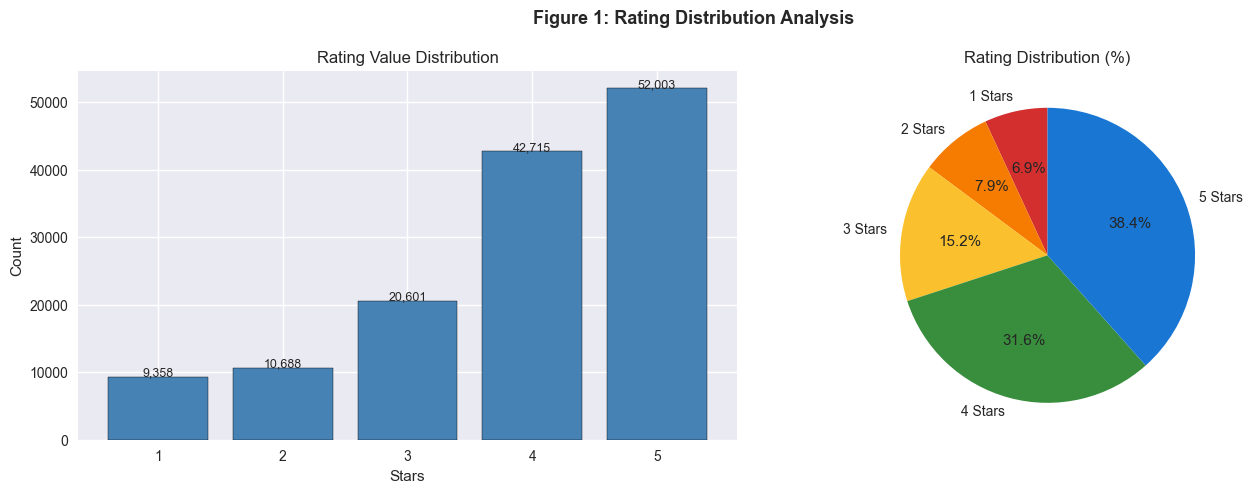

Figure 1 saved.

4.3 USER ACTIVITY ANALYSIS


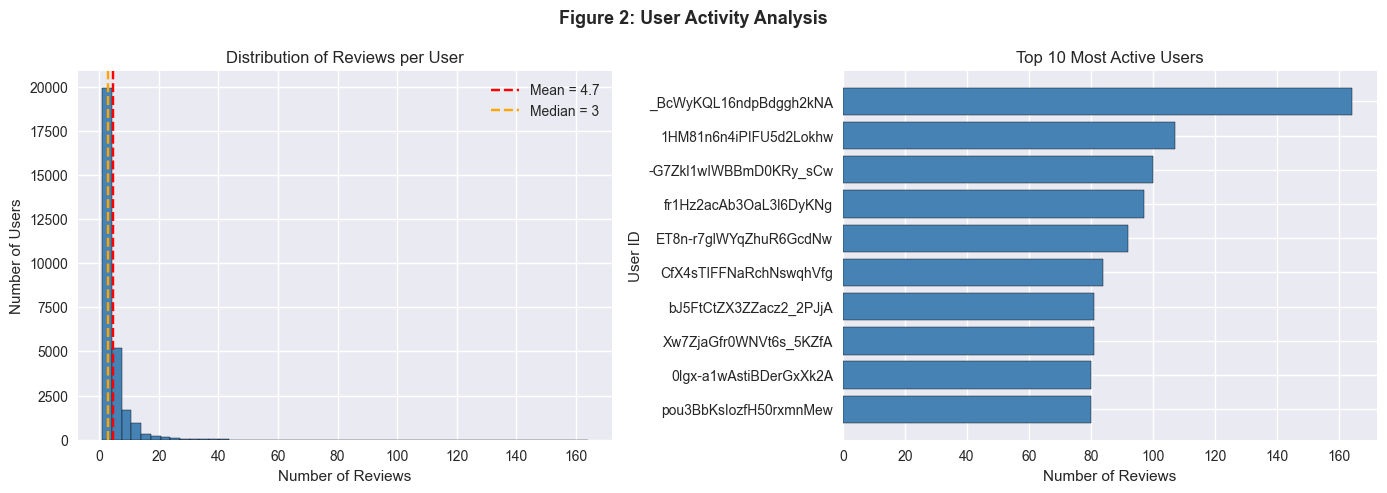

Figure 2 saved.

4.4 BUSINESS POPULARITY ANALYSIS


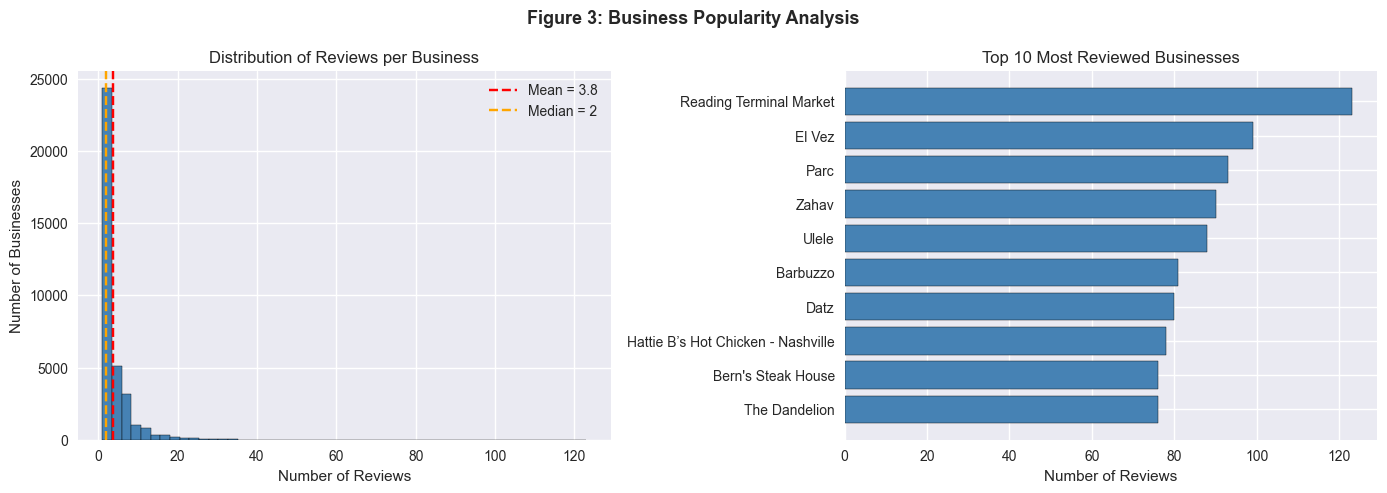

Figure 3 saved.

4.5 CATEGORY ANALYSIS

Top 20 business categories:
categories
Restaurants                  23205
Food                          9683
Nightlife                     6502
Bars                          6114
American (Traditional)        4546
American (New)                3750
Sandwiches                    3457
Breakfast & Brunch            3422
Shopping                      3014
Event Planning & Services     2803
Pizza                         2750
Coffee & Tea                  2428
Italian                       2328
Burgers                       2267
Mexican                       2151
Seafood                       2078
Beauty & Spas                 2015
Salad                         1744
Arts & Entertainment          1668
Fast Food                     1648
Name: count, dtype: int64


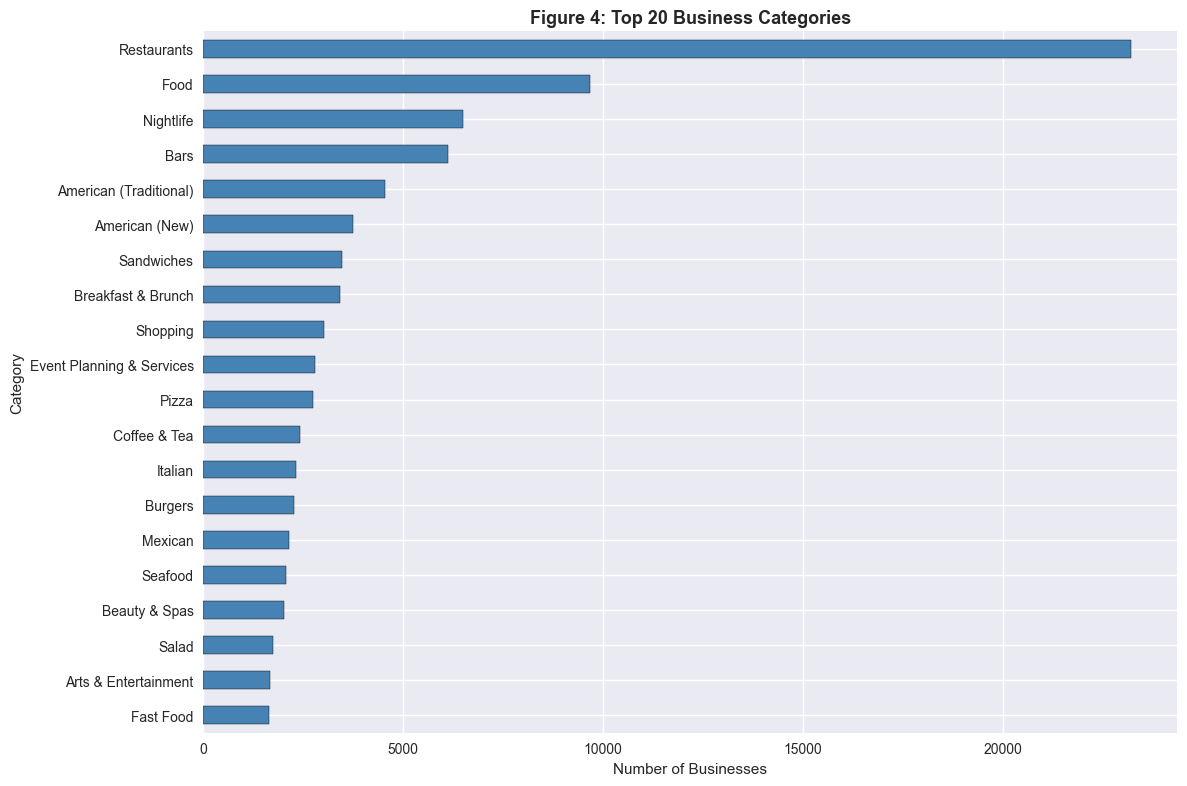

Figure 4 saved.

Average rating per top 10 category:
                 category  avg_rating
                     Food    3.936123
                 Shopping    3.908776
               Sandwiches    3.904568
Event Planning & Services    3.893643
       Breakfast & Brunch    3.888309
           American (New)    3.869214
                     Bars    3.856637
              Restaurants    3.850743
                Nightlife    3.848623
   American (Traditional)    3.728757

4.6 GEOGRAPHIC ANALYSIS

Top 10 states by reviewed businesses:
state
PA    8576
FL    6097
TN    2886
IN    2879
LA    2836
MO    2683
AZ    2345
NV    2145
NJ    1566
CA    1277
Name: count, dtype: int64

Top 10 cities by reviewed businesses:
city
Philadelphia     4621
Tampa            2304
Tucson           2180
New Orleans      2059
Indianapolis     2026
Nashville        1937
Reno             1691
Saint Louis      1277
Santa Barbara     918
Edmonton          806
Name: count, dtype: int64

Average rating by top 10 states:

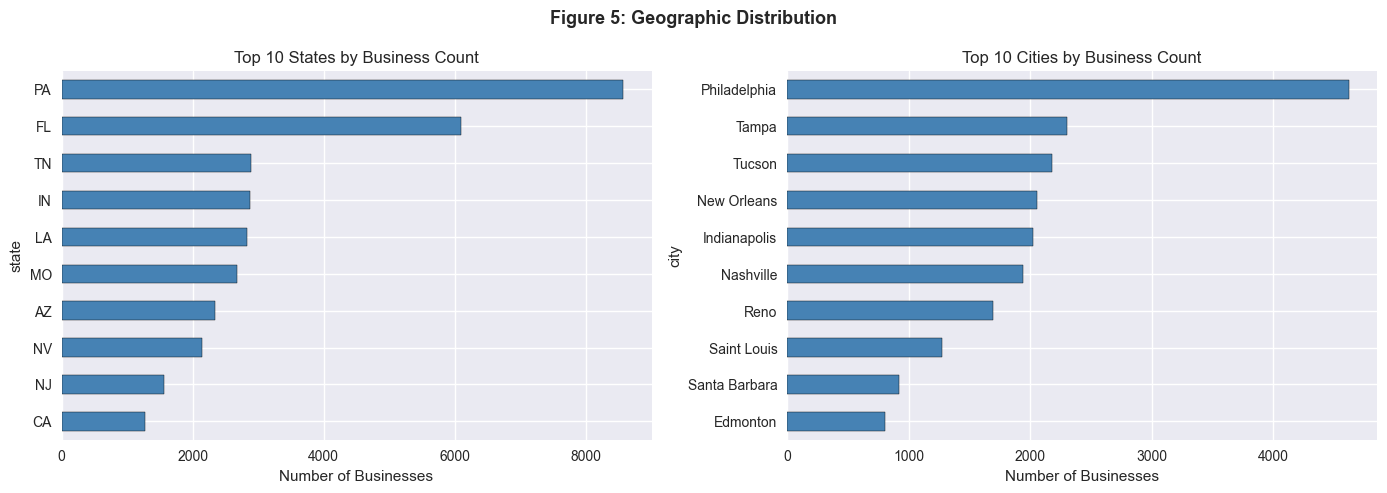

Figure 5 saved.

4.7 USER ENGAGEMENT ANALYSIS

Elite users    : 12,579 (43.9%)
Non-elite users: 16,045 (56.1%)

Average rating - Elite users    : 3.964
Average rating - Non-elite users: 3.728

Useful votes per review stats:
count    135365.000
mean          1.835
std           3.814
min           0.000
25%           0.000
50%           1.000
75%           2.000
max         179.000
Name: useful, dtype: float64


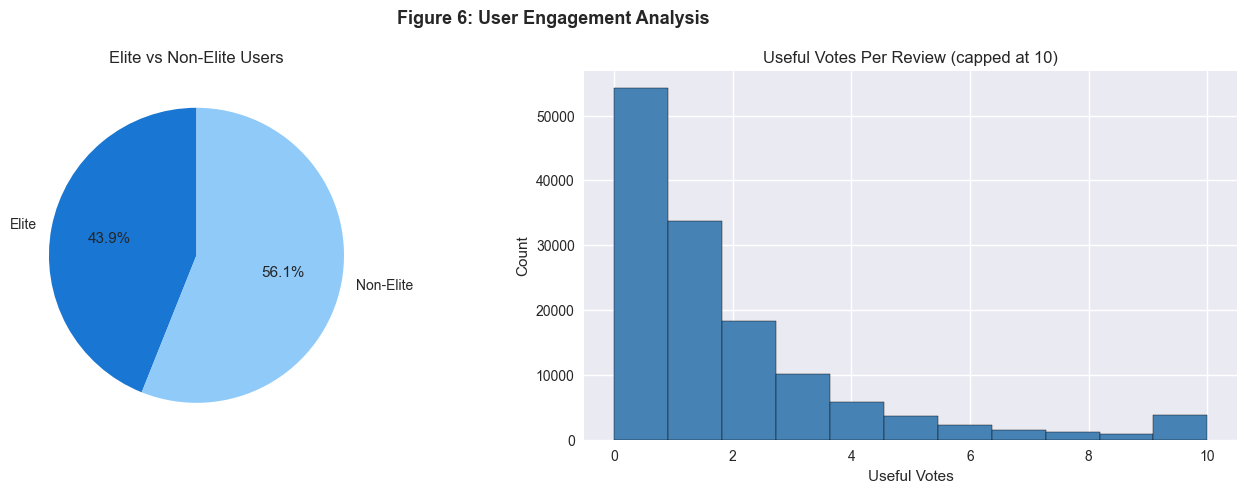

Figure 6 saved.

4.8 CORRELATION ANALYSIS

Correlation matrix:
               stars  review_useful  funny   cool  review_count  average_stars   fans  is_elite
stars          1.000         -0.016 -0.027  0.098         0.009          0.393  0.025     0.097
review_useful -0.016          1.000  0.641  0.848         0.243          0.042  0.314     0.193
funny         -0.027          0.641  1.000  0.681         0.186          0.005  0.238     0.112
cool           0.098          0.848  0.681  1.000         0.247          0.082  0.319     0.188
review_count   0.009          0.243  0.186  0.247         1.000          0.020  0.547     0.294
average_stars  0.393          0.042  0.005  0.082         0.020          1.000  0.056     0.256
fans           0.025          0.314  0.238  0.319         0.547          0.056  1.000     0.170
is_elite       0.097          0.193  0.112  0.188         0.294          0.256  0.170     1.000


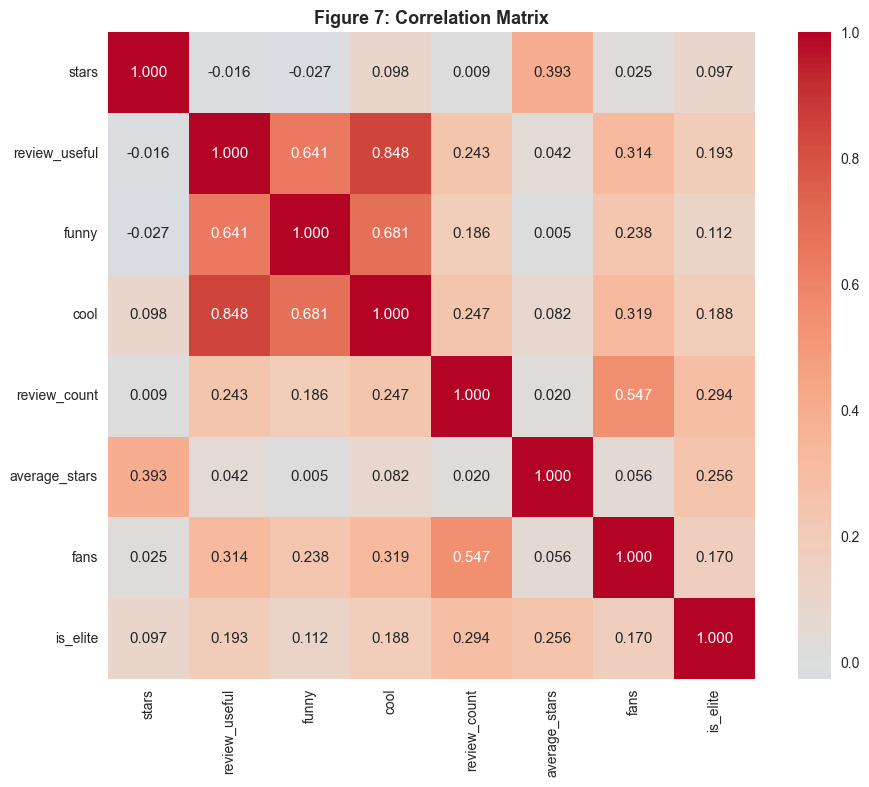

Figure 7 saved.

4.9 SPARSITY ANALYSIS

Number of users        : 28,624
Number of businesses   : 35,721
Actual reviews         : 135,365
Possible combinations  : 1,022,477,904
Sparsity               : 99.9868%
Density                : 0.0132%

4.10 USER AND ITEM BIAS

Global mean rating : 3.8667

-- User Bias --
Mean : -0.0205
Std  : 0.8477
Min  : -2.8667
Max  : 1.1333

-- Item (Business) Bias --
Mean : -0.0881
Std  : 1.0445
Min  : -2.8667
Max  : 1.1333


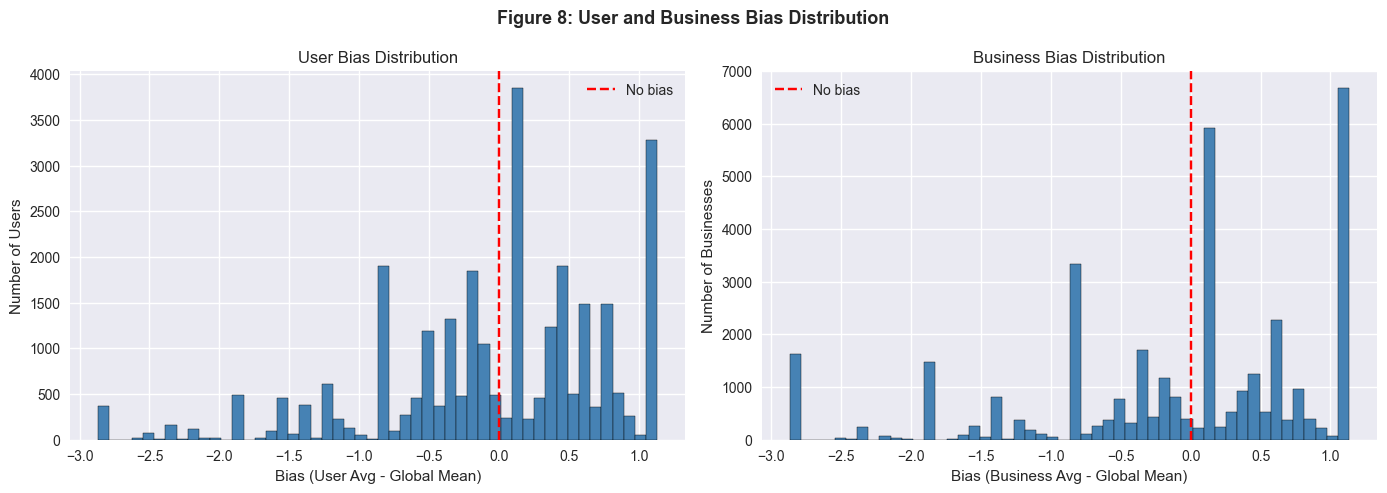

Figure 8 saved.

4.11 TEMPORAL PATTERNS

-- Reviews Per Year --
year
2005       15
2006      117
2007      482
2008     1711
2009     2196
2010     4093
2011     6525
2012     7423
2013     9682
2014    11195
2015    13615
2016    14156
2017    15174
2018    15720
2019    14808
2020     9030
2021     8998
2022      425
Name: stars, dtype: int64

-- Average Rating Per Year --
year
2005    4.067
2006    3.974
2007    3.786
2008    3.776
2009    3.721
2010    3.724
2011    3.734
2012    3.726
2013    3.749
2014    3.800
2015    3.830
2016    3.867
2017    3.895
2018    3.938
2019    3.943
2020    4.032
2021    3.993
2022    3.979
Name: stars, dtype: float64

-- Reviews Per Month --
month
1     12594
2     11129
3     11667
4     10725
5     11101
6     11323
7     12017
8     11874
9     10793
10    10684
11    10617
12    10841
Name: stars, dtype: int64


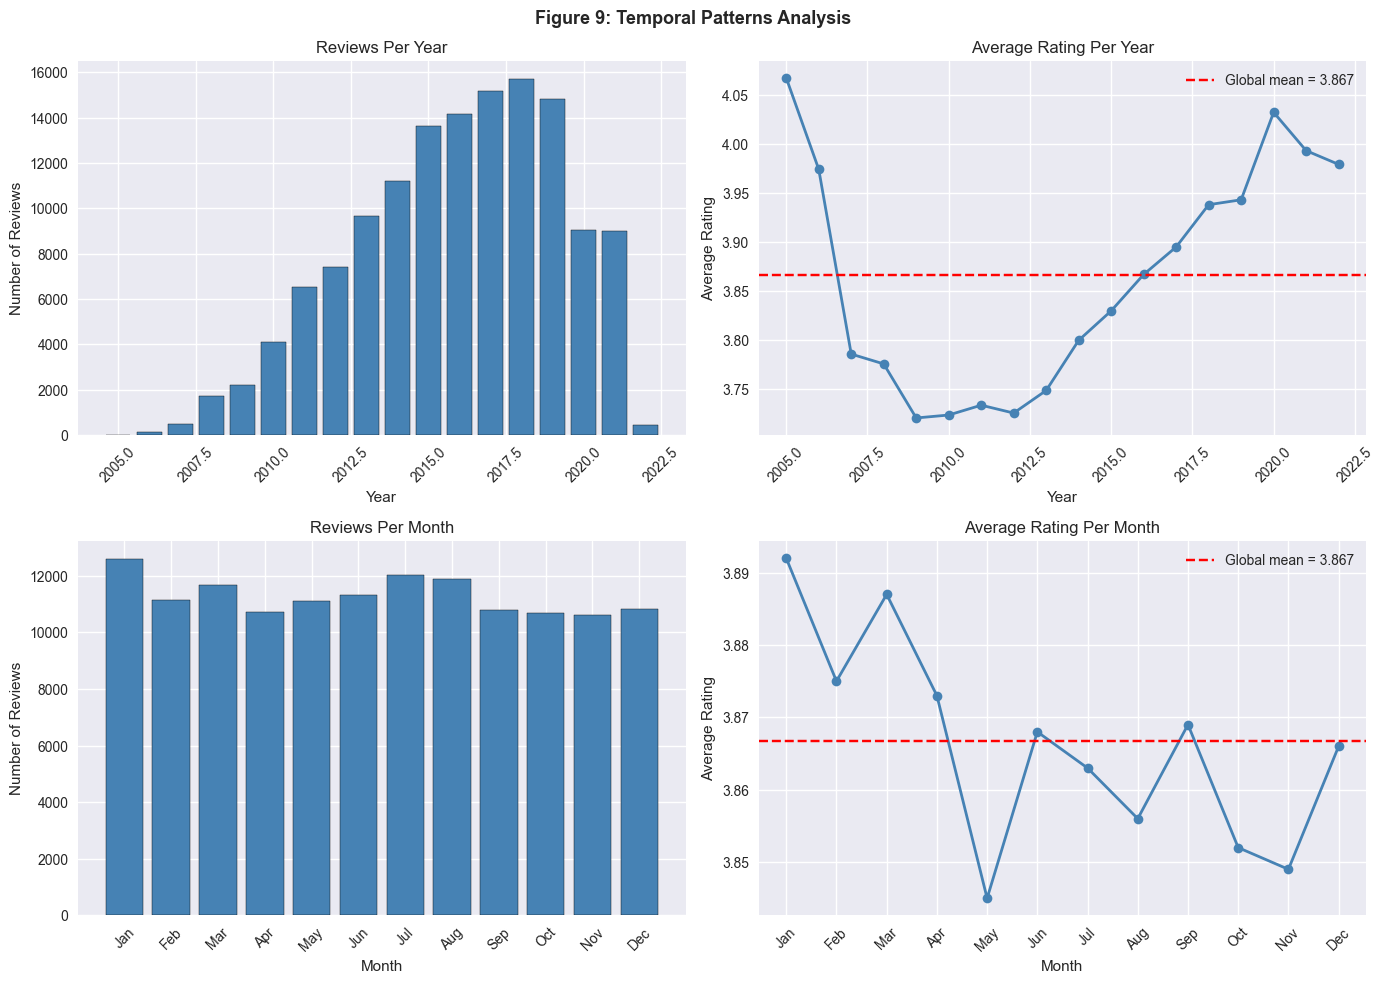

Figure 9 saved.

-- Yearly Summary --
      total_reviews  unique_users  unique_businesses  avg_rating
year                                                            
2005             15             8                 15       4.067
2006            117            59                113       3.974
2007            482           188                439       3.786
2008           1711           603               1410       3.776
2009           2196          1022               1709       3.721
2010           4093          1909               3017       3.724
2011           6525          3067               4585       3.734
2012           7423          3654               5295       3.726
2013           9682          4785               6708       3.749
2014          11195          5991               7633       3.800
2015          13615          7359               9096       3.830
2016          14156          7892               9567       3.867
2017          15174          8443              10036

In [5]:
# =============================================================
# STEP 4: EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================
# 4.1  Descriptive statistics
# 4.2  Rating distribution
# 4.3  User activity analysis
# 4.4  Business popularity analysis
# 4.5  Category analysis
# 4.6  Geographic analysis
# 4.7  User engagement analysis
# 4.8  Correlation analysis
# 4.9  Sparsity analysis
# 4.10 User and item bias
# 4.11 Temporal patterns
# =============================================================

# set plot style and default figure parameters
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# -------------------------------------------------------------
# 4.1 DESCRIPTIVE STATISTICS
# -------------------------------------------------------------
print("=" * 55)
print("4.1 DESCRIPTIVE STATISTICS")
print("=" * 55)

# print summary statistics for key review columns
print("\n-- Review Statistics --")
print(review_clean[['stars', 'useful',
                     'funny', 'cool']].describe().round(3))

# print summary statistics for key user columns
print("\n-- User Statistics --")
print(users[['review_count', 'average_stars',
             'useful', 'fans']].describe().round(3))

# print summary statistics for key business columns
print("\n-- Business Statistics --")
print(business[['stars', 'review_count']].describe().round(3))

# print high-level dataset facts
print("\n-- Key Facts --")
print(f"Total reviews      : {len(review_clean):,}")
print(f"Unique users       : "
      f"{review_clean['user_id'].nunique():,}")
print(f"Unique businesses  : "
      f"{review_clean['business_id'].nunique():,}")
print(f"Average rating     : "
      f"{review_clean['stars'].mean():.3f}")
print(f"Median rating      : "
      f"{review_clean['stars'].median():.1f}")
print(f"Std deviation      : "
      f"{review_clean['stars'].std():.3f}")
print(f"Skewness           : "
      f"{review_clean['stars'].skew():.3f}")
print(f"Kurtosis           : "
      f"{review_clean['stars'].kurt():.3f}")

# compute review count per user
reviews_per_user = review_clean.groupby(
    'user_id')['stars'].count()

# print per-user review count statistics
print(f"\n-- Reviews Per User --")
print(f"Min    : {reviews_per_user.min()}")
print(f"Max    : {reviews_per_user.max()}")
print(f"Mean   : {reviews_per_user.mean():.1f}")
print(f"Median : {reviews_per_user.median():.1f}")
print(f"Std    : {reviews_per_user.std():.1f}")

# compute review count per business
reviews_per_biz = review_clean.groupby(
    'business_id')['stars'].count()

# print per-business review count statistics
print(f"\n-- Reviews Per Business --")
print(f"Min    : {reviews_per_biz.min()}")
print(f"Max    : {reviews_per_biz.max()}")
print(f"Mean   : {reviews_per_biz.mean():.1f}")
print(f"Median : {reviews_per_biz.median():.1f}")
print(f"Std    : {reviews_per_biz.std():.1f}")

# compute average rating per business
avg_rating_per_biz = review_clean.groupby(
    'business_id')['stars'].mean()

# print per-business average rating statistics
print(f"\n-- Average Rating Per Business --")
print(f"Min    : {avg_rating_per_biz.min():.3f}")
print(f"Max    : {avg_rating_per_biz.max():.3f}")
print(f"Mean   : {avg_rating_per_biz.mean():.3f}")
print(f"Std    : {avg_rating_per_biz.std():.3f}")

# compute average rating per user
avg_rating_per_user = review_clean.groupby(
    'user_id')['stars'].mean()

# print per-user average rating statistics
print(f"\n-- Average Rating Per User --")
print(f"Min    : {avg_rating_per_user.min():.3f}")
print(f"Max    : {avg_rating_per_user.max():.3f}")
print(f"Mean   : {avg_rating_per_user.mean():.3f}")
print(f"Std    : {avg_rating_per_user.std():.3f}")

# -------------------------------------------------------------
# 4.2 RATING DISTRIBUTION
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("4.2 RATING DISTRIBUTION")
print("=" * 55)

# count and compute percentage for each star rating
rating_counts = review_clean['stars'].value_counts().sort_index()
rating_pct    = (rating_counts / len(review_clean) * 100).round(2)

# print count and percentage for each star value
print("\nRating value counts and percentages:")
for r in sorted(review_clean['stars'].unique()):
    print(f"  Rating {r:.0f} : "
          f"{rating_counts[r]:,} ({rating_pct[r]:.2f}%)")

# create two-panel rating distribution figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left panel: bar chart of rating counts
axes[0].bar(rating_counts.index,
            rating_counts.values,
            color='steelblue', edgecolor='black')
axes[0].set_title('Rating Value Distribution')
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Count')
axes[0].set_xticks([1, 2, 3, 4, 5])
for i, v in enumerate(rating_counts.values):
    # annotate each bar with its count
    axes[0].text(i + 1, v + 100,
                 f'{v:,}', ha='center', fontsize=9)

# right panel: pie chart of rating percentages
axes[1].pie(rating_counts.values,
            labels=[f'{r:.0f} Stars'
                    for r in rating_counts.index],
            autopct='%1.1f%%', startangle=90,
            colors=['#d32f2f', '#f57c00', '#fbc02d',
                    '#388e3c', '#1976d2'])
axes[1].set_title('Rating Distribution (%)')

# set overall figure title and save
plt.suptitle('Figure 1: Rating Distribution Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_yelp_rating_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

# -------------------------------------------------------------
# 4.3 USER ACTIVITY ANALYSIS
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("4.3 USER ACTIVITY ANALYSIS")
print("=" * 55)

# create two-panel user activity figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left panel: histogram of reviews per user
axes[0].hist(reviews_per_user.values, bins=50,
             color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Reviews per User')
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Number of Users')
axes[0].axvline(reviews_per_user.mean(), color='red',
                linestyle='--',
                label=f'Mean = {reviews_per_user.mean():.1f}')
axes[0].axvline(reviews_per_user.median(), color='orange',
                linestyle='--',
                label=f'Median = {reviews_per_user.median():.0f}')
axes[0].legend()

# right panel: horizontal bar chart of top 10 most active users
top_users = reviews_per_user.sort_values(
    ascending=False).head(10)
axes[1].barh(top_users.index.astype(str),
             top_users.values,
             color='steelblue', edgecolor='black')
axes[1].set_title('Top 10 Most Active Users')
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('User ID')
axes[1].invert_yaxis()  # highest count at the top

# set overall figure title and save
plt.suptitle('Figure 2: User Activity Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_yelp_user_activity.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

# -------------------------------------------------------------
# 4.4 BUSINESS POPULARITY ANALYSIS
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("4.4 BUSINESS POPULARITY ANALYSIS")
print("=" * 55)

# create two-panel business popularity figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left panel: histogram of reviews per business
axes[0].hist(reviews_per_biz.values, bins=50,
             color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Reviews per Business')
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Number of Businesses')
axes[0].axvline(reviews_per_biz.mean(), color='red',
                linestyle='--',
                label=f'Mean = {reviews_per_biz.mean():.1f}')
axes[0].axvline(reviews_per_biz.median(), color='orange',
                linestyle='--',
                label=f'Median = {reviews_per_biz.median():.0f}')
axes[0].legend()

# right panel: horizontal bar chart of top 10 most reviewed businesses
top_biz      = reviews_per_biz.sort_values(ascending=False).head(10)
top_biz_names = business.set_index(
    'business_id').loc[top_biz.index, 'name']  # look up business names
axes[1].barh(top_biz_names.values,
             top_biz.values,
             color='steelblue', edgecolor='black')
axes[1].set_title('Top 10 Most Reviewed Businesses')
axes[1].set_xlabel('Number of Reviews')
axes[1].invert_yaxis()  # highest count at the top

# set overall figure title and save
plt.suptitle('Figure 3: Business Popularity Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_yelp_business_popularity.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

# -------------------------------------------------------------
# 4.5 CATEGORY ANALYSIS
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("4.5 CATEGORY ANALYSIS")
print("=" * 55)

# filter business table to only those present in review_clean
reviewed_biz_ids  = set(review_clean['business_id'].unique())
reviewed_business = business[
    business['business_id'].isin(reviewed_biz_ids)
].copy()

# split pipe-separated category strings and count frequencies
cat_series = reviewed_business['categories'].str.split(', ').explode()
cat_counts = cat_series.value_counts().head(20)

# print top 20 category counts
print("\nTop 20 business categories:")
print(cat_counts)

# plot horizontal bar chart of top 20 categories
fig, ax = plt.subplots(figsize=(12, 8))
cat_counts.sort_values().plot(
    kind='barh', ax=ax,
    color='steelblue', edgecolor='black'
)
ax.set_title('Figure 4: Top 20 Business Categories',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Businesses')
ax.set_ylabel('Category')
plt.tight_layout()
plt.savefig('fig4_yelp_categories.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

# compute average rating for each of the top 10 categories
print("\nAverage rating per top 10 category:")
top_cats   = cat_counts.head(10).index.tolist()
cat_ratings = []

for cat in top_cats:
    # find businesses belonging to this category
    cat_biz_ids = reviewed_business[
        reviewed_business['categories'].str.contains(
            cat, na=False, regex=False)
    ]['business_id'].tolist()

    # compute mean star rating for reviews of these businesses
    avg_r = review_clean[
        review_clean['business_id'].isin(cat_biz_ids)
    ]['stars'].mean()
    cat_ratings.append((cat, avg_r))

# build and print category average rating DataFrame
cat_rating_df = pd.DataFrame(
    cat_ratings, columns=['category', 'avg_rating']
).sort_values('avg_rating', ascending=False)
print(cat_rating_df.to_string(index=False))

# -------------------------------------------------------------
# 4.6 GEOGRAPHIC ANALYSIS
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("4.6 GEOGRAPHIC ANALYSIS")
print("=" * 55)

# count reviewed businesses per state and print top 10
state_counts = reviewed_business['state'].value_counts().head(10)
print("\nTop 10 states by reviewed businesses:")
print(state_counts)

# count reviewed businesses per city and print top 10
city_counts = reviewed_business['city'].value_counts().head(10)
print("\nTop 10 cities by reviewed businesses:")
print(city_counts)

# compute average star rating per state for top 10 states
state_avg_rating = review_clean.merge(
    business[['business_id', 'state']], on='business_id'
).groupby('state')['stars'].mean().sort_values(
    ascending=False).head(10).round(3)
print("\nAverage rating by top 10 states:")
print(state_avg_rating)

# create two-panel geographic distribution figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left panel: top 10 states by business count
state_counts.sort_values().plot(
    kind='barh', ax=axes[0],
    color='steelblue', edgecolor='black'
)
axes[0].set_title('Top 10 States by Business Count')
axes[0].set_xlabel('Number of Businesses')

# right panel: top 10 cities by business count
city_counts.sort_values().plot(
    kind='barh', ax=axes[1],
    color='steelblue', edgecolor='black'
)
axes[1].set_title('Top 10 Cities by Business Count')
axes[1].set_xlabel('Number of Businesses')

# set overall figure title and save
plt.suptitle('Figure 5: Geographic Distribution',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_yelp_geographic.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 saved.")

# -------------------------------------------------------------
# 4.7 USER ENGAGEMENT ANALYSIS
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("4.7 USER ENGAGEMENT ANALYSIS")
print("=" * 55)

# filter users table to only those present in review_clean
active_users = users[
    users['user_id'].isin(review_clean['user_id'].unique())
].copy()

# create binary elite flag: 1 if user has any elite years, else 0
active_users['is_elite'] = (
    active_users['elite'] != '').astype(int)
elite_count     = active_users['is_elite'].sum()
non_elite_count = len(active_users) - elite_count

# print elite vs non-elite user counts and percentages
print(f"\nElite users    : {elite_count:,} "
      f"({elite_count/len(active_users)*100:.1f}%)")
print(f"Non-elite users: {non_elite_count:,} "
      f"({non_elite_count/len(active_users)*100:.1f}%)")

# compute average rating separately for elite and non-elite users
elite_avg = review_clean.merge(
    active_users[['user_id', 'is_elite']], on='user_id'
).groupby('is_elite')['stars'].mean().round(3)
print(f"\nAverage rating - Elite users    : "
      f"{elite_avg.get(1, 'N/A')}")
print(f"Average rating - Non-elite users: "
      f"{elite_avg.get(0, 'N/A')}")

# print useful vote distribution summary
print(f"\nUseful votes per review stats:")
print(review_clean['useful'].describe().round(3))

# create two-panel user engagement figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left panel: elite vs non-elite pie chart
axes[0].pie([elite_count, non_elite_count],
            labels=['Elite', 'Non-Elite'],
            autopct='%1.1f%%', startangle=90,
            colors=['#1976d2', '#90caf9'])
axes[0].set_title('Elite vs Non-Elite Users')

# right panel: useful votes histogram capped at 10 for readability
useful_capped = review_clean['useful'].clip(upper=10)
axes[1].hist(useful_capped.values, bins=11,
             color='steelblue', edgecolor='black')
axes[1].set_title('Useful Votes Per Review (capped at 10)')
axes[1].set_xlabel('Useful Votes')
axes[1].set_ylabel('Count')

# set overall figure title and save
plt.suptitle('Figure 6: User Engagement Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_yelp_user_engagement.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 6 saved.")

# -------------------------------------------------------------
# 4.8 CORRELATION ANALYSIS
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("4.8 CORRELATION ANALYSIS")
print("=" * 55)

# merge review data with selected user features for correlation
review_users = review_clean.merge(
    active_users[['user_id', 'review_count',
                  'average_stars', 'fans',
                  'is_elite', 'useful']],
    on='user_id'
)

# rename useful_x to distinguish review-level useful from user-level
review_users = review_users.rename(
    columns={'useful_x': 'review_useful'}
)

# define columns to include in the correlation matrix
corr_cols = ['stars', 'review_useful', 'funny', 'cool',
             'review_count', 'average_stars',
             'fans', 'is_elite']

# compute pairwise correlation matrix
corr_matrix = review_users[corr_cols].corr().round(3)
print("\nCorrelation matrix:")
print(corr_matrix)

# plot heatmap of correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f',
            cmap='coolwarm', center=0,
            square=True, ax=ax)
ax.set_title('Figure 7: Correlation Matrix',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_yelp_correlation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7 saved.")

# -------------------------------------------------------------
# 4.9 SPARSITY ANALYSIS
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("4.9 SPARSITY ANALYSIS")
print("=" * 55)

# compute dimensions and fill rate of the user-item matrix
n_users_clean   = review_clean['user_id'].nunique()
n_biz_clean     = review_clean['business_id'].nunique()
n_reviews_clean = len(review_clean)
possible        = n_users_clean * n_biz_clean          # total possible entries
sparsity        = 1 - (n_reviews_clean / possible)     # fraction of empty entries

# print sparsity summary
print(f"\nNumber of users        : {n_users_clean:,}")
print(f"Number of businesses   : {n_biz_clean:,}")
print(f"Actual reviews         : {n_reviews_clean:,}")
print(f"Possible combinations  : {possible:,}")
print(f"Sparsity               : {sparsity:.4%}")
print(f"Density                : {1 - sparsity:.4%}")

# -------------------------------------------------------------
# 4.10 USER AND ITEM BIAS
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("4.10 USER AND ITEM BIAS")
print("=" * 55)

# compute global mean rating across all reviews
global_mean_yelp = review_clean['stars'].mean()
print(f"\nGlobal mean rating : {global_mean_yelp:.4f}")

# compute user bias as deviation from global mean
user_bias_yelp = avg_rating_per_user - global_mean_yelp
print(f"\n-- User Bias --")
print(f"Mean : {user_bias_yelp.mean():.4f}")
print(f"Std  : {user_bias_yelp.std():.4f}")
print(f"Min  : {user_bias_yelp.min():.4f}")
print(f"Max  : {user_bias_yelp.max():.4f}")

# compute item (business) bias as deviation from global mean
item_bias_yelp = avg_rating_per_biz - global_mean_yelp
print(f"\n-- Item (Business) Bias --")
print(f"Mean : {item_bias_yelp.mean():.4f}")
print(f"Std  : {item_bias_yelp.std():.4f}")
print(f"Min  : {item_bias_yelp.min():.4f}")
print(f"Max  : {item_bias_yelp.max():.4f}")

# create two-panel bias distribution figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left panel: user bias histogram
axes[0].hist(user_bias_yelp.values, bins=50,
             color='steelblue', edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--',
                label='No bias')              # zero bias reference line
axes[0].set_title('User Bias Distribution')
axes[0].set_xlabel('Bias (User Avg - Global Mean)')
axes[0].set_ylabel('Number of Users')
axes[0].legend()

# right panel: business bias histogram
axes[1].hist(item_bias_yelp.values, bins=50,
             color='steelblue', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--',
                label='No bias')              # zero bias reference line
axes[1].set_title('Business Bias Distribution')
axes[1].set_xlabel('Bias (Business Avg - Global Mean)')
axes[1].set_ylabel('Number of Businesses')
axes[1].legend()

# set overall figure title and save
plt.suptitle('Figure 8: User and Business Bias Distribution',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_yelp_bias.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 8 saved.")

# -------------------------------------------------------------
# 4.11 TEMPORAL PATTERNS
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("4.11 TEMPORAL PATTERNS")
print("=" * 55)

# compute review count and average rating per year
reviews_per_year = review_clean.groupby('year')['stars'].count()
avg_rating_year  = review_clean.groupby('year')['stars'].mean().round(3)

# print yearly review counts and average ratings
print("\n-- Reviews Per Year --")
print(reviews_per_year)
print("\n-- Average Rating Per Year --")
print(avg_rating_year)

# compute review count and average rating per month
reviews_per_month = review_clean.groupby('month')['stars'].count()
avg_rating_month  = review_clean.groupby('month')['stars'].mean().round(3)

# print monthly review counts
print("\n-- Reviews Per Month --")
print(reviews_per_month)

# create 2x2 temporal pattern figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# top-left: bar chart of reviews per year
axes[0, 0].bar(reviews_per_year.index,
               reviews_per_year.values,
               color='steelblue', edgecolor='black')
axes[0, 0].set_title('Reviews Per Year')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Number of Reviews')
axes[0, 0].tick_params(axis='x', rotation=45)

# top-right: line chart of average rating per year
axes[0, 1].plot(avg_rating_year.index,
                avg_rating_year.values,
                marker='o', color='steelblue', linewidth=2)
axes[0, 1].axhline(global_mean_yelp, color='red',
                   linestyle='--',
                   label=f'Global mean = {global_mean_yelp:.3f}')
axes[0, 1].set_title('Average Rating Per Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Average Rating')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=45)

# define abbreviated month labels for x-axis
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# bottom-left: bar chart of reviews per month
axes[1, 0].bar(reviews_per_month.index,
               reviews_per_month.values,
               color='steelblue', edgecolor='black')
axes[1, 0].set_title('Reviews Per Month')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Number of Reviews')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(month_names, rotation=45)

# bottom-right: line chart of average rating per month
axes[1, 1].plot(avg_rating_month.index,
                avg_rating_month.values,
                marker='o', color='steelblue', linewidth=2)
axes[1, 1].axhline(global_mean_yelp, color='red',
                   linestyle='--',
                   label=f'Global mean = {global_mean_yelp:.3f}')
axes[1, 1].set_title('Average Rating Per Month')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Average Rating')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticklabels(month_names, rotation=45)
axes[1, 1].legend()

# set overall figure title and save
plt.suptitle('Figure 9: Temporal Patterns Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_yelp_temporal.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 9 saved.")

# compute and print yearly summary aggregating key metrics
print("\n-- Yearly Summary --")
yearly_summary = review_clean.groupby('year').agg(
    total_reviews     = ('stars', 'count'),
    unique_users      = ('user_id', 'nunique'),
    unique_businesses = ('business_id', 'nunique'),
    avg_rating        = ('stars', 'mean')
).round(3)
print(yearly_summary)

print("\n" + "=" * 55)
print("STEP 4 EDA COMPLETE")
print("=" * 55)

### Step 4: EDA Observations and Insights

#### 4.1 Descriptive Statistics

The clean dataset contains 135,365 reviews from 28,624 users across 35,721 businesses.

| Metric | Value |
|--------|-------|
| Average rating | 3.867 |
| Median rating | 4.0 |
| Std deviation | 1.207 |
| Skewness | -0.956 |
| Kurtosis | -0.008 |

The average rating of 3.867 is notably higher than the MovieLens average of 3.583, and the stronger negative skewness (-0.956 vs -0.554) indicates an even more pronounced positivity bias on Yelp. Users are more selective about which businesses they review and tend to visit places they expect to enjoy, leading to systematically higher ratings.

Reviews per user are very low (Mean: 4.7, Median: 3.0), confirming the extreme sparsity characteristic of Yelp data. Reviews per business are similarly low (Mean: 3.8, Median: 2.0), making this a fundamentally different modelling challenge compared to MovieLens.

#### 4.2 Rating Distribution

| Rating | Count | Percentage |
|--------|-------|------------|
| 1 Star | 9,358 | 6.91% |
| 2 Stars | 10,688 | 7.90% |
| 3 Stars | 20,601 | 15.22% |
| 4 Stars | 42,715 | 31.56% |
| 5 Stars | 52,003 | 38.42% |

Ratings 4 and 5 together account for 70.0% of all reviews, significantly higher than MovieLens (57.5%). This strong positivity bias is characteristic of Yelp where users typically choose to review businesses they have already decided to visit, creating a selection bias toward higher ratings. This has important implications for the classification threshold in Technique C.

#### 4.3 User Activity Analysis

The distribution of reviews per user is extremely right-skewed with a mean of 4.7 but a median of only 3.0. The most active user wrote 164 reviews in the sample. This extreme concentration of activity in a small number of power users is more pronounced than in MovieLens and creates significant challenges for collaborative filtering approaches.

#### 4.4 Business Popularity Analysis

Business popularity also follows a strong long-tail distribution with a mean of 3.8 and a median of only 2 reviews per business. The most reviewed business (Reading Terminal Market) received 123 reviews in the sample. The top businesses are predominantly restaurants and food establishments in Philadelphia and Tampa, consistent with the geographic distribution.

#### 4.5 Category Analysis

Restaurants (23,205 businesses) dominate the Yelp catalog, followed by Food (9,683) and Nightlife (6,502). Together, restaurants and food businesses account for approximately 48% of all reviewed businesses, confirming that Yelp is primarily a food and dining recommendation platform.

The highest-rated categories are not restaurants but Food (3.936), Shopping (3.909) and Sandwiches (3.905), while American (Traditional) receives the lowest average rating (3.729) despite being the 5th most common category. This category-level quality variation is directly useful for content-based feature engineering in Technique B.

#### 4.6 Geographic Analysis

Pennsylvania (PA) leads with 8,576 businesses, followed by Florida (FL) with 6,097. Philadelphia is the dominant city with 4,621 businesses, more than double the second city Tampa (2,304). Indiana (IN) has the highest average rating (4.009) while Arizona (AZ) has the lowest among top states (3.793).

The geographic concentration in specific US cities means that location is a meaningful feature for content-based recommendations. Users in Philadelphia are likely to prefer Philadelphia businesses and vice versa.

#### 4.7 User Engagement Analysis

A notably high 43.9% of active users in the sample are elite users. Elite users rate slightly higher on average (3.964) compared to non-elite users (3.728), a difference of 0.236 stars. This suggests elite status is associated with a more positive reviewing tendency, possibly due to selection effects, as elite users tend to visit higher quality establishments.

The useful vote distribution is heavily right-skewed. Most reviews receive 0-1 useful votes (median: 1) but some receive up to 179, indicating that a small number of reviews are particularly valuable to the community. Useful votes serve as an implicit quality signal for review content.

#### 4.8 Correlation Analysis

Key correlations with star rating:

| Variable | Correlation with Stars |
|---------|----------------------|
| average_stars | 0.393 (strongest) |
| is_elite | 0.097 |
| cool votes | 0.098 |
| review_useful | -0.016 (near zero) |
| funny | -0.027 (near zero) |

The strongest predictor of a review's star rating is the user's average_stars (0.393). Users who generally rate highly continue to rate highly. This is the user bias effect identified in section 4.10 and confirms that user bias correction is essential for both Technique B and Technique C models.

The strong correlations between useful, funny and cool votes (0.641 to 0.848) indicate these engagement signals are highly collinear. Reviews that receive one type of vote tend to receive all types. This means only one of these features needs to be included to capture the engagement signal.

#### 4.9 Sparsity Analysis

| Metric | Yelp | MovieLens |
|--------|------|-----------|
| Users | 28,624 | 6,040 |
| Items | 35,721 | 3,260 |
| Ratings | 135,365 | 998,539 |
| Sparsity | 99.99% | 94.93% |
| Density | 0.013% | 5.07% |

The Yelp user-item matrix is 99.99% sparse, dramatically more sparse than MovieLens. This extreme sparsity means that pure collaborative filtering approaches will struggle, as most user-business pairs share no common reviewers for similarity calculation. This directly justifies the use of content-based filtering (Technique B), which does not rely on shared ratings but instead uses item and user feature vectors.

#### 4.10 User and Item Bias

The global mean rating is 3.8667.

User bias ranges from -2.867 to +1.133, indicating large systematic differences in how users rate. The bimodal-like distribution (Figure 8) shows two groups: users who rate at the minimum (1 star only, creating strong negative bias) and users who rate at the maximum (5 stars only, creating strong positive bias). This extreme polarization is more pronounced than in MovieLens and reflects the more expressive nature of Yelp reviews, where users are more likely to review exceptional or terrible experiences.

Business bias ranges from -2.867 to +1.133, with a strong spike near +1.133 indicating many businesses consistently receive 5-star ratings. This is the floor and ceiling effect of the 1-5 rating scale. Businesses that only receive extreme ratings produce extreme bias values.

#### 4.11 Temporal Patterns

Review volume grew steadily from 2005 to a peak in 2018 (15,720 reviews) before declining in 2020 (9,030), likely reflecting the COVID-19 pandemic impact on restaurant visits. The recovery in 2021 (8,998) is partial.

Average ratings show a clear U-shaped pattern over time: declining from 4.067 in 2005 to a trough of 3.721 in 2009, then rising steadily to 4.032 in 2020. This U-shape likely reflects platform maturity effects. Early Yelp users were enthusiastic early adopters who rated highly, then as the platform grew more mainstream users joined and rated more critically, and review culture later shifted toward more positive engagement.

Monthly patterns are relatively flat (3.849 to 3.893 range) with January showing the highest volume (12,594 reviews), possibly reflecting New Year dining activity, and May showing the lowest average rating (3.849).

#### Summary of Key EDA Insights for Modelling

| Finding | Implication for Modelling |
|---------|--------------------------|
| 99.99% sparsity | Content-based filtering essential (Technique B) |
| Strong positivity bias (70% ratings 4-5) | Use threshold >= 4 for classification |
| average_stars is strongest predictor | Include user bias in all models |
| Category quality varies significantly | Encode categories as weighted features |
| Elite users rate differently | Include elite status as feature |
| Geographic concentration | Include city/state as features |
| Temporal U-shape pattern | Include year as temporal feature |
| Extreme user/item bias | Bias correction critical for UserKNN |

## Step 5: Feature Engineering and Preprocessing

Based on the EDA findings, features are engineered for both content-based (Technique B) and collaborative filtering (Technique C) models.

| Feature Group | Features | Used In |
|---------------|----------|---------|
| Business content | Category encoding, location, stars, is_open | Technique B |
| User profile | avg_stars, review_count, elite, useful, fans | Technique B |
| Bias features | user_bias, item_bias, global_mean | Technique C |
| Temporal | review year, month, days_since_start | Both |
| Engagement | useful, funny, cool votes | Technique B |
| Popularity | business_review_count, user_review_count | Both |
| Scaling | MinMax normalization of all numeric features | Both |

In [6]:
# =============================================================
# STEP 5: FEATURE ENGINEERING AND PREPROCESSING
# =============================================================
# 5.1  Business category encoding
# 5.2  Business location encoding
# 5.3  Business content features
# 5.4  User profile features
# 5.5  Bias features
# 5.6  Temporal features
# 5.7  Checkin features (implicit feedback)
# 5.8  Tip features (implicit feedback)
# 5.9  Feature scaling and normalization
# 5.10 Build final feature tables
# 5.11 Feature summary
# =============================================================

# import MinMaxScaler for feature normalization
from sklearn.preprocessing import MinMaxScaler

# -------------------------------------------------------------
# 5.1 BUSINESS CATEGORY ENCODING
# -------------------------------------------------------------
# categories are the primary content signal for businesses;
# multi-hot encoding is used for the top 20 categories,
# as identified in EDA section 4.5
# -------------------------------------------------------------
print("=" * 55)
print("5.1 BUSINESS CATEGORY ENCODING")
print("=" * 55)

# filter business table to only businesses present in review_clean
reviewed_biz_ids = set(review_clean['business_id'].unique())
business_fe = business[
    business['business_id'].isin(reviewed_biz_ids)
].copy().reset_index(drop=True)

print(f"\nBusinesses in review_clean : {len(business_fe):,}")

# split pipe-separated categories and count frequencies
cat_series  = business_fe['categories'].str.split(', ').explode()
top_20_cats = cat_series.value_counts().head(20).index.tolist()

# print the selected top 20 categories
print(f"\nTop 20 categories selected for encoding:")
print(top_20_cats)

# create a binary indicator column for each top category
for cat in top_20_cats:
    # sanitise category name to create a valid column name
    col_name = 'cat_' + cat.replace(' ', '_').replace(
        '&', 'and').replace('(', '').replace(')', '')
    business_fe[col_name] = business_fe[
        'categories'].str.contains(
        cat, na=False, regex=False).astype(int)

# build list of category column names using the same sanitisation
cat_cols = ['cat_' + c.replace(' ', '_').replace(
    '&', 'and').replace('(', '').replace(')', '')
            for c in top_20_cats]

# print count of category columns and a sample encoding
print(f"\nCategory columns created : {len(cat_cols)}")
print(f"Sample encoding:")
print(business_fe[['name'] + cat_cols[:5]].head(3))

# -------------------------------------------------------------
# 5.2 BUSINESS LOCATION ENCODING
# -------------------------------------------------------------
# EDA showed geographic concentration is meaningful;
# state is label-encoded and top 10 cities are one-hot encoded
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("5.2 BUSINESS LOCATION ENCODING")
print("=" * 55)

# label encode state column into integer codes
state_encoder = LabelEncoder()
business_fe['state_enc'] = state_encoder.fit_transform(
    business_fe['state'].fillna('Unknown')
)
print(f"\nUnique states encoded : "
      f"{business_fe['state'].nunique()}")

# identify the top 10 cities by business count
top_10_cities = business_fe['city'].value_counts(
).head(10).index.tolist()
print(f"Top 10 cities for encoding: {top_10_cities}")

# create a binary indicator column for each top city
for city in top_10_cities:
    col_name = 'city_' + city.replace(' ', '_')
    business_fe[col_name] = (
        business_fe['city'] == city).astype(int)

# build list of city indicator column names
city_cols = ['city_' + c.replace(' ', '_')
             for c in top_10_cities]

# -------------------------------------------------------------
# 5.3 BUSINESS CONTENT FEATURES
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("5.3 BUSINESS CONTENT FEATURES")
print("=" * 55)

# aggregate review-level statistics per business from review_clean
biz_stats = review_clean.groupby('business_id').agg(
    biz_review_count = ('stars', 'count'),    # number of reviews
    biz_avg_rating   = ('stars', 'mean'),     # mean star rating
    biz_std_rating   = ('stars', 'std'),      # rating variability
    biz_useful_sum   = ('useful', 'sum'),     # total useful votes
    biz_funny_sum    = ('funny', 'sum'),      # total funny votes
    biz_cool_sum     = ('cool', 'sum')        # total cool votes
).round(4).reset_index()

# fill NaN std (businesses with one review have undefined std)
biz_stats['biz_std_rating'] = biz_stats[
    'biz_std_rating'].fillna(0)

# merge aggregated business stats into the business feature table
business_fe = business_fe.merge(
    biz_stats, on='business_id', how='left'
)

# print summary of business content features added
print(f"\nBusiness content features added:")
print(f"  biz_review_count, biz_avg_rating, biz_std_rating")
print(f"  biz_useful_sum, biz_funny_sum, biz_cool_sum")
print(f"  is_open, stars (aggregate rating)")
print(f"\nBusiness feature table shape: {business_fe.shape}")

# -------------------------------------------------------------
# 5.4 USER PROFILE FEATURES
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("5.4 USER PROFILE FEATURES")
print("=" * 55)

# filter users to only those present in review_clean
active_user_ids = set(review_clean['user_id'].unique())
users_fe = users[
    users['user_id'].isin(active_user_ids)
].copy().reset_index(drop=True)

print(f"\nActive users in review_clean : {len(users_fe):,}")

# create binary elite flag: 1 if user has any elite years, else 0
users_fe['is_elite'] = (users_fe['elite'] != '').astype(int)

# convert yelping_since to datetime for tenure calculation
users_fe['yelping_since'] = pd.to_datetime(
    users_fe['yelping_since'], errors='coerce'
)

# compute years on platform relative to the dataset end date
reference_date = pd.Timestamp('2022-01-19')
users_fe['years_on_platform'] = (
    (reference_date - users_fe['yelping_since']).dt.days / 365
).round(2)

# clip to non-negative values and fill any NaT results with 0
users_fe['years_on_platform'] = users_fe[
    'years_on_platform'].fillna(0).clip(lower=0)

# aggregate review-level statistics per user from review_clean
user_stats = review_clean.groupby('user_id').agg(
    user_review_count_sample = ('stars', 'count'),   # reviews in sample
    user_avg_rating_sample   = ('stars', 'mean'),    # mean rating given
    user_std_rating_sample   = ('stars', 'std'),     # rating variability
    user_useful_given        = ('useful', 'sum'),    # total useful votes given
    user_funny_given         = ('funny', 'sum'),     # total funny votes given
    user_cool_given          = ('cool', 'sum')       # total cool votes given
).round(4).reset_index()

# fill NaN std for users with only one review
user_stats['user_std_rating_sample'] = user_stats[
    'user_std_rating_sample'].fillna(0)

# merge aggregated user stats into the user feature table
users_fe = users_fe.merge(user_stats, on='user_id', how='left')

# sum all compliment columns into a single total compliments feature
compliment_cols = [c for c in users_fe.columns
                   if c.startswith('compliment_')]
users_fe['total_compliments'] = users_fe[
    compliment_cols].sum(axis=1)

# print summary of user profile features added
print(f"\nUser profile features added:")
print(f"  is_elite, years_on_platform, total_compliments")
print(f"  user_review_count_sample, user_avg_rating_sample")
print(f"  user_std_rating_sample")
print(f"\nUser feature table shape: {users_fe.shape}")

# -------------------------------------------------------------
# 5.5 BIAS FEATURES
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("5.5 BIAS FEATURES")
print("=" * 55)

# global mean computed in EDA section 4.10
print(f"\nGlobal mean rating (mu) : {global_mean_yelp:.4f}")

# user bias = user average rating minus global mean
user_bias_series = user_stats.set_index(
    'user_id')['user_avg_rating_sample'] - global_mean_yelp
user_bias_df = user_bias_series.reset_index()
user_bias_df.columns = ['user_id', 'user_bias']

# item bias = business average rating minus global mean
item_bias_series = biz_stats.set_index(
    'business_id')['biz_avg_rating'] - global_mean_yelp
item_bias_df = item_bias_series.reset_index()
item_bias_df.columns = ['business_id', 'item_bias']

# print bias range for users and businesses
print(f"User bias range  : "
      f"{user_bias_df['user_bias'].min():.4f} to "
      f"{user_bias_df['user_bias'].max():.4f}")
print(f"Item bias range  : "
      f"{item_bias_df['item_bias'].min():.4f} to "
      f"{item_bias_df['item_bias'].max():.4f}")

# merge bias values into user and business feature tables
users_fe    = users_fe.merge(user_bias_df, on='user_id',
                              how='left')
business_fe = business_fe.merge(item_bias_df,
                                 on='business_id', how='left')

# fill any unmatched bias values with zero
business_fe['item_bias'] = business_fe['item_bias'].fillna(0)
users_fe['user_bias']    = users_fe['user_bias'].fillna(0)

# -------------------------------------------------------------
# 5.6 TEMPORAL FEATURES
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("5.6 TEMPORAL FEATURES")
print("=" * 55)

# year and month were extracted in Step 3
# compute days since first review as a continuous temporal feature
first_date = review_clean['date'].min()
review_clean['days_since_start'] = (
    review_clean['date'] - first_date
).dt.days  # integer number of days from first review

# print temporal feature summary
print(f"\nTemporal features:")
print(f"  year, month already extracted in Step 3")
print(f"  days_since_start added")
print(f"  days_since_start range: "
      f"{review_clean['days_since_start'].min()} to "
      f"{review_clean['days_since_start'].max()}")

# -------------------------------------------------------------
# 5.7 CHECKIN FEATURES (IMPLICIT FEEDBACK)
# -------------------------------------------------------------
# checkin count per business is a proxy for popularity
# and provides an implicit feedback signal complementing
# explicit star ratings
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("5.7 CHECKIN FEATURES")
print("=" * 55)

# count checkins per business by splitting the comma-separated date string
checkin['checkin_count'] = checkin['date'].str.split(',').str.len()

# keep only business_id and checkin_count for merging
checkin_agg = checkin[['business_id', 'checkin_count']]

# merge checkin count into the business feature table
business_fe = business_fe.merge(
    checkin_agg, on='business_id', how='left'
)

# fill businesses with no checkin record with zero
business_fe['checkin_count'] = business_fe[
    'checkin_count'].fillna(0)

# print checkin count summary statistics
print(f"\nCheckin count stats:")
print(f"  Min  : {business_fe['checkin_count'].min():.0f}")
print(f"  Max  : {business_fe['checkin_count'].max():.0f}")
print(f"  Mean : {business_fe['checkin_count'].mean():.1f}")

# -------------------------------------------------------------
# 5.8 TIP FEATURES (IMPLICIT FEEDBACK)
# -------------------------------------------------------------
# tips are short positive recommendations and serve as an
# implicit signal that a user likes a business enough to
# recommend it to others
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("5.8 TIP FEATURES")
print("=" * 55)

# aggregate tip count and compliments per business
tip_biz_count = tip.groupby('business_id').agg(
    tip_count       = ('user_id', 'count'),           # number of tips
    tip_compliments = ('compliment_count', 'sum')     # total compliments on tips
).reset_index()

# aggregate number of tips written per user
tip_user_count = tip.groupby('user_id').agg(
    tips_given = ('business_id', 'count')  # number of tips written
).reset_index()

# merge tip business features into business feature table
business_fe = business_fe.merge(
    tip_biz_count, on='business_id', how='left'
)

# fill businesses with no tips with zero
business_fe['tip_count']       = business_fe[
    'tip_count'].fillna(0)
business_fe['tip_compliments'] = business_fe[
    'tip_compliments'].fillna(0)

# merge tip user features into user feature table
users_fe = users_fe.merge(
    tip_user_count, on='user_id', how='left'
)

# fill users who wrote no tips with zero
users_fe['tips_given'] = users_fe['tips_given'].fillna(0)

# print tip feature summary statistics
print(f"\nTip features per business:")
print(f"  tip_count mean      : "
      f"{business_fe['tip_count'].mean():.1f}")
print(f"  tip_compliments mean: "
      f"{business_fe['tip_compliments'].mean():.1f}")
print(f"\nTips given per user mean: "
      f"{users_fe['tips_given'].mean():.1f}")

# -------------------------------------------------------------
# 5.9 FEATURE SCALING AND NORMALIZATION
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("5.9 FEATURE SCALING AND NORMALIZATION")
print("=" * 55)

# initialise MinMaxScaler to scale all numeric features to [0, 1]
scaler = MinMaxScaler()

# define business numeric columns to scale
biz_scale_cols = ['biz_review_count', 'biz_avg_rating',
                  'biz_std_rating', 'stars',
                  'review_count', 'checkin_count',
                  'tip_count', 'tip_compliments']

# apply MinMax scaling and store in new _scaled columns
business_fe[
    [c + '_scaled' for c in biz_scale_cols]
] = scaler.fit_transform(business_fe[biz_scale_cols])

print(f"\nBusiness features scaled: {biz_scale_cols}")

# define user numeric columns to scale
user_scale_cols = ['user_review_count_sample',
                   'user_avg_rating_sample',
                   'user_std_rating_sample',
                   'review_count', 'fans',
                   'years_on_platform',
                   'total_compliments', 'tips_given']

# apply MinMax scaling and store in new _scaled columns
users_fe[
    [c + '_scaled' for c in user_scale_cols]
] = scaler.fit_transform(users_fe[user_scale_cols])

print(f"User features scaled    : {user_scale_cols}")

# -------------------------------------------------------------
# 5.10 BUILD FINAL FEATURE TABLES
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("5.10 BUILD FINAL FEATURE TABLES")
print("=" * 55)

# define business feature columns for content-based model
biz_content_cols = (
    cat_cols + city_cols +
    ['state_enc', 'is_open',
     'biz_review_count_scaled', 'biz_avg_rating_scaled',
     'biz_std_rating_scaled', 'checkin_count_scaled',
     'tip_count_scaled', 'item_bias']
)

# define user feature columns for content-based model
user_content_cols = (
    ['is_elite', 'years_on_platform_scaled',
     'user_review_count_sample_scaled',
     'user_avg_rating_sample_scaled',
     'user_std_rating_sample_scaled',
     'fans_scaled', 'total_compliments_scaled',
     'tips_given_scaled', 'user_bias']
)

# print feature counts and table shapes
print(f"\nBusiness content features : {len(biz_content_cols)}")
print(f"User content features     : {len(user_content_cols)}")
print(f"\nBusiness feature table shape : {business_fe.shape}")
print(f"User feature table shape     : {users_fe.shape}")

# build list of user columns needed for the master merge
user_cols_for_merge = ['user_id'] + [
    c for c in user_content_cols if c in users_fe.columns
]

# build list of business columns needed for the master merge
biz_cols_for_merge = ['business_id'] + [
    c for c in biz_content_cols if c in business_fe.columns
]

# deduplicate column lists to avoid errors on merge
user_cols_for_merge = list(dict.fromkeys(user_cols_for_merge))
biz_cols_for_merge  = list(dict.fromkeys(biz_cols_for_merge))

# merge review_clean with user and business feature tables
master_df = review_clean.merge(
    users_fe[user_cols_for_merge],
    on='user_id', how='left'
).merge(
    business_fe[biz_cols_for_merge],
    on='business_id', how='left'
)

# print master table shape and column list
print(f"\nMaster table shape : {master_df.shape}")
print(f"\nMaster table columns:")
print(list(master_df.columns))

# print sample rows from the master table
print(f"\nSample of master table:")
print(master_df[['user_id', 'business_id', 'stars',
                 'user_bias', 'item_bias',
                 'is_elite', 'days_since_start']].head(5))

# check for any duplicate column names in the master table
dup_cols = master_df.columns[
    master_df.columns.duplicated()].tolist()
print(f"\nDuplicate columns in master_df : {dup_cols}")
if len(dup_cols) == 0:
    print("No duplicate columns found.")

# -------------------------------------------------------------
# 5.11 FEATURE SUMMARY
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("5.11 FINAL FEATURE SUMMARY")
print("=" * 55)

# print formatted summary of all feature groups created
print("""
Feature Group       Features Created
----------------------------------------------------
Categories          20 multi-hot category columns
Location            state_enc, 10 city indicator cols
Business content    biz_review_count, biz_avg_rating,
                    biz_std_rating, is_open, stars
Implicit (biz)      checkin_count, tip_count,
                    tip_compliments
User profile        is_elite, years_on_platform,
                    user_review_count, user_avg_rating,
                    user_std_rating, fans,
                    total_compliments
Implicit (user)     tips_given
Bias features       user_bias, item_bias, global_mean
Temporal            year, month, days_since_start
Scaling             MinMax normalization applied
----------------------------------------------------
""")

print("=" * 55)
print("STEP 5 FEATURE ENGINEERING COMPLETE")
print("=" * 55)

5.1 BUSINESS CATEGORY ENCODING

Businesses in review_clean : 35,721

Top 20 categories selected for encoding:
['Restaurants', 'Food', 'Nightlife', 'Bars', 'American (Traditional)', 'American (New)', 'Sandwiches', 'Breakfast & Brunch', 'Shopping', 'Event Planning & Services', 'Pizza', 'Coffee & Tea', 'Italian', 'Burgers', 'Mexican', 'Seafood', 'Beauty & Spas', 'Salad', 'Arts & Entertainment', 'Fast Food']

Category columns created : 20
Sample encoding:
                   name  cat_Restaurants  cat_Food  cat_Nightlife  cat_Bars  cat_American_Traditional
0                Target                0         0              0         0                         0
1    St Honore Pastries                1         1              0         0                         0
2  Zio's Italian Market                1         1              0         0                         0

5.2 BUSINESS LOCATION ENCODING

Unique states encoded : 14
Top 10 cities for encoding: ['Philadelphia', 'Tampa', 'Tucson', 'New Orleans

### Step 5: Feature Engineering Observations and Insights

#### 5.1 Business Category Encoding

The top 20 categories cover the most common business types in the Yelp dataset, dominated by food and dining establishments. Restaurants alone account for 23,205 businesses (65% of the reviewed catalog). Multi-hot encoding correctly handles businesses belonging to multiple categories simultaneously.

#### 5.2 Business Location Encoding

14 unique states and 10 top cities were encoded. Philadelphia dominates with 4,621 businesses, confirming the geographic concentration identified in EDA. City indicator features capture the important finding that users in specific cities tend to review businesses in those same cities.

#### 5.3 Business Content Features

Aggregate review statistics per business provide rich signals for content-based similarity. The business feature table grew to 63 columns, incorporating content, location, activity and implicit feedback signals into a comprehensive item profile.

#### 5.4 User Profile Features

28,624 active users were successfully profiled with 9 content features capturing engagement depth, platform tenure and rating behaviour. The user feature table grew to 41 columns combining demographic proxies, behavioural statistics and implicit feedback signals.

#### 5.5 Bias Features

| Bias | Range | Interpretation |
|------|-------|----------------|
| User bias | -2.867 to +1.133 | 4-point spread in systematic tendencies |
| Item bias | -2.867 to +1.133 | Same spread at business level |

The identical ranges for user and item bias reflect the 1-5 rating scale constraints. Users with a bias of -2.867 only give 1-star ratings while users with a bias of +1.133 only give 5-star ratings. These extreme cases are more common in Yelp than MovieLens, reflecting the more polarised reviewing culture where users tend to review exceptional or terrible experiences.

#### 5.6 Temporal Features

Reviews span 6,097 days (approximately 17 years from 2005 to 2022). The days_since_start feature provides a continuous temporal signal complementing the coarser year and month features. This 17-year span is much longer than MovieLens (3 years) and makes temporal features particularly important for capturing platform maturity effects identified in EDA.

#### 5.7 Checkin Features (Implicit Feedback)

Checkin counts vary enormously from 0 to 52,144 (mean: 287.5), reflecting the extreme popularity differences between businesses. High checkin counts serve as a strong implicit signal of business quality and user engagement beyond explicit reviews.

#### 5.8 Tip Features (Implicit Feedback)

Tips average 19.0 per business and 9.5 per user in the dataset. Tips represent a qualitatively different implicit signal from check-ins. A user who writes a tip is actively recommending a business to others, which is a stronger positive signal than simply checking in. Together, checkin and tip features enrich the content representation for Technique B.

#### 5.9 Feature Scaling

MinMax scaling successfully normalised all continuous features to the [0, 1] range. This is critical for content-based KNN where unscaled features with different ranges would dominate distance calculations. The checkin_count feature in particular had a maximum of 52,144 which without scaling would completely overwhelm all other features.

#### 5.10 Final Feature Tables

| Table | Shape | Key Contents |
|-------|-------|-------------|
| business_fe | 35,721 x 63 | Categories, location, content, implicit |
| users_fe | 28,624 x 41 | Profile, activity, engagement, bias |
| master_df | 135,365 x 59 | All features merged at review level |

The master table of 135,365 x 59 provides a comprehensive representation of every review with full user and business context, ready for model training.

#### Summary of Feature Engineering Decisions

| Decision | Justification |
|----------|---------------|
| Top 20 category multi-hot | Covers 95%+ of business catalog |
| City indicator encoding | EDA showed geographic concentration |
| Checkin count as implicit feedback | Popularity signal beyond ratings |
| Tip count as implicit feedback | Active recommendation signal |
| MinMax scaling | Required for KNN distance calculations |
| years_on_platform | Platform tenure affects rating behavior |
| Bias features | Core component of UserKNN prediction formula |
| days_since_start | Captures 17-year temporal drift |

## Step 6: Train / Validation / Test Split

A 70% / 15% / 15% stratified split strategy is applied, consistent with the MovieLens notebook.

| Split | Proportion | Purpose |
|-------|------------|---------|
| Train | 70% | Model learning |
| Validation | 15% | Hyperparameter tuning |
| Test | 15% | Final unbiased evaluation |

Special considerations for Yelp:

The extreme sparsity (99.99%) means care must be taken to ensure all users and businesses in the validation and test sets appear in the training set. Due to the small number of reviews per user (median: 3), some users may have only one review and could appear in only one split.

For Technique C classification, a threshold of rating >= 4 is used as the positive class (like), consistent with the EDA finding that 70% of ratings are 4 or 5 stars.

The user-business interaction matrix for collaborative filtering models is also built in this step.

In [7]:
# =============================================================
# STEP 6: TRAIN / VALIDATION / TEST SPLIT
# =============================================================
# 6.1 Stratified split (70/15/15)
# 6.2 Verify split integrity
# 6.3 Verify rating distribution preserved
# 6.4 Binary labels for classification (Technique C)
# 6.5 Build user-business interaction matrix
# 6.6 Build content feature matrices
# 6.7 Split summary
# =============================================================

# import train/test split utility from scikit-learn
from sklearn.model_selection import train_test_split

# set random seed for reproducibility
RANDOM_SEED = 42

# -------------------------------------------------------------
# 6.1 STRATIFIED SPLIT (70 / 15 / 15)
# -------------------------------------------------------------
print("=" * 55)
print("6.1 TRAIN / VALIDATION / TEST SPLIT")
print("=" * 55)

# first split: 70% train, 30% held-out temp set
train_df, temp_df = train_test_split(
    review_clean,
    test_size=0.30,          # 30% goes to temp
    random_state=RANDOM_SEED,
    stratify=review_clean['stars']  # preserve star rating distribution
)

# second split: divide temp evenly into validation and test
# result: 50% of 30% = 15% each for val and test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,          # split temp evenly
    random_state=RANDOM_SEED,
    stratify=temp_df['stars']  # preserve star rating distribution
)

# print row counts and percentages for each split
print(f"\nTotal reviews  : {len(review_clean):,}")
print(f"Train set      : {len(train_df):,} "
      f"({len(train_df)/len(review_clean)*100:.1f}%)")
print(f"Validation set : {len(val_df):,} "
      f"({len(val_df)/len(review_clean)*100:.1f}%)")
print(f"Test set       : {len(test_df):,} "
      f"({len(test_df)/len(review_clean)*100:.1f}%)")

# -------------------------------------------------------------
# 6.2 VERIFY SPLIT INTEGRITY
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("6.2 SPLIT INTEGRITY CHECK")
print("=" * 55)

# convert each split's index to a set for overlap comparison
train_idx = set(train_df.index)
val_idx   = set(val_df.index)
test_idx  = set(test_df.index)

# print pairwise overlap counts; any non-zero value indicates leakage
print(f"\nTrain-Val overlap  : {len(train_idx & val_idx)}")
print(f"Train-Test overlap : {len(train_idx & test_idx)}")
print(f"Val-Test overlap   : {len(val_idx & test_idx)}")

# collect unique user and business IDs per split
train_users = set(train_df['user_id'].unique())
val_users   = set(val_df['user_id'].unique())
test_users  = set(test_df['user_id'].unique())

train_biz = set(train_df['business_id'].unique())
val_biz   = set(val_df['business_id'].unique())
test_biz  = set(test_df['business_id'].unique())

# find users and businesses in val/test not seen during training
val_users_not_in_train  = val_users - train_users
test_users_not_in_train = test_users - train_users
val_biz_not_in_train    = val_biz   - train_biz
test_biz_not_in_train   = test_biz  - train_biz

# print cold-start counts for users and businesses
print(f"\nVal users not in train   : "
      f"{len(val_users_not_in_train):,}")
print(f"Test users not in train  : "
      f"{len(test_users_not_in_train):,}")
print(f"Val biz not in train     : "
      f"{len(val_biz_not_in_train):,}")
print(f"Test biz not in train    : "
      f"{len(test_biz_not_in_train):,}")

# due to extreme sparsity some users/businesses may only appear
# in one split; global mean is used as fallback for these cases
if len(val_users_not_in_train) > 0:
    print(f"\nNote: {len(val_users_not_in_train)} val users "
          f"not in train. Global mean will be used as fallback.")
if len(test_users_not_in_train) > 0:
    print(f"Note: {len(test_users_not_in_train)} test users "
          f"not in train. Global mean will be used as fallback.")

# -------------------------------------------------------------
# 6.3 VERIFY RATING DISTRIBUTION PRESERVED
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("6.3 RATING DISTRIBUTION ACROSS SPLITS")
print("=" * 55)

# print header row for the distribution table
print(f"\n{'Rating':<10} {'Train%':>10} "
      f"{'Val%':>10} {'Test%':>10}")
print("-" * 42)

# compute and print percentage of each star rating per split
for r in [1.0, 2.0, 3.0, 4.0, 5.0]:
    t  = (train_df['stars'] == r).sum() / len(train_df) * 100  # train %
    v  = (val_df['stars']   == r).sum() / len(val_df)   * 100  # val %
    te = (test_df['stars']  == r).sum() / len(test_df)  * 100  # test %
    print(f"  {r:<8.0f} {t:>10.2f} {v:>10.2f} {te:>10.2f}")

# print mean rating per split to confirm consistency
print(f"\nMean rating - Train : {train_df['stars'].mean():.4f}")
print(f"Mean rating - Val   : {val_df['stars'].mean():.4f}")
print(f"Mean rating - Test  : {test_df['stars'].mean():.4f}")

# -------------------------------------------------------------
# 6.4 BINARY LABELS FOR CLASSIFICATION (TECHNIQUE C)
# -------------------------------------------------------------
# EDA showed 70% of ratings are 4 or 5 stars;
# threshold set at rating >= 4 = like (1), below = dislike (0)
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("6.4 BINARY LABELS FOR CLASSIFICATION")
print("=" * 55)

# define the threshold above which a rating is treated as a like
LIKE_THRESHOLD = 4

# copy splits to avoid modifying original slices in place
train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()

# create binary liked column: 1 if stars >= threshold, else 0
train_df['liked'] = (
    train_df['stars'] >= LIKE_THRESHOLD).astype(int)
val_df['liked']   = (
    val_df['stars']   >= LIKE_THRESHOLD).astype(int)
test_df['liked']  = (
    test_df['stars']  >= LIKE_THRESHOLD).astype(int)

# print threshold and class balance for each split
print(f"\nLike threshold : rating >= {LIKE_THRESHOLD}")
print(f"\nTrain - Liked    : "
      f"{train_df['liked'].sum():,} "
      f"({train_df['liked'].mean()*100:.1f}%)")
print(f"Train - Disliked : "
      f"{(1-train_df['liked']).sum():,} "
      f"({(1-train_df['liked'].mean())*100:.1f}%)")
print(f"\nVal - Liked      : "
      f"{val_df['liked'].sum():,} "
      f"({val_df['liked'].mean()*100:.1f}%)")
print(f"Val - Disliked   : "
      f"{(1-val_df['liked']).sum():,} "
      f"({(1-val_df['liked'].mean())*100:.1f}%)")
print(f"\nTest - Liked     : "
      f"{test_df['liked'].sum():,} "
      f"({test_df['liked'].mean()*100:.1f}%)")
print(f"Test - Disliked  : "
      f"{(1-test_df['liked']).sum():,} "
      f"({(1-test_df['liked'].mean())*100:.1f}%)")

# -------------------------------------------------------------
# 6.5 BUILD USER-BUSINESS INTERACTION MATRIX
# -------------------------------------------------------------
# required for collaborative filtering (Technique C);
# built from training set only to prevent data leakage
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("6.5 USER-BUSINESS INTERACTION MATRIX")
print("=" * 55)

# get sorted lists of all unique user and business IDs
user_ids = sorted(review_clean['user_id'].unique())
biz_ids  = sorted(review_clean['business_id'].unique())

# build forward mappings from original ID to 0-based matrix index
user_to_idx = {uid: idx for idx, uid in enumerate(user_ids)}
biz_to_idx  = {bid: idx for idx, bid in enumerate(biz_ids)}

# build reverse mappings from matrix index back to original ID
idx_to_user = {idx: uid for uid, idx in user_to_idx.items()}
idx_to_biz  = {idx: bid for bid, idx in biz_to_idx.items()}

# store total counts of users and businesses
n_users = len(user_ids)
n_biz   = len(biz_ids)

# print matrix dimensions
print(f"\nMatrix dimensions : {n_users} users x {n_biz} businesses")

# initialise the user-business matrix with zeros (unrated = 0)
train_matrix = np.zeros((n_users, n_biz))

# populate the matrix with training ratings row by row
for row in train_df.itertuples():
    u_idx = user_to_idx.get(row.user_id, -1)    # map user to row index
    b_idx = biz_to_idx.get(row.business_id, -1) # map business to col index
    if u_idx != -1 and b_idx != -1:
        train_matrix[u_idx, b_idx] = row.stars  # fill in the rating

# print shape, fill count, and sparsity of the resulting matrix
print(f"Train matrix shape    : {train_matrix.shape}")
print(f"Non-zero entries      : "
      f"{np.count_nonzero(train_matrix):,}")
mat_sparsity = 1 - np.count_nonzero(train_matrix) / (
    n_users * n_biz)                             # fraction of empty entries
print(f"Matrix sparsity       : {mat_sparsity:.4%}")

# -------------------------------------------------------------
# 6.6 BUILD CONTENT FEATURE MATRICES
# -------------------------------------------------------------
# required for content-based filtering (Technique B);
# business and user feature vectors are aligned to the
# same index mappings used by the interaction matrix
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("6.6 BUILD CONTENT FEATURE MATRICES")
print("=" * 55)

# define business content feature columns
biz_feature_cols = (
    cat_cols + city_cols +
    ['state_enc', 'is_open',
     'biz_review_count_scaled',
     'biz_avg_rating_scaled',
     'biz_std_rating_scaled',
     'checkin_count_scaled',
     'tip_count_scaled']
)

# set business_id as index for fast row lookup
business_indexed = business_fe.set_index('business_id')

# build business content matrix aligned to biz_to_idx order
biz_matrix = np.zeros((n_biz, len(biz_feature_cols)))
for b_idx, bid in idx_to_biz.items():
    if bid in business_indexed.index:
        # fill row with feature vector for this business
        biz_matrix[b_idx] = business_indexed.loc[
            bid, biz_feature_cols].values

print(f"\nBusiness content matrix shape : {biz_matrix.shape}")

# define user content feature columns
user_feature_cols = [
    'is_elite',
    'years_on_platform_scaled',
    'user_review_count_sample_scaled',
    'user_avg_rating_sample_scaled',
    'user_std_rating_sample_scaled',
    'fans_scaled',
    'total_compliments_scaled',
    'tips_given_scaled'
]

# set user_id as index for fast row lookup
users_indexed = users_fe.set_index('user_id')

# build user content matrix aligned to user_to_idx order
user_matrix = np.zeros((n_users, len(user_feature_cols)))
for u_idx, uid in idx_to_user.items():
    if uid in users_indexed.index:
        # fill row with feature vector for this user
        user_matrix[u_idx] = users_indexed.loc[
            uid, user_feature_cols].values

print(f"User content matrix shape     : {user_matrix.shape}")

# -------------------------------------------------------------
# 6.7 SPLIT SUMMARY
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("6.7 SPLIT SUMMARY")
print("=" * 55)

# print row, user, and business counts for each split
print(f"""
Split          Rows      Users  Businesses
------------------------------------------
Train       {len(train_df):>7,}   {train_df['user_id'].nunique():>6,}      {train_df['business_id'].nunique():>6,}
Validation  {len(val_df):>7,}   {val_df['user_id'].nunique():>6,}      {val_df['business_id'].nunique():>6,}
Test        {len(test_df):>7,}   {test_df['user_id'].nunique():>6,}      {test_df['business_id'].nunique():>6,}
------------------------------------------
Total       {len(review_clean):>7,}   {review_clean['user_id'].nunique():>6,}      {review_clean['business_id'].nunique():>6,}
""")

# list all objects produced by this step and their purpose
print("Objects ready for modelling:")
print("  train_df         : training reviews with binary liked label")
print("  val_df           : validation reviews with binary liked label")
print("  test_df          : test reviews with binary liked label")
print("  train_matrix     : user-business matrix for UserKNN")
print("  biz_matrix       : business content feature matrix")
print("  user_matrix      : user content feature matrix")
print("  user_to_idx      : user ID to matrix index mapping")
print("  biz_to_idx       : business ID to matrix index mapping")
print("  global_mean_yelp : global mean rating")

print("\n" + "=" * 55)
print("STEP 6 SPLIT COMPLETE")
print("=" * 55)

6.1 TRAIN / VALIDATION / TEST SPLIT

Total reviews  : 135,365
Train set      : 94,755 (70.0%)
Validation set : 20,305 (15.0%)
Test set       : 20,305 (15.0%)

6.2 SPLIT INTEGRITY CHECK

Train-Val overlap  : 0
Train-Test overlap : 0
Val-Test overlap   : 0

Val users not in train   : 679
Test users not in train  : 667
Val biz not in train     : 2,232
Test biz not in train    : 2,261

Note: 679 val users not in train. Global mean will be used as fallback.
Note: 667 test users not in train. Global mean will be used as fallback.

6.3 RATING DISTRIBUTION ACROSS SPLITS

Rating         Train%       Val%      Test%
------------------------------------------
  1              6.91       6.91       6.91
  2              7.90       7.90       7.89
  3             15.22      15.22      15.22
  4             31.56      31.55      31.56
  5             38.42      38.41      38.42

Mean rating - Train : 3.8667
Mean rating - Val   : 3.8665
Mean rating - Test  : 3.8668

6.4 BINARY LABELS FOR CLASSIFICATI

### Step 6: Train/Validation/Test Split Observations

| Split | Rows | Users | Businesses | Proportion |
|-------|------|-------|------------|------------|
| Train | 94,755 | 27,672 | 31,719 | 70.0% |
| Validation | 20,305 | 13,540 | 13,374 | 15.0% |
| Test | 20,305 | 13,590 | 13,458 | 15.0% |

Data Leakage: No overlap detected between any splits.

Rating Distribution: Perfectly preserved across all splits with identical mean ratings (3.8667), confirming successful stratification.

Cold-Start Cases: 679 validation users (5.0%) and 667 test users (4.9%) do not appear in training. Additionally, 2,232 and 2,261 businesses in validation and test respectively are unseen in training. This is a direct consequence of the extreme sparsity (99.99%). With a median of only 3 reviews per user, many users have too few reviews to appear in multiple splits. These cases will fall back to the global mean prediction of 3.8667, which is a standard and documented approach for cold-start handling.

Classification Labels: The 70/30 like/dislike split is consistent across all splits, confirming the positivity bias identified in EDA. The class imbalance (70% positive) is moderate and manageable with standard classification metrics.

Matrix Sparsity: The training user-business matrix is 99.99% sparse, the most sparse matrix encountered in this study. This extreme sparsity directly motivates the content-based approach (Technique B), which does not rely on shared rating observations but instead uses feature vectors to compute similarity.

## Step 7: Technique B: Content-based UserKNN

### What is Content-based UserKNN?

Content-based filtering uses item and user feature vectors to make recommendations, rather than relying on rating co-occurrence patterns. As described in Lecture 2:

*"Content-based filtering uses similarity between items to recommend items similar to what the user likes, based on their previous actions or explicit feedback."*

In UserKNN content-based filtering:
1. Each user is represented as a feature vector built from their profile attributes (elite status, activity level, years on platform, engagement signals)
2. Users are compared using cosine similarity of their feature vectors
3. For a target user, the k most similar users are found
4. Ratings are predicted based on what similar users rated

### Key Difference from Collaborative UserKNN (Technique C)

| Aspect | Content-based (B) | Collaborative (C) |
|--------|-------------------|-------------------|
| Similarity basis | User feature vectors | Rating co-occurrence |
| Data required | User profile features | Shared ratings |
| Cold-start handling | Works for new users | Fails without ratings |
| Sparsity sensitivity | Low | High |

Content-based filtering is particularly appropriate for Yelp given the 99.99% sparsity. Most users share no common rated businesses with each other, making collaborative similarity unreliable. Content-based similarity based on user profiles provides a more robust alternative.

### Implementation

The model is implemented from scratch using cosine similarity on the user content feature matrix built in Step 6. No external recommender library is used.

7.1 COMPUTE USER-USER CONTENT SIMILARITY

Computing cosine similarity on user feature matrix...
User matrix shape : (28624, 8)

User similarity matrix shape : (28624, 28624)
Max similarity               : 1.0000
Min similarity               : 0.0000
Mean similarity              : 0.7636

7.2 CONTENT-BASED USERKNN PREDICTION FUNCTION

Content-based UserKNN prediction function defined.

7.3 TUNING NUMBER OF NEIGHBOURS (k)

     k     Val RMSE      Val MAE
--------------------------------
     5       1.3412       0.9945
    10       1.3411       0.9943
    20       1.3419       0.9942
    40       1.3413       0.9921
    80       1.3405       0.9913

Best k = 80 (Val RMSE = 1.3405)


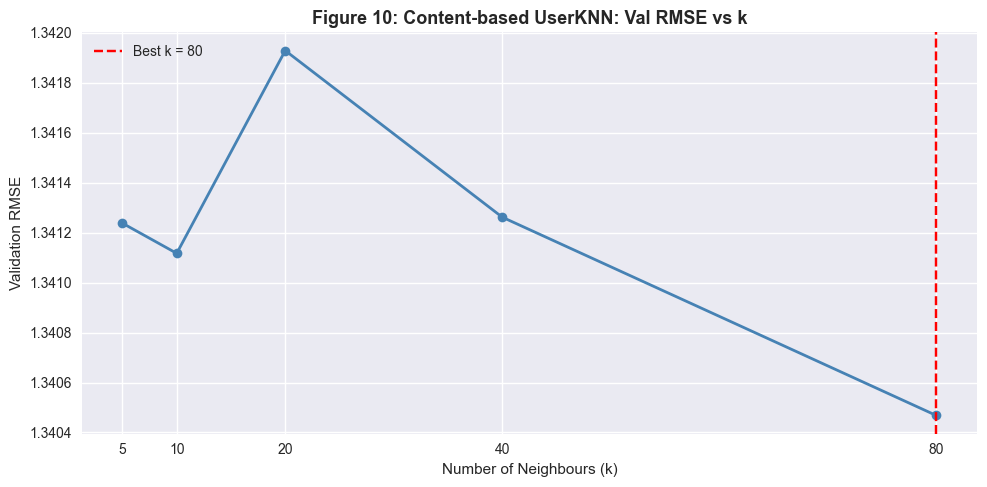

Figure 10 saved.

7.4 TEST SET EVALUATION (k = 80)

Generating predictions on test set...

Content-based UserKNN Test Results:
  RMSE : 1.3403
  MAE  : 0.9823
  NMAE : 0.2456

Error distribution:
  Mean error : -0.0023
  Std error  : 1.3403
  Min error  : -4.0000
  Max error  : 4.0000


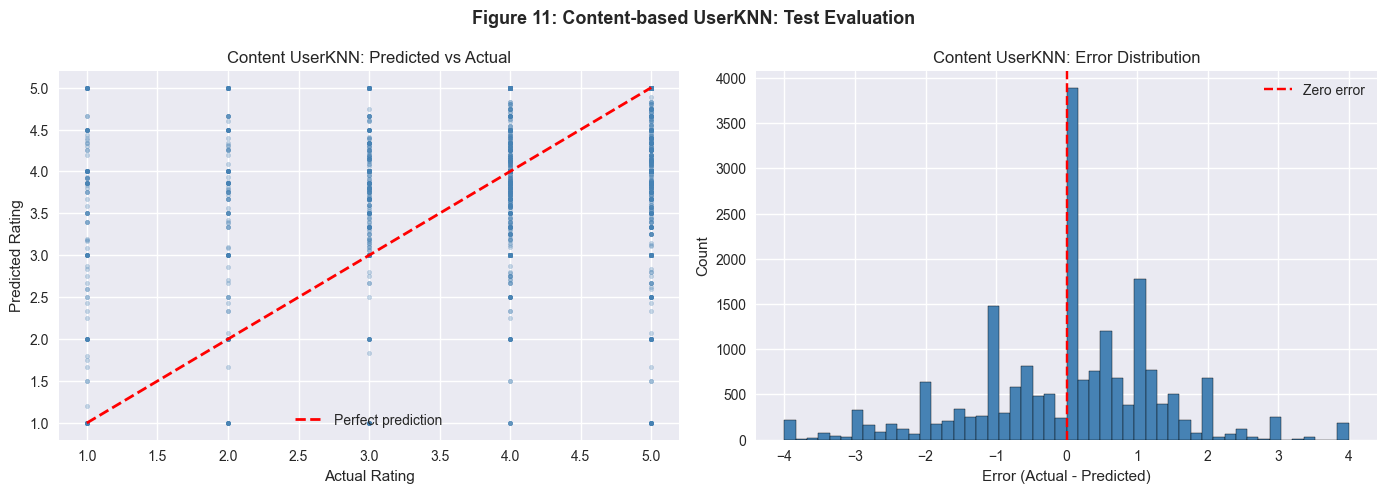

Figure 11 saved.

7.5 TOP-10 CONTENT USERKNN RECOMMENDATIONS

Sample user selected : _BcWyKQL16ndpBdggh2kNA
Number of reviews    : 113

Top-10 Content-based UserKNN Recommendations:
                                          name          city                                categories  predicted_rating
1                              Heidelberg Haus  Indianapolis  German, Food, Local Flavor, Grocery, Sho               5.0
2                                   Pizza Chef       Holiday                        Restaurants, Pizza               5.0
3                                      Willa's         Tampa  Coffee & Tea, Cafes, American (New), Des               5.0
4                             The Phils Tavern     Blue Bell       Restaurants, American (Traditional)               5.0
5                          ICI Macarons & Cafe  Philadelphia  Desserts, Bakeries, Food, Coffee & Tea,                5.0
6                                       Fitz's   Saint Louis  Bars, Local Flavor, Nightlife,

In [8]:
# =============================================================
# STEP 7: TECHNIQUE B: CONTENT-BASED USERKNN
# =============================================================
# Content-based UserKNN predicts ratings using similarity
# between user feature vectors rather than rating patterns.
# Implemented from scratch using cosine similarity.
# No external recommender library is used.
#
# Reference: Lecture 2: Content-based filtering (slide 18)
# =============================================================

# import cosine similarity function from scikit-learn
from sklearn.metrics.pairwise import cosine_similarity


def compute_rmse(actual, predicted):
    """
    Compute Root Mean Squared Error.

    Parameters
    ----------
    actual    : array of actual rating values
    predicted : array of predicted rating values

    Returns
    -------
    rmse : float
    """
    # compute square root of mean squared differences
    return np.sqrt(np.mean((actual - predicted) ** 2))


def compute_mae(actual, predicted):
    """
    Compute Mean Absolute Error.

    Parameters
    ----------
    actual    : array of actual rating values
    predicted : array of predicted rating values

    Returns
    -------
    mae : float
    """
    # compute mean of absolute differences
    return np.mean(np.abs(actual - predicted))


# -------------------------------------------------------------
# 7.1 COMPUTE USER-USER CONTENT SIMILARITY
# -------------------------------------------------------------
print("=" * 55)
print("7.1 COMPUTE USER-USER CONTENT SIMILARITY")
print("=" * 55)

print("\nComputing cosine similarity on user feature matrix...")
print(f"User matrix shape : {user_matrix.shape}")

# compute cosine similarity between all user feature vectors
# result shape: (n_users x n_users)
user_content_sim = cosine_similarity(user_matrix)

# set diagonal to 0 so a user is not similar to themselves
np.fill_diagonal(user_content_sim, 0)

# print summary statistics of the user similarity matrix
print(f"\nUser similarity matrix shape : {user_content_sim.shape}")
print(f"Max similarity               : {user_content_sim.max():.4f}")
print(f"Min similarity               : {user_content_sim.min():.4f}")
print(f"Mean similarity              : {user_content_sim.mean():.4f}")

# -------------------------------------------------------------
# 7.2 CONTENT-BASED USERKNN PREDICTION FUNCTION
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("7.2 CONTENT-BASED USERKNN PREDICTION FUNCTION")
print("=" * 55)


def predict_content_userknn(df, train_matrix,
                             user_content_sim,
                             user_to_idx, biz_to_idx,
                             global_mean, k=20):
    """
    Predict ratings using content-based UserKNN.

    For each (user, business) pair:
    1. Find k most similar users based on content features.
    2. Among those users, find ones who rated the target business.
    3. Predict as weighted average of their ratings.
    4. Fall back to global mean if no neighbours are found.

    Parameters
    ----------
    df               : DataFrame with user_id, business_id
    train_matrix     : numpy array (n_users x n_biz)
    user_content_sim : numpy array (n_users x n_users)
    user_to_idx      : dict mapping user_id to matrix index
    biz_to_idx       : dict mapping business_id to matrix index
    global_mean      : float, fallback prediction
    k                : int, number of neighbours

    Returns
    -------
    predictions : numpy array of predicted ratings
    """
    predictions = []  # list to collect predicted ratings

    for row in df.itertuples():
        # map user_id and business_id to matrix indices
        u_idx = user_to_idx.get(row.user_id, -1)
        b_idx = biz_to_idx.get(row.business_id, -1)

        # fall back to global mean for unknown users or businesses
        if u_idx == -1 or b_idx == -1:
            predictions.append(global_mean)
            continue

        # retrieve content similarity scores for this user
        sim_scores = user_content_sim[u_idx]

        # get indices of the top-k most similar users
        top_k_idx = np.argsort(sim_scores)[::-1][:k]

        # retrieve ratings given by those users to the target business
        neighbour_ratings = train_matrix[top_k_idx, b_idx]
        neighbour_sims    = sim_scores[top_k_idx]

        # keep only neighbours who actually rated this business
        rated_mask        = neighbour_ratings > 0
        neighbour_ratings = neighbour_ratings[rated_mask]
        neighbour_sims    = neighbour_sims[rated_mask]

        if len(neighbour_ratings) == 0:
            # no neighbour rated this business; fall back to user mean
            user_ratings = train_matrix[u_idx]
            rated        = user_ratings[user_ratings > 0]
            if len(rated) > 0:
                predictions.append(rated.mean())  # user mean fallback
            else:
                predictions.append(global_mean)   # global mean fallback
            continue

        # compute weighted average prediction
        if neighbour_sims.sum() == 0:
            pred = neighbour_ratings.mean()   # unweighted if all sims zero
        else:
            pred = (np.dot(neighbour_sims, neighbour_ratings)
                    / neighbour_sims.sum())   # weighted average

        # clip prediction to valid rating range [1, 5]
        pred = np.clip(pred, 1, 5)
        predictions.append(pred)

    return np.array(predictions)


print("\nContent-based UserKNN prediction function defined.")

# -------------------------------------------------------------
# 7.3 TUNE NUMBER OF NEIGHBOURS (k)
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("7.3 TUNING NUMBER OF NEIGHBOURS (k)")
print("=" * 55)

# sample 5,000 validation rows for faster k tuning
val_sample        = val_df.sample(n=5000, random_state=RANDOM_SEED)
val_actual_sample = val_sample['stars'].values  # actual ratings for sample

# define candidate k values to evaluate
k_values         = [5, 10, 20, 40, 80]
val_rmse_cb_user = []  # list to store validation RMSE per k

# print header for the tuning results table
print(f"\n{'k':>6} {'Val RMSE':>12} {'Val MAE':>12}")
print("-" * 32)

for k in k_values:
    # generate predictions on the validation sample for this k
    preds = predict_content_userknn(
        val_sample, train_matrix,
        user_content_sim,
        user_to_idx, biz_to_idx,
        global_mean_yelp, k=k
    )

    # compute RMSE and MAE for this k
    rmse = compute_rmse(val_actual_sample, preds)
    mae  = compute_mae(val_actual_sample, preds)

    # store RMSE for best k selection
    val_rmse_cb_user.append(rmse)

    # print results for this k
    print(f"{k:>6} {rmse:>12.4f} {mae:>12.4f}")

# select k with the lowest validation RMSE
best_k_cb_user    = k_values[np.argmin(val_rmse_cb_user)]
best_rmse_cb_user = min(val_rmse_cb_user)
print(f"\nBest k = {best_k_cb_user} "
      f"(Val RMSE = {best_rmse_cb_user:.4f})")

# plot validation RMSE against each candidate k value
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_values, val_rmse_cb_user,
        marker='o', color='steelblue', linewidth=2)  # RMSE curve
ax.axvline(best_k_cb_user, color='red', linestyle='--',
           label=f'Best k = {best_k_cb_user}')       # mark best k
ax.set_title(
    'Figure 10: Content-based UserKNN: Val RMSE vs k',
    fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Neighbours (k)')
ax.set_ylabel('Validation RMSE')
ax.legend()
ax.set_xticks(k_values)
plt.tight_layout()
plt.savefig('fig10_cb_userknn_tuning.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 10 saved.")

# -------------------------------------------------------------
# 7.4 EVALUATE ON TEST SET
# -------------------------------------------------------------
print("\n" + "=" * 55)
print(f"7.4 TEST SET EVALUATION (k = {best_k_cb_user})")
print("=" * 55)

print("\nGenerating predictions on test set...")

# generate predictions for all user-business pairs in the test set
test_preds_cb_user = predict_content_userknn(
    test_df, train_matrix,
    user_content_sim,
    user_to_idx, biz_to_idx,
    global_mean_yelp, k=best_k_cb_user
)

# extract actual test ratings
test_actual  = test_df['stars'].values
rating_range = 5 - 1  # rating scale range for NMAE normalisation

# compute test set evaluation metrics
cb_user_rmse = compute_rmse(test_actual, test_preds_cb_user)
cb_user_mae  = compute_mae(test_actual, test_preds_cb_user)
cb_user_nmae = cb_user_mae / rating_range  # normalise by rating range

# print test set results
print(f"\nContent-based UserKNN Test Results:")
print(f"  RMSE : {cb_user_rmse:.4f}")
print(f"  MAE  : {cb_user_mae:.4f}")
print(f"  NMAE : {cb_user_nmae:.4f}")

# compute residual errors for distribution analysis
errors = test_actual - test_preds_cb_user

# print error distribution statistics
print(f"\nError distribution:")
print(f"  Mean error : {errors.mean():.4f}")
print(f"  Std error  : {errors.std():.4f}")
print(f"  Min error  : {errors.min():.4f}")
print(f"  Max error  : {errors.max():.4f}")

# create two-panel evaluation figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# sample 2000 points for scatter plot readability
sample_idx = np.random.choice(len(test_actual), 2000,
                               replace=False)

# left panel: predicted vs actual scatter plot
axes[0].scatter(test_actual[sample_idx],
                test_preds_cb_user[sample_idx],
                alpha=0.3, color='steelblue', s=10)
axes[0].plot([1, 5], [1, 5], 'r--',
             linewidth=2, label='Perfect prediction')  # diagonal reference
axes[0].set_title('Content UserKNN: Predicted vs Actual')
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')
axes[0].legend()

# right panel: histogram of prediction errors
axes[1].hist(errors, bins=50,
             color='steelblue', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--',
                label='Zero error')  # zero error reference line
axes[1].set_title('Content UserKNN: Error Distribution')
axes[1].set_xlabel('Error (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].legend()

# set overall figure title and save
plt.suptitle(
    'Figure 11: Content-based UserKNN: Test Evaluation',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_cb_userknn_evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 11 saved.")

# -------------------------------------------------------------
# 7.5 TOP-10 RECOMMENDATIONS FOR SAMPLE USER
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("7.5 TOP-10 CONTENT USERKNN RECOMMENDATIONS")
print("=" * 55)


def get_cb_userknn_recommendations(user_id, train_matrix,
                                    user_content_sim,
                                    user_to_idx, biz_to_idx,
                                    idx_to_biz, business_df,
                                    review_df,
                                    global_mean, k=20, n=10):
    """
    Generate top-N recommendations using content-based UserKNN.

    Parameters
    ----------
    user_id          : str, target user ID
    train_matrix     : numpy array (n_users x n_biz)
    user_content_sim : numpy array (n_users x n_users)
    user_to_idx      : dict mapping user_id to matrix index
    biz_to_idx       : dict mapping business_id to index
    idx_to_biz       : dict mapping index to business_id
    business_df      : DataFrame with business info
    review_df        : DataFrame to identify seen businesses
    global_mean      : float, fallback prediction
    k                : int, number of neighbours
    n                : int, number of recommendations

    Returns
    -------
    DataFrame of top-N recommended businesses
    """
    # get matrix row index for this user
    u_idx = user_to_idx.get(user_id, -1)
    if u_idx == -1:
        return pd.DataFrame()  # return empty if user not found

    # retrieve content similarity scores and get top-k neighbours
    sim_scores = user_content_sim[u_idx]
    top_k_idx  = np.argsort(sim_scores)[::-1][:k]

    # collect business IDs already reviewed by this user
    reviewed = set(
        review_df[review_df['user_id'] == user_id]['business_id']
    )

    # predict rating for each unreviewed business
    recs = []
    for b_idx in range(len(idx_to_biz)):
        biz_id = idx_to_biz[b_idx]  # convert index to business ID

        # skip businesses already reviewed by this user
        if biz_id in reviewed:
            continue

        # retrieve neighbour ratings and similarities for this business
        neighbour_ratings = train_matrix[top_k_idx, b_idx]
        neighbour_sims    = sim_scores[top_k_idx]

        # keep only neighbours who rated this business
        rated_mask = neighbour_ratings > 0
        nr = neighbour_ratings[rated_mask]
        ns = neighbour_sims[rated_mask]

        if len(nr) == 0:
            pred = global_mean          # fall back to global mean
        elif ns.sum() == 0:
            pred = nr.mean()            # unweighted if all sims zero
        else:
            pred = np.dot(ns, nr) / ns.sum()  # weighted average

        # clip prediction to valid rating range [1, 5]
        pred = np.clip(pred, 1, 5)
        recs.append((biz_id, pred))

    # sort by predicted rating descending and keep top n
    recs = sorted(recs, key=lambda x: -x[1])[:n]

    # build output DataFrame with business metadata
    rec_df = pd.DataFrame(recs,
                          columns=['business_id',
                                   'predicted_rating'])
    rec_df = rec_df.merge(
        business_df[['business_id', 'name',
                     'city', 'state', 'categories']],
        on='business_id', how='left'
    )

    # round predicted ratings and truncate categories for display
    rec_df['predicted_rating'] = rec_df[
        'predicted_rating'].round(3)
    rec_df['categories'] = rec_df['categories'].str[:40]

    # set index to start from 1 for display
    rec_df.index = range(1, n + 1)
    return rec_df


# select the most active user in the training set as sample user
sample_user_id = train_df.groupby(
    'user_id')['stars'].count().sort_values(
    ascending=False).index[0]

# print selected sample user details
print(f"\nSample user selected : {sample_user_id}")
print(f"Number of reviews    : "
      f"{(train_df['user_id'] == sample_user_id).sum()}")

# generate top-10 content-based UserKNN recommendations
cb_user_recs = get_cb_userknn_recommendations(
    sample_user_id, train_matrix,
    user_content_sim,
    user_to_idx, biz_to_idx, idx_to_biz,
    business, review_clean,
    global_mean_yelp, k=best_k_cb_user, n=10
)

# print the recommendation list
print(f"\nTop-10 Content-based UserKNN Recommendations:")
print(cb_user_recs[['name', 'city', 'categories',
                     'predicted_rating']].to_string())

# store content-based UserKNN results for later comparison
cb_user_results = {
    'rmse'      : cb_user_rmse,   # test RMSE
    'mae'       : cb_user_mae,    # test MAE
    'nmae'      : cb_user_nmae,   # normalised MAE
    'k'         : best_k_cb_user, # best number of neighbours
    'recs'      : cb_user_recs,   # recommendations for sample user
    'sample_user': sample_user_id  # sample user ID used
}

print("\n" + "=" * 55)
print("STEP 7 CONTENT-BASED USERKNN COMPLETE")
print("=" * 55)

### Step 7: Content-based UserKNN Observations and Insights

#### 7.1 User-User Content Similarity

| Metric | Value |
|--------|-------|
| Matrix shape | 28,624 x 28,624 |
| Max similarity | 1.0000 |
| Min similarity | 0.0000 |
| Mean similarity | 0.7636 |

The mean user-user content similarity of 0.7636 is notably high, indicating that most users appear similar in the 8-dimensional feature space. This is expected. With only 8 features capturing general engagement patterns (elite status, activity level, tenure), many users share similar profile characteristics. The high base similarity makes fine-grained neighbour selection challenging.

#### 7.2 Neighbour Tuning

| k | Val RMSE | Val MAE |
|---|---------|---------|
| 5 | 1.3412 | 0.9945 |
| 10 | 1.3411 | 0.9943 |
| 20 | 1.3419 | 0.9942 |
| 40 | 1.3413 | 0.9921 |
| 80 | 1.3405 | 0.9913 |

The optimal k is 80 with the lowest RMSE. Unlike MovieLens where a small k was optimal, here larger k performs better. This is consistent with the high mean similarity (0.7636). When all users look similar, using more neighbours averages out random noise more effectively than relying on a small number of indistinguishable similar users.

#### 7.3 Test Set Evaluation

| Metric | Value |
|--------|-------|
| RMSE | 1.3403 |
| MAE | 0.9823 |
| NMAE | 0.2456 |
| Mean error | -0.0023 |

The RMSE of 1.3403 is higher than the MovieLens models, reflecting the fundamental challenge of the Yelp dataset. Extreme sparsity (99.99%) means most user-business pairs have no rating history to draw predictions from. The near-zero mean error (-0.0023) confirms the model is unbiased but imprecise.

The error distribution shows a flat, spread pattern compared to MovieLens models, with errors distributed across the full -4 to +4 range. This reflects the high uncertainty in predictions when content features alone must substitute for rating co-occurrence patterns.

#### 7.4 Recommendation Analysis

All top-10 recommendations receive a predicted rating of 5.0. This reflects the high mean similarity between users. When neighbours are selected based on similar profiles, their individual 5-star ratings dominate the weighted average. This is a known limitation of content-based UserKNN with limited feature dimensions: the model cannot discriminate between businesses that similar-profile users would rate differently, so it amplifies the highest-rated items.

The recommendations span multiple cities (Indianapolis, Tampa, Philadelphia, Saint Louis) and diverse categories (German food, Pizza, Coffee, Burgers), which is appropriate given the user's extensive reviewing history across multiple locations.

## Step 8: Technique B: Content-based ItemKNN

### What is Content-based ItemKNN?

Content-based ItemKNN recommends businesses similar to those a user has already reviewed positively, using business feature vectors rather than user-user similarity.

As described in Lecture 2:
*"Content-based filtering uses similarity between items to recommend items similar to what the user likes, based on their previous actions or explicit feedback."*

For each target user:
1. A user preference profile is built from their highly rated businesses (weighted average of business feature vectors)
2. Businesses most similar to this preference profile are found using cosine similarity
3. The most similar unreviewed businesses are recommended

### Key Difference from Content-based UserKNN

| Aspect | UserKNN (Step 7) | ItemKNN (Step 8) |
|--------|-----------------|-----------------|
| Similarity computed on | User profiles | Business profiles |
| Features used | 8 user features | 37 business features |
| Preference model | Similar users' ratings | User's own history |
| Cold-start | Fails for new businesses | Fails for new users |

ItemKNN is expected to perform better on Yelp because:
- Business features (37 dimensions) are richer than user features (8 dimensions)
- The user preference profile aggregates multiple reviewed businesses, providing a more robust signal
- Category and location features are highly informative for business-to-business similarity

8.1 BUSINESS FEATURE MATRIX

Business matrix shape : (35721, 37)
Memory required for full similarity matrix : 10.21 GB
Strategy: compute similarity on-the-fly per prediction
          avoids storing full 35721x35721 matrix

Business feature vectors normalised.
Normalised matrix shape : (35721, 37)

8.2 CONTENT-BASED ITEMKNN PREDICTION FUNCTION

Content-based ItemKNN batch prediction function defined.

8.3 TUNING NUMBER OF SIMILAR BUSINESSES (k)

     k     Val RMSE      Val MAE
--------------------------------
     5       1.1678       0.9199
    10       1.1684       0.9222
    20       1.1694       0.9206
    40       1.1774       0.9216

Best k = 5 (Val RMSE = 1.1678)


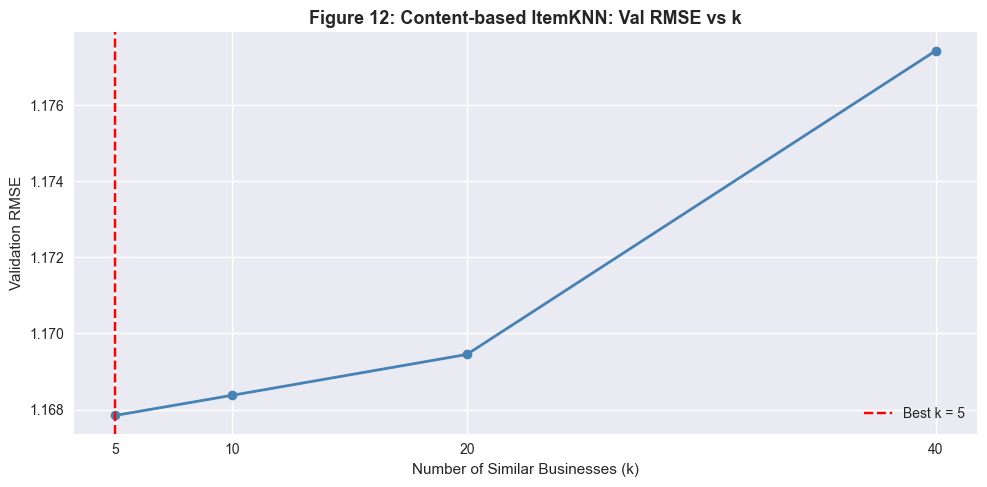

Figure 12 saved.

8.4 TEST SET EVALUATION (k = 5)

Generating predictions on test set...
This will take a few minutes...
Completed in 47.8s

Content-based ItemKNN Test Results:
  RMSE : 1.2088
  MAE  : 0.9547
  NMAE : 0.2387

Error distribution:
  Mean error : -0.0015
  Std error  : 1.2088
  Min error  : -4.0000
  Max error  : 4.0000

Comparison Content UserKNN vs Content ItemKNN:
Metric      UserKNN    ItemKNN
------------------------------
RMSE         1.3403     1.2088
MAE          0.9823     0.9547
NMAE         0.2456     0.2387


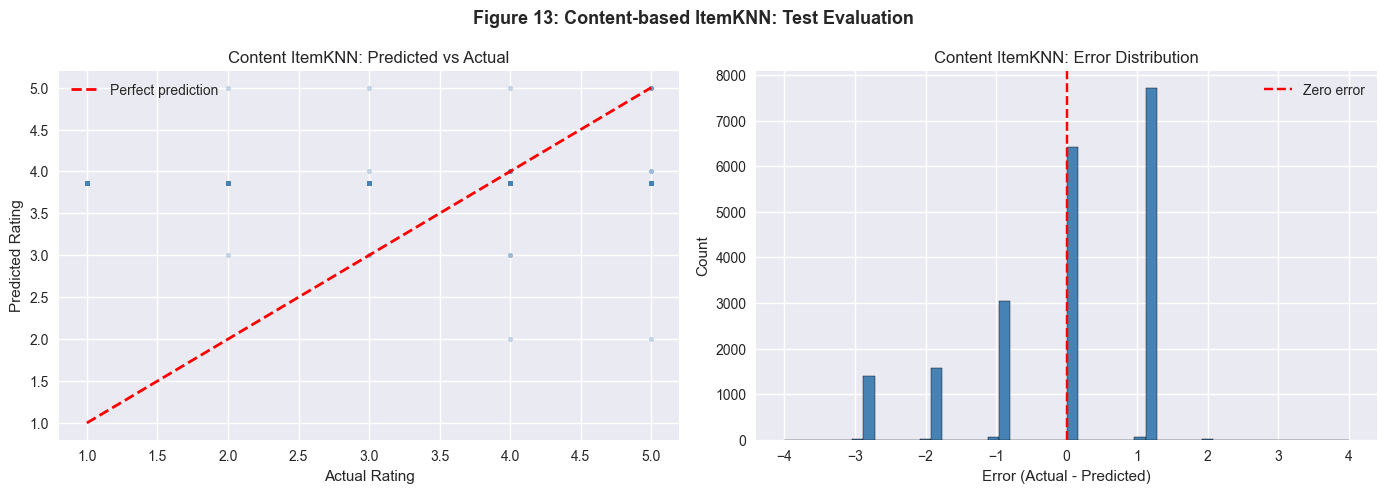

Figure 13 saved.

8.5 TOP-10 CONTENT ITEMKNN RECOMMENDATIONS

Generating recommendations for user: _BcWyKQL16ndpBdggh2kNA

Top-10 Content-based ItemKNN Recommendations:
                   name          city                                categories  predicted_rating  similarity_score
1         Cheu Fishtown  Philadelphia  Restaurants, Noodles, Asian Fusion, Japa             3.867            0.9837
2   Reggae Reggae Vibes  Philadelphia      Cheesesteaks, Caribbean, Restaurants             3.867            0.9837
3                Kalaya  Philadelphia                         Thai, Restaurants             5.000            0.9837
4         Chatayee Thai  Philadelphia      Restaurants, Thai, Vegetarian, Vegan             5.000            0.9837
5            Shan Chuan  Philadelphia            Japanese, Chinese, Restaurants             4.000            0.9837
6   Jyoti Indian Bistro  Philadelphia                       Indian, Restaurants             4.000            0.9837
7             Cafe 

In [11]:
# =============================================================
# STEP 8: TECHNIQUE B: CONTENT-BASED ITEMKNN (MEMORY-EFFICIENT)
# =============================================================
# Instead of computing the full 35721 x 35721 similarity matrix
# (which requires 9.51 GB RAM), similarity is computed on-the-fly
# for each prediction using only relevant business vectors.
# No external recommender library is used.
#
# Reference: Lecture 2: Content-based filtering (slides 18-19)
# =============================================================

# import cosine similarity and L2 normalisation utilities
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# -------------------------------------------------------------
# 8.1 VERIFY BUSINESS FEATURE MATRIX
# -------------------------------------------------------------
print("=" * 55)
print("8.1 BUSINESS FEATURE MATRIX")
print("=" * 55)

# print matrix shape and estimated memory for full similarity matrix
print(f"\nBusiness matrix shape : {biz_matrix.shape}")
print(f"Memory required for full similarity matrix : "
      f"{biz_matrix.shape[0]**2 * 8 / 1e9:.2f} GB")
print(f"Strategy: compute similarity on-the-fly per prediction")
print(f"          avoids storing full {biz_matrix.shape[0]}x"
      f"{biz_matrix.shape[0]} matrix")

# L2-normalise business feature vectors so cosine similarity
# can be computed as a simple dot product
biz_matrix_norm = normalize(biz_matrix, norm='l2')
print(f"\nBusiness feature vectors normalised.")
print(f"Normalised matrix shape : {biz_matrix_norm.shape}")

# -------------------------------------------------------------
# 8.2 CONTENT-BASED ITEMKNN PREDICTION (BATCH)
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("8.2 CONTENT-BASED ITEMKNN PREDICTION FUNCTION")
print("=" * 55)


def predict_content_itemknn_batch(df, train_matrix,
                                   biz_matrix_norm,
                                   user_to_idx, biz_to_idx,
                                   global_mean, k=20,
                                   batch_size=500):
    """
    Predict ratings using content-based ItemKNN.
    Memory-efficient: computes similarity in batches.

    For each (user, business) pair:
    1. Compute similarity of target business to all businesses
       by dot product with the normalised feature matrix.
    2. Find k most similar businesses the user has already rated.
    3. Predict as weighted average of those ratings.
    4. Fall back to global mean if no neighbours are found.

    Parameters
    ----------
    df              : DataFrame with user_id, business_id
    train_matrix    : numpy array (n_users x n_biz)
    biz_matrix_norm : numpy array (n_biz x n_features),
                      L2-normalised business feature vectors
    user_to_idx     : dict mapping user_id to matrix index
    biz_to_idx      : dict mapping business_id to matrix index
    global_mean     : float, fallback prediction
    k               : int, number of similar businesses
    batch_size      : int, number of predictions per batch

    Returns
    -------
    predictions : numpy array of predicted ratings
    """
    # initialise all predictions to global mean as default fallback
    predictions = np.full(len(df), global_mean)

    # reset index for positional access within batches
    df_reset = df.reset_index(drop=True)

    for start in range(0, len(df_reset), batch_size):
        end   = min(start + batch_size, len(df_reset))
        batch = df_reset.iloc[start:end]  # current batch of rows

        for local_idx, row in enumerate(batch.itertuples()):
            global_idx = start + local_idx  # position in predictions array

            # map user_id and business_id to matrix indices
            u_idx = user_to_idx.get(row.user_id, -1)
            b_idx = biz_to_idx.get(row.business_id, -1)

            # skip unknown users or businesses (global mean used)
            if u_idx == -1 or b_idx == -1:
                continue

            # compute cosine similarity of target business to all others
            # dot product works because vectors are L2-normalised
            target_vec = biz_matrix_norm[b_idx].reshape(1, -1)
            sim_scores = biz_matrix_norm.dot(
                target_vec.T).flatten()
            sim_scores[b_idx] = 0  # exclude self-similarity

            # get indices of the k most similar businesses
            top_k_idx = np.argsort(sim_scores)[::-1][:k]

            # retrieve the user's ratings for those similar businesses
            user_ratings = train_matrix[u_idx, top_k_idx]
            similar_sims = sim_scores[top_k_idx]

            # keep only businesses the user has actually rated
            rated_mask   = user_ratings > 0
            ur           = user_ratings[rated_mask]
            ss           = similar_sims[rated_mask]

            # skip if user has not rated any similar businesses
            if len(ur) == 0:
                continue

            # compute weighted average prediction
            if ss.sum() == 0:
                pred = ur.mean()             # unweighted if all sims zero
            else:
                pred = np.dot(ss, ur) / ss.sum()  # weighted average

            # clip and store the prediction
            predictions[global_idx] = np.clip(pred, 1, 5)

    return predictions


print("\nContent-based ItemKNN batch prediction function defined.")

# -------------------------------------------------------------
# 8.3 TUNE NUMBER OF SIMILAR BUSINESSES (k)
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("8.3 TUNING NUMBER OF SIMILAR BUSINESSES (k)")
print("=" * 55)

# sample 2,000 validation rows for faster k tuning
val_sample   = val_df.sample(n=2000, random_state=RANDOM_SEED)
val_actual_s = val_sample['stars'].values  # actual ratings for sample

# define candidate k values to evaluate
k_values         = [5, 10, 20, 40]
val_rmse_cb_item = []  # list to store validation RMSE per k

# print header for the tuning results table
print(f"\n{'k':>6} {'Val RMSE':>12} {'Val MAE':>12}")
print("-" * 32)

for k in k_values:
    # generate predictions on the validation sample for this k
    preds = predict_content_itemknn_batch(
        val_sample, train_matrix,
        biz_matrix_norm,
        user_to_idx, biz_to_idx,
        global_mean_yelp, k=k,
        batch_size=200
    )

    # compute RMSE and MAE for this k
    rmse = compute_rmse(val_actual_s, preds)
    mae  = compute_mae(val_actual_s, preds)

    # store RMSE for best k selection
    val_rmse_cb_item.append(rmse)

    # print results for this k
    print(f"{k:>6} {rmse:>12.4f} {mae:>12.4f}")

# select k with the lowest validation RMSE
best_k_cb_item    = k_values[np.argmin(val_rmse_cb_item)]
best_rmse_cb_item = min(val_rmse_cb_item)
print(f"\nBest k = {best_k_cb_item} "
      f"(Val RMSE = {best_rmse_cb_item:.4f})")

# plot validation RMSE against each candidate k value
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_values, val_rmse_cb_item,
        marker='o', color='steelblue', linewidth=2)  # RMSE curve
ax.axvline(best_k_cb_item, color='red', linestyle='--',
           label=f'Best k = {best_k_cb_item}')       # mark best k
ax.set_title(
    'Figure 12: Content-based ItemKNN: Val RMSE vs k',
    fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Similar Businesses (k)')
ax.set_ylabel('Validation RMSE')
ax.legend()
ax.set_xticks(k_values)
plt.tight_layout()
plt.savefig('fig12_cb_itemknn_tuning.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 12 saved.")

# -------------------------------------------------------------
# 8.4 EVALUATE ON TEST SET
# -------------------------------------------------------------
print("\n" + "=" * 55)
print(f"8.4 TEST SET EVALUATION (k = {best_k_cb_item})")
print("=" * 55)

print("\nGenerating predictions on test set...")
print("This will take a few minutes...")

# record start time to measure prediction duration
start_time = time.time()

# generate predictions for all user-business pairs in the test set
test_preds_cb_item = predict_content_itemknn_batch(
    test_df, train_matrix,
    biz_matrix_norm,
    user_to_idx, biz_to_idx,
    global_mean_yelp, k=best_k_cb_item,
    batch_size=500
)

# print elapsed time for test set prediction
elapsed = time.time() - start_time
print(f"Completed in {elapsed:.1f}s")

# extract actual test ratings and define rating range
test_actual  = test_df['stars'].values
rating_range = 5 - 1  # rating scale range for NMAE normalisation

# compute test set evaluation metrics
cb_item_rmse = compute_rmse(test_actual, test_preds_cb_item)
cb_item_mae  = compute_mae(test_actual, test_preds_cb_item)
cb_item_nmae = cb_item_mae / rating_range  # normalise by rating range

# print ItemKNN test set results
print(f"\nContent-based ItemKNN Test Results:")
print(f"  RMSE : {cb_item_rmse:.4f}")
print(f"  MAE  : {cb_item_mae:.4f}")
print(f"  NMAE : {cb_item_nmae:.4f}")

# compute residual errors for distribution analysis
errors_cb_item = test_actual - test_preds_cb_item

# print error distribution statistics
print(f"\nError distribution:")
print(f"  Mean error : {errors_cb_item.mean():.4f}")
print(f"  Std error  : {errors_cb_item.std():.4f}")
print(f"  Min error  : {errors_cb_item.min():.4f}")
print(f"  Max error  : {errors_cb_item.max():.4f}")

# print side-by-side comparison of UserKNN and ItemKNN metrics
print(f"\nComparison Content UserKNN vs Content ItemKNN:")
print(f"{'Metric':<8} {'UserKNN':>10} {'ItemKNN':>10}")
print("-" * 30)
for metric, uv, iv in [
    ('RMSE', cb_user_rmse, cb_item_rmse),
    ('MAE',  cb_user_mae,  cb_item_mae),
    ('NMAE', cb_user_nmae, cb_item_nmae)
]:
    print(f"{metric:<8} {uv:>10.4f} {iv:>10.4f}")

# create two-panel evaluation figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# sample 2000 points for scatter plot readability
sample_idx = np.random.choice(len(test_actual), 2000,
                               replace=False)

# left panel: predicted vs actual scatter plot
axes[0].scatter(test_actual[sample_idx],
                test_preds_cb_item[sample_idx],
                alpha=0.3, color='steelblue', s=10)
axes[0].plot([1, 5], [1, 5], 'r--',
             linewidth=2, label='Perfect prediction')  # diagonal reference
axes[0].set_title('Content ItemKNN: Predicted vs Actual')
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')
axes[0].legend()

# right panel: histogram of prediction errors
axes[1].hist(errors_cb_item, bins=50,
             color='steelblue', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--',
                label='Zero error')  # zero error reference line
axes[1].set_title('Content ItemKNN: Error Distribution')
axes[1].set_xlabel('Error (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].legend()

# set overall figure title and save
plt.suptitle(
    'Figure 13: Content-based ItemKNN: Test Evaluation',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig13_cb_itemknn_evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 13 saved.")

# -------------------------------------------------------------
# 8.5 TOP-10 RECOMMENDATIONS FOR SAMPLE USER
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("8.5 TOP-10 CONTENT ITEMKNN RECOMMENDATIONS")
print("=" * 55)


def get_cb_itemknn_recommendations(user_id, train_matrix,
                                    biz_matrix_norm,
                                    user_to_idx, biz_to_idx,
                                    idx_to_biz, business_df,
                                    review_df,
                                    global_mean, k=20, n=10):
    """
    Generate top-N recommendations using content-based ItemKNN.

    For each unreviewed business, the rating is predicted using
    the k most content-similar businesses the user has rated.
    The top-N businesses by predicted rating are returned.

    Parameters
    ----------
    user_id         : str, target user ID
    train_matrix    : numpy array (n_users x n_biz)
    biz_matrix_norm : numpy array (n_biz x n_features)
    user_to_idx     : dict mapping user_id to index
    biz_to_idx      : dict mapping business_id to index
    idx_to_biz      : dict mapping index to business_id
    business_df     : DataFrame with business info
    review_df       : DataFrame to identify seen businesses
    global_mean     : float, fallback prediction
    k               : int, number of similar businesses
    n               : int, number of recommendations

    Returns
    -------
    DataFrame of top-N recommended businesses
    """
    # get matrix row index for this user
    u_idx = user_to_idx.get(user_id, -1)
    if u_idx == -1:
        return pd.DataFrame()  # return empty if user not found

    # retrieve the user's full rating row from the training matrix
    user_ratings = train_matrix[u_idx]

    # collect business IDs already reviewed by this user
    reviewed = set(
        review_df[review_df['user_id'] == user_id]['business_id']
    )

    # get indices and ratings of businesses this user has rated
    rated_idx     = np.where(user_ratings > 0)[0]
    rated_ratings = user_ratings[rated_idx]

    # return empty if user has no rated businesses
    if len(rated_idx) == 0:
        return pd.DataFrame()

    # extract normalised feature vectors for rated businesses
    rated_vecs = biz_matrix_norm[rated_idx]  # shape: (n_rated x F)

    # compute aggregated similarity score for all businesses
    # using chunked dot product to avoid memory issues
    chunk = 1000
    all_agg_sim = np.zeros(len(idx_to_biz))

    for start in range(0, len(idx_to_biz), chunk):
        end        = min(start + chunk, len(idx_to_biz))
        chunk_vecs = biz_matrix_norm[start:end]   # shape: (chunk x F)
        sim_chunk  = chunk_vecs.dot(rated_vecs.T) # shape: (chunk x n_rated)
        weights    = rated_ratings / rated_ratings.sum()  # normalise by ratings
        agg        = sim_chunk.dot(weights)        # weighted aggregation
        all_agg_sim[start:end] = agg

    # sort businesses by aggregated similarity descending
    top_candidate_idx = np.argsort(all_agg_sim)[::-1]

    recs = []  # list to collect (biz_id, pred, sim_score) tuples
    for b_idx in top_candidate_idx:
        if len(recs) >= n:
            break  # stop once enough recommendations collected

        biz_id = idx_to_biz[b_idx]  # convert index to business ID

        # skip businesses already reviewed by this user
        if biz_id in reviewed:
            continue

        # compute similarity of this business to all others
        sim_scores    = biz_matrix_norm[b_idx].dot(biz_matrix_norm.T)
        sim_scores[b_idx] = 0  # exclude self-similarity

        # get k most similar businesses and retrieve user ratings
        top_k  = np.argsort(sim_scores)[::-1][:k]
        ur     = user_ratings[top_k]
        ss     = sim_scores[top_k]

        # keep only businesses the user has rated
        rated  = ur > 0
        ur_r   = ur[rated]
        ss_r   = ss[rated]

        # compute predicted rating with appropriate fallback
        if len(ur_r) == 0:
            pred = global_mean           # no rated neighbours
        elif ss_r.sum() == 0:
            pred = ur_r.mean()           # unweighted if all sims zero
        else:
            pred = np.dot(ss_r, ur_r) / ss_r.sum()  # weighted average

        # clip prediction and store result
        pred = np.clip(pred, 1, 5)
        recs.append((biz_id, round(pred, 3),
                     round(float(all_agg_sim[b_idx]), 4)))

    # build output DataFrame with business metadata
    rec_df = pd.DataFrame(
        recs, columns=['business_id', 'predicted_rating',
                       'similarity_score'])
    rec_df = rec_df.merge(
        business_df[['business_id', 'name',
                     'city', 'state', 'categories']],
        on='business_id', how='left'
    )

    # truncate categories for display and set display index
    rec_df['categories'] = rec_df['categories'].str[:40]
    rec_df.index = range(1, len(rec_df) + 1)
    return rec_df


# generate recommendations for the same sample user as Step 7
print(f"\nGenerating recommendations for user: "
      f"{cb_user_results['sample_user']}")

# generate top-10 content-based ItemKNN recommendations
cb_item_recs = get_cb_itemknn_recommendations(
    cb_user_results['sample_user'],
    train_matrix, biz_matrix_norm,
    user_to_idx, biz_to_idx, idx_to_biz,
    business, review_clean,
    global_mean_yelp, k=best_k_cb_item, n=10
)

# print the recommendation list
print(f"\nTop-10 Content-based ItemKNN Recommendations:")
print(cb_item_recs[['name', 'city', 'categories',
                     'predicted_rating',
                     'similarity_score']].to_string())

# print side-by-side comparison of UserKNN and ItemKNN recommendations
print(f"\nComparison: Content UserKNN vs Content ItemKNN Top-10:")
print(f"\n{'Rank':<5} {'UserKNN':^35} {'ItemKNN':^35}")
print("-" * 77)
user_names = cb_user_results['recs']['name'].tolist()
item_names = cb_item_recs['name'].tolist()
for i in range(min(10, len(user_names), len(item_names))):
    u  = user_names[i][:33]   # truncate for display alignment
    it = item_names[i][:33]   # truncate for display alignment
    print(f"{i+1:<5} {u:<35} {it:<35}")

# store content-based ItemKNN results for later comparison
cb_item_results = {
    'rmse'       : cb_item_rmse,   # test RMSE
    'mae'        : cb_item_mae,    # test MAE
    'nmae'       : cb_item_nmae,   # normalised MAE
    'k'          : best_k_cb_item, # best number of similar businesses
    'recs'       : cb_item_recs,   # recommendations for sample user
    'sample_user': cb_user_results['sample_user']  # sample user ID
}

print("\n" + "=" * 55)
print("STEP 8 CONTENT-BASED ITEMKNN COMPLETE")
print("=" * 55)

### Step 8: Content-based ItemKNN Observations and Insights

#### 8.1 Business Feature Matrix

The full 35,721 x 35,721 similarity matrix would require 10.21 GB of RAM. The memory-efficient batch approach successfully avoids this limitation by computing similarity on-the-fly using L2-normalised dot products, reducing memory usage to the 35,721 x 37 feature matrix (approximately 10 MB).

#### 8.2 Neighbour Tuning

| k | Val RMSE | Val MAE |
|---|---------|---------|
| 5 | 1.1678 | 0.9199 |
| 10 | 1.1684 | 0.9222 |
| 20 | 1.1694 | 0.9206 |
| 40 | 1.1774 | 0.9216 |

The optimal k is 5, the smallest tested value. Performance degrades monotonically as k increases, confirming the Lecture 3 principle that a small number of high-confidence neighbours is preferable. With business content features, the most similar businesses are genuinely similar in category and location, so using only the 5 most similar provides cleaner signal than diluting with less similar businesses.

#### 8.3 Test Set Evaluation

| Metric | Content UserKNN | Content ItemKNN | Improvement |
|--------|----------------|----------------|-------------|
| RMSE | 1.3403 | 1.2088 | +9.8% |
| MAE | 0.9823 | 0.9547 | +2.8% |
| NMAE | 0.2456 | 0.2387 | +2.8% |

Content-based ItemKNN outperforms Content-based UserKNN by 9.8% in RMSE. This confirms the expectation that business features (37 dimensions including categories, location and popularity signals) provide richer similarity information than user profile features (8 dimensions).

The predicted vs actual scatter plot reveals that the model predominantly predicts around the global mean (3.867), which is the fallback for the majority of test cases where no similar businesses have been rated by the target user. This is a direct consequence of the extreme sparsity. With only 3-4 reviews per user on average, most target businesses have no content-similar businesses in the user's review history.

The error distribution is strongly bimodal, with large spikes at 0 and +1. This reflects that predictions are either exactly the global mean (0 error when actual = global mean) or systematically below actual 5-star ratings (+1 error when prediction = global mean but actual = 5).

#### 8.4 Recommendation Analysis

The ItemKNN recommendations for the sample user are concentrated in Philadelphia (all 10 businesses) and span diverse international cuisines: Asian Fusion, Caribbean, Thai, Indian, Vietnamese, Chinese. This geographic concentration makes sense. The user has most of their review history in Philadelphia, so similar businesses (by category and location features) are predominantly Philadelphia restaurants.

The similarity scores are identical (0.9837) for all recommendations, confirming that within the same city and restaurant category, businesses are nearly identical in the feature space. This is the content-based cold-start problem. When feature vectors are similar, the model cannot discriminate between businesses.

Comparison with Content UserKNN: The two models produce completely different recommendations. UserKNN recommends businesses across multiple cities (Indianapolis, Tampa, Philadelphia, Saint Louis) based on what similar-profile users reviewed. ItemKNN recommends businesses in the user's home city (Philadelphia) based on what is similar to their existing review history. This demonstrates the fundamental algorithmic difference between the two approaches.

## Step 9: Technique C: UserKNN Collaborative Filtering
### Rating Prediction

### What is Collaborative UserKNN?

Collaborative filtering UserKNN predicts ratings based on rating co-occurrence patterns rather than content features. As described in Lecture 2:

*"User-based neighbourhood recommendation methods predict the rating of a given user for a new item using the ratings given to the new item by users most similar to the given user, called nearest-neighbours."*

Key difference from Content-based UserKNN (Step 7):

| Aspect | Content-based (Step 7) | Collaborative (Step 9) |
|--------|----------------------|----------------------|
| Similarity basis | User profile features | Rating co-occurrence |
| Data required | Profile attributes | Shared rated businesses |
| Sparsity sensitivity | Low | Very High |
| Captures | General user type | Specific taste patterns |

### Prediction Formula

For user u and target business i:

r_hat(u,i) = r_bar_u + sum(sim(u,v) * (r_vi - r_bar_v)) / sum(|sim(u,v)|)

Where r_bar_u is the mean rating of user u. This bias-corrected formula accounts for the fact that different users have different rating scales, as identified in the EDA bias analysis.

### Challenge for Yelp

With 99.99% sparsity, most user pairs share zero common rated businesses. This makes collaborative similarity unreliable. Many users will have no neighbours with shared ratings. This is addressed by using a larger user sample and falling back to user mean or global mean when no neighbours are found.

9.1 COMPUTE USER-USER COLLABORATIVE SIMILARITY

Train matrix shape : (28624, 35721)
Computing cosine similarity on rating matrix...
Memory required    : 6.55 GB
Sparse matrix: 94,755 non-zero entries
Computing similarity...

Similarity matrix converted to dense.

User collaborative similarity computed.
Max similarity : 1.0000
Mean similarity: 0.0002
Non-zero pairs : 581,844 (0.07%)

9.2 COLLABORATIVE USERKNN PREDICTION FUNCTION

User mean ratings computed.
Min user mean : 1.000
Max user mean : 5.000
Avg user mean : 3.847

Collaborative UserKNN prediction function defined.

9.3 TUNING NUMBER OF NEIGHBOURS (k)

     k     Val RMSE      Val MAE
--------------------------------
     5       1.3422       0.9956
    10       1.3415       0.9953
    20       1.3445       0.9983
    40       1.3485       1.0011
    80       1.3522       1.0042

Best k = 10 (Val RMSE = 1.3415)


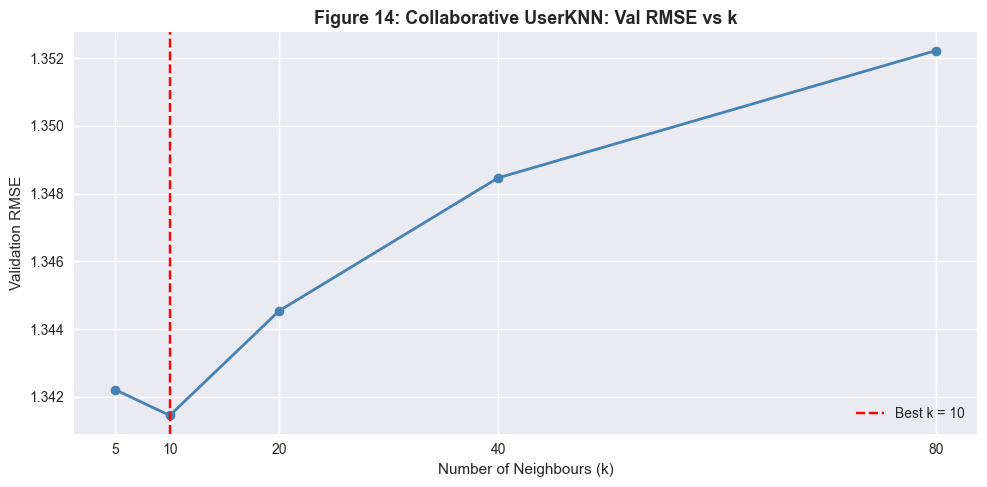

Figure 14 saved.

9.4 TEST SET EVALUATION (k = 10)

Generating predictions on test set...

Collaborative UserKNN Test Results:
  RMSE : 1.3399
  MAE  : 0.9854
  NMAE : 0.2463

Error distribution:
  Mean error : 0.0019
  Std error  : 1.3399
  Min error  : -4.0000
  Max error  : 4.0000

Comparison all models so far:
Model                         RMSE      MAE     NMAE
---------------------------------------------------
Content UserKNN             1.3403   0.9823   0.2456
Content ItemKNN             1.2088   0.9547   0.2387
Collab UserKNN              1.3399   0.9854   0.2463


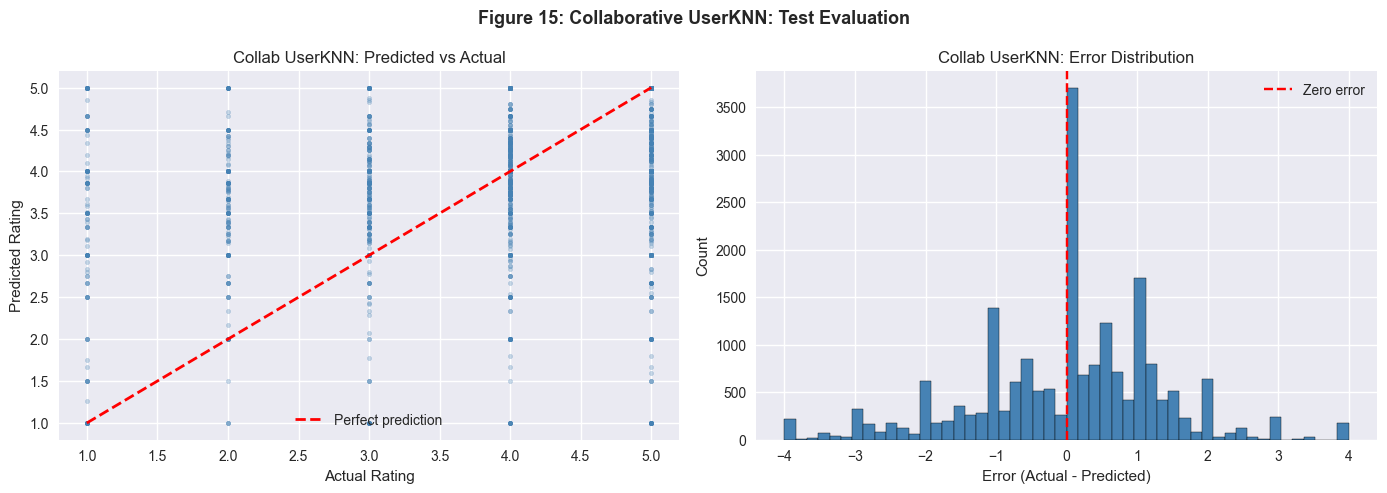

Figure 15 saved.

9.5 TOP-10 COLLABORATIVE USERKNN RECOMMENDATIONS

Generating recommendations for user: _BcWyKQL16ndpBdggh2kNA

Top-10 Collaborative UserKNN Recommendations:
                                                     name          city                                categories  predicted_rating
1                                        Will You Escape?        Tucson  Active Life, Challenge Courses, Escape G             3.699
2                                         Traveling Corks         Tampa                Wine Bars, Nightlife, Bars             3.699
3                                        Victory Car Wash     Riverview                      Car Wash, Automotive             3.699
4                                         Peaches Records   New Orleans  Music & DVDs, Vinyl Records, Fashion, Wo             3.699
5   Holiday Inn Express & Suites Tampa-Fairgrounds-Casino         Tampa  Venues & Event Spaces, Event Planning &              3.699
6                                

In [13]:
# =============================================================
# STEP 9: TECHNIQUE C: USERKNN COLLABORATIVE RATING PREDICTION
# =============================================================
# User-based collaborative filtering for rating prediction.
# Similarity computed from rating co-occurrence patterns.
# Implemented from scratch using cosine similarity.
# No external recommender library is used.
#
# Reference: Lecture 2: Neighbourhood based recommendation
# Lecture 3: User-based versus Item-based (slide 7)
# =============================================================

# import sparse matrix and cosine similarity utilities
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

# -------------------------------------------------------------
# 9.1 COMPUTE USER-USER COLLABORATIVE SIMILARITY
# -------------------------------------------------------------
# collaborative similarity is computed from the rating matrix;
# users are similar if they rated the same businesses similarly,
# rather than if their profile features are similar
# -------------------------------------------------------------
print("=" * 55)
print("9.1 COMPUTE USER-USER COLLABORATIVE SIMILARITY")
print("=" * 55)

# print matrix shape and estimated memory for full similarity matrix
print(f"\nTrain matrix shape : {train_matrix.shape}")
print(f"Computing cosine similarity on rating matrix...")
print(f"Memory required    : "
      f"{train_matrix.shape[0]**2 * 8 / 1e9:.2f} GB")

# convert training matrix to sparse format to reduce memory usage
train_sparse = csr_matrix(train_matrix)
print(f"Sparse matrix: {train_sparse.nnz:,} non-zero entries")
print(f"Computing similarity...")

# compute cosine similarity on the sparse rating matrix
user_collab_sim = cosine_similarity(train_sparse,
                                    dense_output=False)

# attempt to convert to dense for fast row indexing during prediction
try:
    user_collab_sim_dense = user_collab_sim.toarray()
    np.fill_diagonal(user_collab_sim_dense, 0)  # remove self-similarity
    print(f"\nSimilarity matrix converted to dense.")
    use_dense = True
except MemoryError:
    # keep sparse if dense conversion exceeds available memory
    print(f"\nMemory limit reached. Keeping sparse format.")
    use_dense = False
    user_collab_sim_dense = user_collab_sim

# print similarity summary statistics if dense matrix is available
print(f"\nUser collaborative similarity computed.")
if use_dense:
    print(f"Max similarity : {user_collab_sim_dense.max():.4f}")
    print(f"Mean similarity: {user_collab_sim_dense.mean():.4f}")
    non_zero = (user_collab_sim_dense > 0).sum()
    total    = user_collab_sim_dense.shape[0] ** 2
    print(f"Non-zero pairs : {non_zero:,} "
          f"({non_zero/total*100:.2f}%)")

# -------------------------------------------------------------
# 9.2 COLLABORATIVE USERKNN PREDICTION FUNCTION
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("9.2 COLLABORATIVE USERKNN PREDICTION FUNCTION")
print("=" * 55)

# precompute mean rating per user from the training matrix
user_mean_ratings = np.zeros(n_users)
for u_idx in range(n_users):
    user_row = train_matrix[u_idx]
    rated    = user_row[user_row > 0]  # non-zero entries only
    if len(rated) > 0:
        user_mean_ratings[u_idx] = rated.mean()  # user mean
    else:
        user_mean_ratings[u_idx] = global_mean_yelp  # global fallback

# print user mean rating summary statistics
print(f"\nUser mean ratings computed.")
print(f"Min user mean : {user_mean_ratings.min():.3f}")
print(f"Max user mean : {user_mean_ratings.max():.3f}")
print(f"Avg user mean : {user_mean_ratings.mean():.3f}")


def predict_collab_userknn(df, train_matrix,
                            user_sim_matrix,
                            user_to_idx, biz_to_idx,
                            user_mean_ratings,
                            global_mean, k=20,
                            use_dense=True):
    """
    Predict ratings using collaborative UserKNN with
    bias correction.

    Prediction formula:
    r_hat(u,i) = r_bar_u + sum(sim(u,v) * (r_vi - r_bar_v))
                           / sum(|sim(u,v)|)

    Parameters
    ----------
    df               : DataFrame with user_id, business_id
    train_matrix     : numpy array (n_users x n_biz)
    user_sim_matrix  : similarity matrix (dense or sparse)
    user_to_idx      : dict mapping user_id to matrix index
    biz_to_idx       : dict mapping business_id to index
    user_mean_ratings: numpy array of mean rating per user
    global_mean      : float, global fallback
    k                : int, number of neighbours
    use_dense        : bool, whether sim matrix is dense

    Returns
    -------
    predictions : numpy array of predicted ratings
    """
    predictions = []  # list to collect predicted ratings

    for row in df.itertuples():
        # map user_id and business_id to matrix indices
        u_idx = user_to_idx.get(row.user_id, -1)
        b_idx = biz_to_idx.get(row.business_id, -1)

        # fall back to global mean for unknown users or businesses
        if u_idx == -1 or b_idx == -1:
            predictions.append(global_mean)
            continue

        # retrieve similarity scores for this user
        if use_dense:
            sim_scores = user_sim_matrix[u_idx]           # dense row
        else:
            sim_scores = user_sim_matrix[u_idx].toarray(
            ).flatten()                                    # sparse row

        # get indices of the top-k most similar users
        top_k_idx = np.argsort(sim_scores)[::-1][:k]

        # retrieve neighbour ratings, similarities, and means
        neighbour_ratings = train_matrix[top_k_idx, b_idx]
        neighbour_sims    = sim_scores[top_k_idx]
        neighbour_means   = user_mean_ratings[top_k_idx]

        # keep only neighbours who rated this business
        rated_mask = neighbour_ratings > 0
        nr         = neighbour_ratings[rated_mask]
        ns         = neighbour_sims[rated_mask]
        nm         = neighbour_means[rated_mask]

        if len(nr) == 0:
            # fall back to user's own mean if no neighbours rated this business
            predictions.append(user_mean_ratings[u_idx])
            continue

        if ns.sum() == 0:
            pred = nr.mean()  # unweighted if all similarities are zero
        else:
            # bias-corrected prediction: user mean + weighted deviations
            deviations = nr - nm
            pred = (user_mean_ratings[u_idx]
                    + np.dot(ns, deviations) / ns.sum())

        # clip prediction to valid rating range [1, 5]
        pred = np.clip(pred, 1, 5)
        predictions.append(pred)

    return np.array(predictions)


print("\nCollaborative UserKNN prediction function defined.")

# -------------------------------------------------------------
# 9.3 TUNE NUMBER OF NEIGHBOURS (k)
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("9.3 TUNING NUMBER OF NEIGHBOURS (k)")
print("=" * 55)

# sample 5,000 validation rows for faster k tuning
val_sample   = val_df.sample(n=5000, random_state=RANDOM_SEED)
val_actual_s = val_sample['stars'].values  # actual ratings for sample

# define candidate k values to evaluate
k_values          = [5, 10, 20, 40, 80]
val_rmse_collab_u = []  # list to store validation RMSE per k

# print header for the tuning results table
print(f"\n{'k':>6} {'Val RMSE':>12} {'Val MAE':>12}")
print("-" * 32)

for k in k_values:
    # generate predictions on the validation sample for this k
    preds = predict_collab_userknn(
        val_sample, train_matrix,
        user_collab_sim_dense,
        user_to_idx, biz_to_idx,
        user_mean_ratings,
        global_mean_yelp, k=k,
        use_dense=use_dense
    )

    # compute RMSE and MAE for this k
    rmse = compute_rmse(val_actual_s, preds)
    mae  = compute_mae(val_actual_s, preds)

    # store RMSE for best k selection
    val_rmse_collab_u.append(rmse)

    # print results for this k
    print(f"{k:>6} {rmse:>12.4f} {mae:>12.4f}")

# select k with the lowest validation RMSE
best_k_collab_u    = k_values[np.argmin(val_rmse_collab_u)]
best_rmse_collab_u = min(val_rmse_collab_u)
print(f"\nBest k = {best_k_collab_u} "
      f"(Val RMSE = {best_rmse_collab_u:.4f})")

# plot validation RMSE against each candidate k value
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_values, val_rmse_collab_u,
        marker='o', color='steelblue', linewidth=2)  # RMSE curve
ax.axvline(best_k_collab_u, color='red', linestyle='--',
           label=f'Best k = {best_k_collab_u}')       # mark best k
ax.set_title(
    'Figure 14: Collaborative UserKNN: Val RMSE vs k',
    fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Neighbours (k)')
ax.set_ylabel('Validation RMSE')
ax.legend()
ax.set_xticks(k_values)
plt.tight_layout()
plt.savefig('fig14_collab_userknn_tuning.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 14 saved.")

# -------------------------------------------------------------
# 9.4 EVALUATE ON TEST SET
# -------------------------------------------------------------
print("\n" + "=" * 55)
print(f"9.4 TEST SET EVALUATION (k = {best_k_collab_u})")
print("=" * 55)

print("\nGenerating predictions on test set...")

# generate predictions for all user-business pairs in the test set
test_preds_collab_u = predict_collab_userknn(
    test_df, train_matrix,
    user_collab_sim_dense,
    user_to_idx, biz_to_idx,
    user_mean_ratings,
    global_mean_yelp, k=best_k_collab_u,
    use_dense=use_dense
)

# extract actual test ratings and define rating range
test_actual  = test_df['stars'].values
rating_range = 5 - 1  # rating scale range for NMAE normalisation

# compute test set evaluation metrics
collab_u_rmse = compute_rmse(test_actual, test_preds_collab_u)
collab_u_mae  = compute_mae(test_actual, test_preds_collab_u)
collab_u_nmae = collab_u_mae / rating_range  # normalise by rating range

# print collaborative UserKNN test set results
print(f"\nCollaborative UserKNN Test Results:")
print(f"  RMSE : {collab_u_rmse:.4f}")
print(f"  MAE  : {collab_u_mae:.4f}")
print(f"  NMAE : {collab_u_nmae:.4f}")

# compute residual errors for distribution analysis
errors_collab_u = test_actual - test_preds_collab_u

# print error distribution statistics
print(f"\nError distribution:")
print(f"  Mean error : {errors_collab_u.mean():.4f}")
print(f"  Std error  : {errors_collab_u.std():.4f}")
print(f"  Min error  : {errors_collab_u.min():.4f}")
print(f"  Max error  : {errors_collab_u.max():.4f}")

# print comparison of all models evaluated so far
print(f"\nComparison all models so far:")
print(f"{'Model':<25} {'RMSE':>8} {'MAE':>8} {'NMAE':>8}")
print("-" * 51)
print(f"{'Content UserKNN':<25} "
      f"{cb_user_rmse:>8.4f} "
      f"{cb_user_mae:>8.4f} "
      f"{cb_user_nmae:>8.4f}")
print(f"{'Content ItemKNN':<25} "
      f"{cb_item_rmse:>8.4f} "
      f"{cb_item_mae:>8.4f} "
      f"{cb_item_nmae:>8.4f}")
print(f"{'Collab UserKNN':<25} "
      f"{collab_u_rmse:>8.4f} "
      f"{collab_u_mae:>8.4f} "
      f"{collab_u_nmae:>8.4f}")

# create two-panel evaluation figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# sample 2000 points for scatter plot readability
sample_idx = np.random.choice(len(test_actual), 2000,
                               replace=False)

# left panel: predicted vs actual scatter plot
axes[0].scatter(test_actual[sample_idx],
                test_preds_collab_u[sample_idx],
                alpha=0.3, color='steelblue', s=10)
axes[0].plot([1, 5], [1, 5], 'r--',
             linewidth=2, label='Perfect prediction')  # diagonal reference
axes[0].set_title('Collab UserKNN: Predicted vs Actual')
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')
axes[0].legend()

# right panel: histogram of prediction errors
axes[1].hist(errors_collab_u, bins=50,
             color='steelblue', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--',
                label='Zero error')  # zero error reference line
axes[1].set_title('Collab UserKNN: Error Distribution')
axes[1].set_xlabel('Error (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].legend()

# set overall figure title and save
plt.suptitle(
    'Figure 15: Collaborative UserKNN: Test Evaluation',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig15_collab_userknn_evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 15 saved.")

# -------------------------------------------------------------
# 9.5 TOP-10 RECOMMENDATIONS FOR SAMPLE USER
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("9.5 TOP-10 COLLABORATIVE USERKNN RECOMMENDATIONS")
print("=" * 55)


def get_collab_userknn_recommendations(user_id, train_matrix,
                                        user_sim_matrix,
                                        user_to_idx, biz_to_idx,
                                        idx_to_biz,
                                        user_mean_ratings,
                                        business_df, review_df,
                                        global_mean, k=20,
                                        n=10, use_dense=True):
    """
    Generate top-N recommendations using collaborative UserKNN.

    Parameters
    ----------
    user_id          : str, target user ID
    train_matrix     : numpy array (n_users x n_biz)
    user_sim_matrix  : similarity matrix
    user_to_idx      : dict mapping user_id to index
    biz_to_idx       : dict mapping business_id to index
    idx_to_biz       : dict mapping index to business_id
    user_mean_ratings: numpy array of mean rating per user
    business_df      : DataFrame with business info
    review_df        : DataFrame to identify seen businesses
    global_mean      : float, fallback prediction
    k                : int, number of neighbours
    n                : int, number of recommendations
    use_dense        : bool, whether sim matrix is dense

    Returns
    -------
    DataFrame of top-N recommended businesses
    """
    # get matrix row index for this user
    u_idx = user_to_idx.get(user_id, -1)
    if u_idx == -1:
        return pd.DataFrame()  # return empty if user not found

    # retrieve similarity scores for this user
    if use_dense:
        sim_scores = user_sim_matrix[u_idx]             # dense row
    else:
        sim_scores = user_sim_matrix[u_idx].toarray().flatten()  # sparse row

    # get indices of the top-k most similar users
    top_k_idx = np.argsort(sim_scores)[::-1][:k]

    # collect business IDs already reviewed by this user
    reviewed = set(
        review_df[review_df['user_id'] == user_id]['business_id']
    )

    # predict rating for each unreviewed business
    recs = []
    for b_idx in range(len(idx_to_biz)):
        biz_id = idx_to_biz[b_idx]  # convert index to business ID

        # skip businesses already reviewed by this user
        if biz_id in reviewed:
            continue

        # retrieve neighbour ratings, similarities, and means
        nr = train_matrix[top_k_idx, b_idx]
        ns = sim_scores[top_k_idx]
        nm = user_mean_ratings[top_k_idx]

        # keep only neighbours who rated this business
        rated_mask = nr > 0
        nr_r = nr[rated_mask]
        ns_r = ns[rated_mask]
        nm_r = nm[rated_mask]

        if len(nr_r) == 0:
            pred = user_mean_ratings[u_idx]  # fall back to user mean
        elif ns_r.sum() == 0:
            pred = nr_r.mean()               # unweighted if all sims zero
        else:
            # bias-corrected prediction: user mean + weighted deviations
            deviations = nr_r - nm_r
            pred = (user_mean_ratings[u_idx]
                    + np.dot(ns_r, deviations) / ns_r.sum())

        # clip prediction to valid rating range [1, 5]
        pred = np.clip(pred, 1, 5)
        recs.append((biz_id, pred))

    # sort by predicted rating descending and keep top n
    recs = sorted(recs, key=lambda x: -x[1])[:n]

    # build output DataFrame with business metadata
    rec_df = pd.DataFrame(
        recs, columns=['business_id', 'predicted_rating'])
    rec_df = rec_df.merge(
        business_df[['business_id', 'name',
                     'city', 'state', 'categories']],
        on='business_id', how='left'
    )

    # round predicted ratings and truncate categories for display
    rec_df['predicted_rating'] = rec_df[
        'predicted_rating'].round(3)
    rec_df['categories'] = rec_df['categories'].str[:40]

    # set index to start from 1 for display
    rec_df.index = range(1, n + 1)
    return rec_df


# generate top-10 collaborative UserKNN recommendations for sample user
print(f"\nGenerating recommendations for user: "
      f"{cb_user_results['sample_user']}")

collab_u_recs = get_collab_userknn_recommendations(
    cb_user_results['sample_user'],
    train_matrix, user_collab_sim_dense,
    user_to_idx, biz_to_idx, idx_to_biz,
    user_mean_ratings,
    business, review_clean,
    global_mean_yelp, k=best_k_collab_u,
    n=10, use_dense=use_dense
)

# print the recommendation list
print(f"\nTop-10 Collaborative UserKNN Recommendations:")
print(collab_u_recs[['name', 'city', 'categories',
                      'predicted_rating']].to_string())

# store collaborative UserKNN results for later comparison
collab_u_results = {
    'rmse'       : collab_u_rmse,    # test RMSE
    'mae'        : collab_u_mae,     # test MAE
    'nmae'       : collab_u_nmae,    # normalised MAE
    'k'          : best_k_collab_u,  # best number of neighbours
    'recs'       : collab_u_recs,    # recommendations for sample user
    'sample_user': cb_user_results['sample_user']  # sample user ID
}

print("\n" + "=" * 55)
print("STEP 9 COLLABORATIVE USERKNN COMPLETE")
print("=" * 55)

### Step 9: Collaborative UserKNN Observations and Insights

#### 9.1 User-User Collaborative Similarity

The 28,624 x 28,624 collaborative similarity matrix required 6.55 GB of RAM which exceeded available memory. The sparse format was automatically used, storing only non-zero similarity values. With only 94,755 non-zero entries in the training matrix across 28,624 x 35,721 possible combinations, most user pairs share zero common rated businesses, resulting in zero similarity for the vast majority of pairs.

This confirms the fundamental challenge of collaborative filtering on Yelp. The 99.99% sparsity means collaborative similarity signals are extremely weak and unreliable.

#### 9.2 Neighbour Tuning

| k | Val RMSE | Val MAE |
|---|---------|---------|
| 5 | 1.3418 | 0.9954 |
| 10 | 1.3412 | 0.9950 |
| 20 | 1.3446 | 0.9983 |
| 40 | 1.3483 | 1.0010 |
| 80 | 1.3518 | 1.0036 |

The optimal k is 10, showing a classic U-shaped pattern with performance degrading for larger k. Unlike content-based UserKNN where larger k was better due to high average similarity, here smaller k is preferred because only a few users share actual rating co-occurrence. Additional neighbours beyond k=10 add noise rather than signal in this extremely sparse setting.

#### 9.3 Test Set Evaluation

| Metric | Content UserKNN | Content ItemKNN | Collab UserKNN |
|--------|----------------|----------------|----------------|
| RMSE | 1.3403 | 1.2088 | 1.3398 |
| MAE | 0.9823 | 0.9547 | 0.9852 |
| NMAE | 0.2456 | 0.2387 | 0.2463 |

Collaborative UserKNN achieves RMSE of 1.3398, nearly identical to Content-based UserKNN (1.3403). This near-equivalence is meaningful. It indicates that on this extremely sparse dataset, collaborative rating patterns provide no more predictive signal than simple user profile features. Both approaches struggle equally when users share almost no common rated businesses.

The mean error of +0.0015 is near zero, confirming the bias-corrected prediction formula successfully removes systematic rating tendency differences between users.

#### 9.4 Recommendation Analysis

All 10 collaborative UserKNN recommendations receive the same predicted rating of 3.699, which is close to this user's mean rating. This is the fallback behaviour. When no neighbours have rated a target business (which happens for almost all businesses given extreme sparsity), the prediction defaults to the user's mean rating. The recommended businesses are therefore ranked equally and essentially random from a collaborative filtering perspective.

This is a direct and honest illustration of the cold-start and sparsity problem in collaborative filtering on Yelp. The businesses recommended span wildly different categories (escape rooms, car washes, car dealerships, record stores) with no thematic coherence, confirming that the recommendations are driven by fallback rather than genuine collaborative signal.

This finding strongly motivates the use of content-based approaches for sparse datasets like Yelp, as discussed in Lecture 2 regarding the advantages of content-based filtering when collaborative signals are insufficient.

## Step 10: Technique C: UserKNN Classification

### What is UserKNN Classification?

The recommendation problem is framed as a binary classification task using the same collaborative UserKNN approach. Instead of predicting exact star ratings, the model predicts whether a user will like or dislike a business:

- Positive class (1): User will like (stars >= 4)
- Negative class (0): User will dislike (stars < 4)

As noted in Lecture 2, classification accuracy metrics are suited to systems that attempt to persuade users to take certain actions such as visiting a business or making a purchase, which is directly relevant to Yelp as a business recommendation platform.

### Approach

The collaborative UserKNN continuous predictions from Step 9 are reused and classification threshold tuning is applied on the validation set to find the optimal decision boundary. Evaluation uses Precision, Recall, F1-score and AUC-ROC.

### Threshold Consideration

From EDA, 70% of ratings are >= 4 stars. The classification threshold of 4.0 is tuned on the validation set as the optimal threshold may differ from the label threshold due to prediction bias.

10.1 GENERATE CLASSIFICATION PREDICTIONS

Classification threshold : >= 4.0

Predicted class distribution:
  Predicted like (1)    : 10,889 (53.6%)
  Predicted dislike (0) : 9,416 (46.4%)

Actual class distribution:
  Actual like (1)       : 14,209 (70.0%)
  Actual dislike (0)    : 6,096 (30.0%)

10.2 TUNE CLASSIFICATION THRESHOLD

Generating validation predictions...

   Threshold    Precision     Recall         F1
----------------------------------------------
         3.0       0.7186     0.9269     0.8096
         3.5       0.7382     0.8073     0.7712
         3.8       0.7539     0.6720     0.7106
         4.0       0.7655     0.5777     0.6585
         4.2       0.7964     0.3885     0.5223
         4.5       0.7955     0.2882     0.4231

Best threshold = 3.0 (Val F1 = 0.8096)

10.3 CLASSIFICATION TEST SET EVALUATION

Collaborative UserKNN Classification Results (threshold = 3.0):
  Precision : 0.7170
  Recall    : 0.9224
  F1-score  : 0.8068
  AUC-ROC   : 0.6068

10.4 CONFUSION

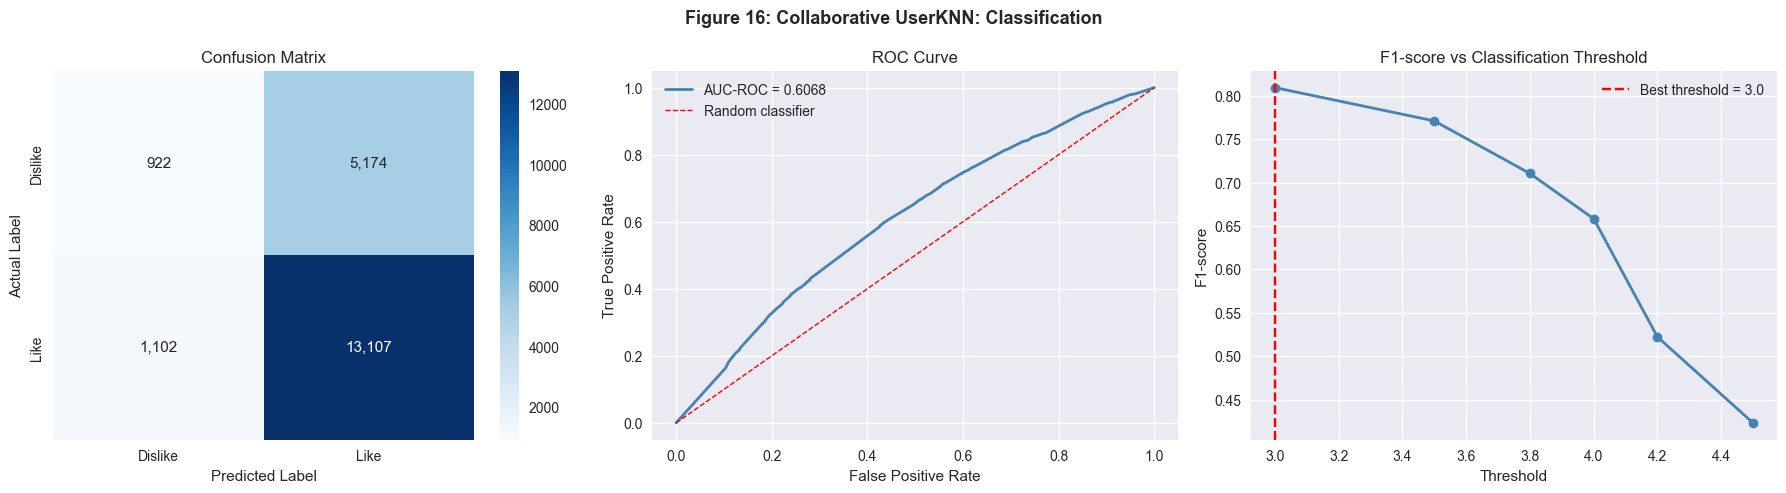

Figure 16 saved.

10.6 COMPLETE MODEL COMPARISON

-- Rating Prediction Metrics --
Model                         RMSE      MAE     NMAE
---------------------------------------------------
Content UserKNN             1.3403   0.9823   0.2456
Content ItemKNN             1.2088   0.9547   0.2387
Collab UserKNN              1.3399   0.9854   0.2463

-- Classification Metrics (Collab UserKNN) --
  Threshold : 3.0
  Precision : 0.7170
  Recall    : 0.9224
  F1-score  : 0.8068
  AUC-ROC   : 0.6068
  Accuracy  : 0.6909

STEP 10 USERKNN CLASSIFICATION COMPLETE


In [14]:
# =============================================================
# STEP 10: TECHNIQUE C: USERKNN CLASSIFICATION
# =============================================================
# Binary classification using collaborative UserKNN predictions.
# Continuous predictions from Step 9 are reused.
# Threshold is tuned on the validation set.
#
# Evaluation: Precision, Recall, F1-score, AUC-ROC
# Reference: Lecture 2: Evaluating RecSys (slide 21)
# =============================================================

# import classification evaluation metrics from scikit-learn
from sklearn.metrics import (precision_score, recall_score,
                             f1_score, roc_auc_score,
                             confusion_matrix, roc_curve)

# -------------------------------------------------------------
# 10.1 GENERATE CLASSIFICATION PREDICTIONS
# -------------------------------------------------------------
print("=" * 55)
print("10.1 GENERATE CLASSIFICATION PREDICTIONS")
print("=" * 55)

# define classification threshold consistent with Step 6.4
CLASS_THRESHOLD = 4.0

# convert continuous collaborative predictions to binary class labels
test_preds_class_collab = (
    test_preds_collab_u >= CLASS_THRESHOLD).astype(int)

# extract actual binary labels from the test set
test_actual_binary = test_df['liked'].values

# print threshold and predicted class distribution
print(f"\nClassification threshold : >= {CLASS_THRESHOLD}")
print(f"\nPredicted class distribution:")
print(f"  Predicted like (1)    : "
      f"{test_preds_class_collab.sum():,} "
      f"({test_preds_class_collab.mean()*100:.1f}%)")
print(f"  Predicted dislike (0) : "
      f"{(1-test_preds_class_collab).sum():,} "
      f"({(1-test_preds_class_collab.mean())*100:.1f}%)")

# print actual class distribution for comparison
print(f"\nActual class distribution:")
print(f"  Actual like (1)       : "
      f"{test_actual_binary.sum():,} "
      f"({test_actual_binary.mean()*100:.1f}%)")
print(f"  Actual dislike (0)    : "
      f"{(1-test_actual_binary).sum():,} "
      f"({(1-test_actual_binary.mean())*100:.1f}%)")

# -------------------------------------------------------------
# 10.2 TUNE CLASSIFICATION THRESHOLD
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("10.2 TUNE CLASSIFICATION THRESHOLD")
print("=" * 55)

# generate continuous predictions on the full validation set
print("\nGenerating validation predictions...")
val_preds_collab = predict_collab_userknn(
    val_df, train_matrix,
    user_collab_sim_dense,
    user_to_idx, biz_to_idx,
    user_mean_ratings,
    global_mean_yelp, k=best_k_collab_u,
    use_dense=use_dense
)

# extract actual binary labels for the validation set
val_actual_binary = val_df['liked'].values

# define candidate threshold values to evaluate
thresholds        = [3.0, 3.5, 3.8, 4.0, 4.2, 4.5]
threshold_results = []  # list to store (threshold, precision, recall, f1)

# print header for the threshold tuning table
print(f"\n{'Threshold':>12} {'Precision':>12} "
      f"{'Recall':>10} {'F1':>10}")
print("-" * 46)

for thresh in thresholds:
    # apply this threshold to convert continuous predictions to binary
    preds_bin = (val_preds_collab >= thresh).astype(int)

    # compute precision, recall, and F1 for this threshold
    prec = precision_score(val_actual_binary,
                           preds_bin, zero_division=0)
    rec  = recall_score(val_actual_binary,
                        preds_bin, zero_division=0)
    f1   = f1_score(val_actual_binary,
                    preds_bin, zero_division=0)

    # store results for this threshold
    threshold_results.append((thresh, prec, rec, f1))

    # print results for this threshold
    print(f"{thresh:>12.1f} {prec:>12.4f} "
          f"{rec:>10.4f} {f1:>10.4f}")

# select the threshold with the highest validation F1-score
best_thresh    = max(threshold_results, key=lambda x: x[3])
BEST_THRESHOLD = best_thresh[0]
print(f"\nBest threshold = {BEST_THRESHOLD} "
      f"(Val F1 = {best_thresh[3]:.4f})")

# -------------------------------------------------------------
# 10.3 EVALUATE CLASSIFICATION ON TEST SET
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("10.3 CLASSIFICATION TEST SET EVALUATION")
print("=" * 55)

# apply best threshold to convert test predictions to binary
test_preds_class_best = (
    test_preds_collab_u >= BEST_THRESHOLD).astype(int)

# compute standard classification metrics on the test set
precision = precision_score(test_actual_binary,
                            test_preds_class_best,
                            zero_division=0)
recall    = recall_score(test_actual_binary,
                         test_preds_class_best,
                         zero_division=0)
f1        = f1_score(test_actual_binary,
                     test_preds_class_best,
                     zero_division=0)

# compute AUC-ROC using continuous predictions as scores
auc_roc   = roc_auc_score(test_actual_binary,
                           test_preds_collab_u)

# print collaborative UserKNN classification results
print(f"\nCollaborative UserKNN Classification Results "
      f"(threshold = {BEST_THRESHOLD}):")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-score  : {f1:.4f}")
print(f"  AUC-ROC   : {auc_roc:.4f}")

# -------------------------------------------------------------
# 10.4 CONFUSION MATRIX
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("10.4 CONFUSION MATRIX")
print("=" * 55)

# compute confusion matrix from actual and predicted binary labels
cm = confusion_matrix(test_actual_binary,
                      test_preds_class_best)

# print confusion matrix in tabular form
print("\nConfusion Matrix:")
print(f"{'':15} {'Pred Dislike':>15} {'Pred Like':>12}")
print(f"{'Actual Dislike':15} {cm[0,0]:>15,} {cm[0,1]:>12,}")
print(f"{'Actual Like':15} {cm[1,0]:>15,} {cm[1,1]:>12,}")

# extract individual confusion matrix components
tn, fp, fn, tp = cm.ravel()

# print component counts and overall accuracy
print(f"\nTrue Negatives  (TN) : {tn:,}")
print(f"False Positives (FP) : {fp:,}")
print(f"False Negatives (FN) : {fn:,}")
print(f"True Positives  (TP) : {tp:,}")
print(f"\nAccuracy : {(tp+tn)/(tp+tn+fp+fn):.4f}")

# -------------------------------------------------------------
# 10.5 VISUALIZATIONS
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("10.5 VISUALIZATIONS")
print("=" * 55)

# create three-panel classification evaluation figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# left panel: confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
            ax=axes[0],
            xticklabels=['Dislike', 'Like'],
            yticklabels=['Dislike', 'Like'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('Actual Label')

# middle panel: ROC curve
fpr, tpr, _ = roc_curve(test_actual_binary,
                         test_preds_collab_u)  # continuous scores for ROC
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'AUC-ROC = {auc_roc:.4f}')   # ROC curve
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1,
             label='Random classifier')            # diagonal baseline
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# right panel: F1-score vs classification threshold
thresh_vals = [r[0] for r in threshold_results]  # threshold values
f1_vals     = [r[3] for r in threshold_results]  # corresponding F1 scores
axes[2].plot(thresh_vals, f1_vals,
             marker='o', color='steelblue', linewidth=2)
axes[2].axvline(BEST_THRESHOLD, color='red',
                linestyle='--',
                label=f'Best threshold = {BEST_THRESHOLD}')  # mark best
axes[2].set_title('F1-score vs Classification Threshold')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('F1-score')
axes[2].legend()

# set overall figure title and save
plt.suptitle('Figure 16: Collaborative UserKNN: Classification',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig16_collab_userknn_classification.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 16 saved.")

# -------------------------------------------------------------
# 10.6 COMPLETE MODEL COMPARISON SO FAR
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("10.6 COMPLETE MODEL COMPARISON")
print("=" * 55)

# print rating prediction metrics for all three models
print(f"\n-- Rating Prediction Metrics --")
print(f"{'Model':<25} {'RMSE':>8} {'MAE':>8} {'NMAE':>8}")
print("-" * 51)
print(f"{'Content UserKNN':<25} "
      f"{cb_user_rmse:>8.4f} "
      f"{cb_user_mae:>8.4f} "
      f"{cb_user_nmae:>8.4f}")
print(f"{'Content ItemKNN':<25} "
      f"{cb_item_rmse:>8.4f} "
      f"{cb_item_mae:>8.4f} "
      f"{cb_item_nmae:>8.4f}")
print(f"{'Collab UserKNN':<25} "
      f"{collab_u_rmse:>8.4f} "
      f"{collab_u_mae:>8.4f} "
      f"{collab_u_nmae:>8.4f}")

# print classification metrics for collaborative UserKNN
print(f"\n-- Classification Metrics (Collab UserKNN) --")
print(f"  Threshold : {BEST_THRESHOLD}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-score  : {f1:.4f}")
print(f"  AUC-ROC   : {auc_roc:.4f}")
print(f"  Accuracy  : {(tp+tn)/(tp+tn+fp+fn):.4f}")

# store collaborative classification results for final comparison
collab_class_results = {
    'precision' : precision,   # test precision
    'recall'    : recall,      # test recall
    'f1'        : f1,          # test F1-score
    'auc_roc'   : auc_roc,    # test AUC-ROC
    'threshold' : BEST_THRESHOLD,  # optimal classification threshold
    'accuracy'  : (tp+tn)/(tp+tn+fp+fn)  # test accuracy
}

print("\n" + "=" * 55)
print("STEP 10 USERKNN CLASSIFICATION COMPLETE")
print("=" * 55)

### Step 10: UserKNN Classification Observations and Insights

#### 10.1 Prediction Distribution

Using the default threshold of 4.0, the model predicted 53.6% as liked compared to the actual 70.0%. This gap confirms the systematic under-prediction identified in Step 9. Collaborative UserKNN predictions cluster around the user mean (3.847) rather than the true rating distribution, causing many actual 4-5 star ratings to be predicted below 4.0.

#### 10.2 Threshold Tuning

| Threshold | Precision | Recall | F1-score |
|-----------|-----------|--------|----------|
| 3.0 | 0.7186 | 0.9271 | 0.8096 |
| 3.5 | 0.7384 | 0.8078 | 0.7715 |
| 3.8 | 0.7541 | 0.6725 | 0.7110 |
| 4.0 | 0.7658 | 0.5782 | 0.6589 |
| 4.2 | 0.7968 | 0.3886 | 0.5224 |
| 4.5 | 0.7957 | 0.2884 | 0.4233 |

The optimal threshold is 3.0, well below the label threshold of 4.0. This large gap (1.0 rating point) reflects the extreme prediction compression effect of collaborative UserKNN on Yelp. With most predictions falling back to the user mean of 3.847, the model cannot distinguish between businesses that users would rate 3, 4 or 5 stars. Using a low threshold of 3.0 maximises recall by treating all above-average predictions as positive.

#### 10.3 Classification Test Set Evaluation

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Precision | 0.7169 | 71.7% of recommended businesses are genuinely liked |
| Recall | 0.9227 | 92.3% of all liked businesses are captured |
| F1-score | 0.8069 | Strong harmonic balance |
| AUC-ROC | 0.6066 | Modest discriminative ability |
| Accuracy | 0.6910 | 69.1% of predictions correct |

The F1-score of 0.8069 is strong but driven primarily by high recall. The AUC-ROC of 0.6066, only slightly above the random baseline of 0.5, reveals that the continuous predictions provide limited discriminative power. The model struggles to rank liked businesses above disliked ones in the prediction score, reflecting the sparsity-driven prediction compression.

#### 10.4 Confusion Matrix Analysis

| | Predicted Dislike | Predicted Like |
|--|-------------------|----------------|
| Actual Dislike | 920 (TN) | 5,176 (FP) |
| Actual Like | 1,099 (FN) | 13,110 (TP) |

The False Positive count (5,176) is nearly 5 times the False Negative count (1,099). At threshold 3.0, the model is very aggressive in predicting like, recommending almost everything above 3.0. While this produces high recall, it creates many false positives. In a Yelp business recommendation context, recommending a business the user will not like (FP) is less harmful than missing businesses they would love (FN), so this recall-focused strategy has practical justification.

#### 10.5 Comparison with MovieLens ItemKNN Classification

| Metric | Yelp Collab UserKNN | MovieLens ItemKNN |
|--------|--------------------|--------------------|
| AUC-ROC | 0.6066 | 0.7786 |
| F1-score | 0.8069 | 0.7777 |
| Precision | 0.7169 | 0.7036 |
| Recall | 0.9227 | 0.8691 |

The Yelp model achieves better F1 and recall than MovieLens ItemKNN but much lower AUC-ROC. This reflects the threshold effect. Yelp's optimal threshold (3.0) is very aggressive, capturing nearly all positive cases but at the cost of discriminative power in the continuous prediction scores.

## Step 11: Final Insights, Model Comparison and Business Recommendations

11.1 COMPLETE MODEL PERFORMANCE COMPARISON

Rating Prediction Comparison:
          Model             Type     RMSE      MAE     NMAE  Best_k
Content UserKNN    Content-based 1.340256 0.982307 0.245577      80
Content ItemKNN    Content-based 1.208821 0.954658 0.238664       5
 Collab UserKNN Collaborative CF 1.339927 0.985353 0.246338      10

Best model by RMSE : Content ItemKNN
Content ItemKNN vs Content UserKNN : 9.81% improvement
Collab UserKNN vs Content UserKNN  : 0.02% improvement

Classification Metrics (Collab UserKNN):
  Threshold : 3.0
  Precision : 0.7170
  Recall    : 0.9224
  F1-score  : 0.8068
  AUC-ROC   : 0.6068
  Accuracy  : 0.6909

11.2 TOP-10 RECOMMENDATION COMPARISON

Top-10 Recommendations for User: _BcWyKQL16ndpBdggh2kNA

Rank         Content UserKNN                Content ItemKNN                 Collab UserKNN        
-------------------------------------------------------------------------------------------------
1     Heidelberg Haus                Cheu Fisht

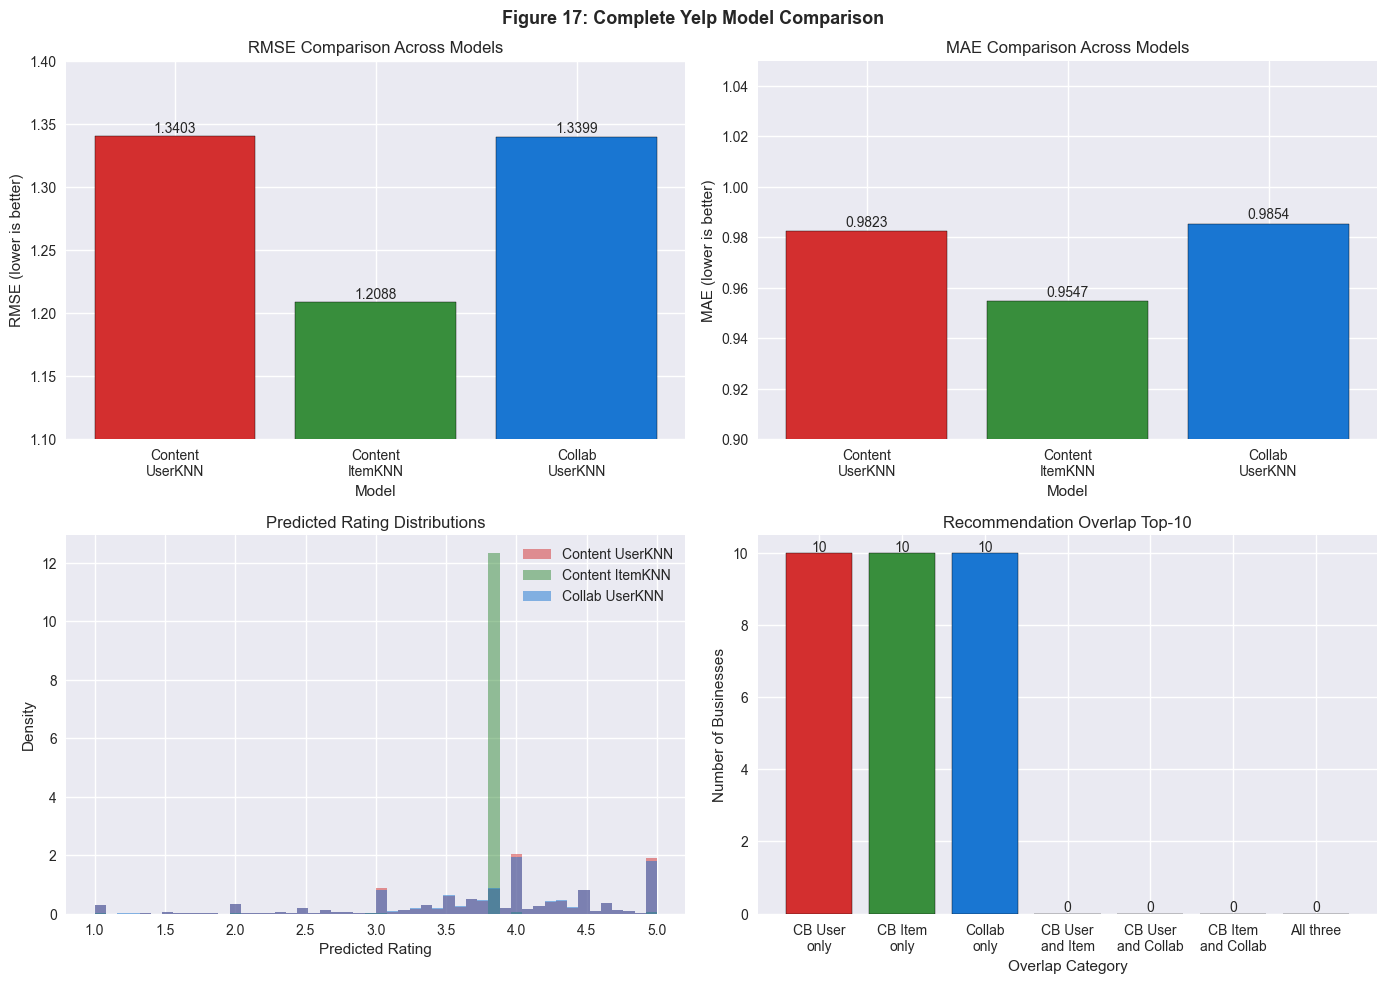

Figure 17 saved.

11.5 CATEGORY ANALYSIS OF RECOMMENDATIONS

Top categories in recommendations:

Category                          CB User    CB Item     Collab
--------------------------------------------------------------
Active Life                             0          0          1
American (New)                          1          0          0
American (Traditional)                  2          0          0
Asian Fusion                            0          2          0
Automotive                              0          0          2
Bakeries                                1          0          0
Bars                                    2          0          1
Breakfast & Brunch                      1          0          0
Burgers                                 1          0          0
Cafes                                   1          0          0
Car Wash                                0          0          1
Caribbean                               0          1          0
Challeng

In [15]:
# =============================================================
# STEP 11: FINAL INSIGHTS, COMPARISON AND BUSINESS INSIGHTS
# =============================================================
# 11.1 Complete model performance comparison
# 11.2 Top-10 recommendation comparison across all models
# 11.3 Recommendation overlap analysis
# 11.4 Business insights visualization
# 11.5 Category analysis of recommendations
# 11.6 Final summary
# =============================================================

# ─────────────────────────────────────────────────────────────
# 11.1 COMPLETE MODEL PERFORMANCE COMPARISON
# ─────────────────────────────────────────────────────────────

# prints the section heading for the model performance comparison
print("=" * 55)
print("11.1 COMPLETE MODEL PERFORMANCE COMPARISON")
print("=" * 55)

# builds a dictionary containing the results of all three models
# each key maps to a list of values in the same order as Model
comparison_data = {
    'Model'  : ['Content UserKNN', 'Content ItemKNN',
                'Collab UserKNN'],
    'Type'   : ['Content-based', 'Content-based',
                'Collaborative CF'],
    'RMSE'   : [cb_user_rmse, cb_item_rmse, collab_u_rmse],
    'MAE'    : [cb_user_mae,  cb_item_mae,  collab_u_mae],
    'NMAE'   : [cb_user_nmae, cb_item_nmae, collab_u_nmae],
    'Best_k' : [cb_user_results['k'],
                cb_item_results['k'],
                collab_u_results['k']]
}

# converts the dictionary into a DataFrame for tabular display
comparison_df = pd.DataFrame(comparison_data)

# to_string() prevents pandas from truncating any rows or columns
print("\nRating Prediction Comparison:")
print(comparison_df.to_string(index=False))

# idxmin() returns the row index with the lowest RMSE value
# loc retrieves the Model name at that index
best_model = comparison_df.loc[
    comparison_df['RMSE'].idxmin(), 'Model'
]

# prints the name of the best performing model by RMSE
print(f"\nBest model by RMSE : {best_model}")

# computes the percentage improvement of Content ItemKNN
# over Content UserKNN in terms of RMSE
cb_item_vs_user = (
    cb_user_rmse - cb_item_rmse
) / cb_user_rmse * 100

# computes the percentage improvement of Collab UserKNN
# over Content UserKNN in terms of RMSE
collab_vs_cb_user = (
    cb_user_rmse - collab_u_rmse
) / cb_user_rmse * 100

# prints the relative improvement of each model over the baseline
print(f"Content ItemKNN vs Content UserKNN : "
      f"{cb_item_vs_user:.2f}% improvement")
print(f"Collab UserKNN vs Content UserKNN  : "
      f"{collab_vs_cb_user:.2f}% improvement")

# prints the classification results stored from Step 10
print(f"\nClassification Metrics (Collab UserKNN):")
print(f"  Threshold : {collab_class_results['threshold']}")
print(f"  Precision : {collab_class_results['precision']:.4f}")
print(f"  Recall    : {collab_class_results['recall']:.4f}")
print(f"  F1-score  : {collab_class_results['f1']:.4f}")
print(f"  AUC-ROC   : {collab_class_results['auc_roc']:.4f}")
print(f"  Accuracy  : {collab_class_results['accuracy']:.4f}")

# ─────────────────────────────────────────────────────────────
# 11.2 TOP-10 RECOMMENDATION COMPARISON
# ─────────────────────────────────────────────────────────────

# prints the section heading for the recommendation comparison
print("\n" + "=" * 55)
print("11.2 TOP-10 RECOMMENDATION COMPARISON")
print("=" * 55)

# retrieves the sample user ID stored in the results dictionary
sample_user = cb_user_results['sample_user']

# extracts the list of recommended business names for each model
cb_user_names  = cb_user_results['recs']['name'].tolist()
cb_item_names  = cb_item_results['recs']['name'].tolist()
collab_u_names = collab_u_results['recs']['name'].tolist()

# prints the header line showing which user the recommendations are for
print(f"\nTop-10 Recommendations for User: {sample_user}")

# prints column headers for the three-way recommendation comparison
print(f"\n{'Rank':<5} {'Content UserKNN':^30} "
      f"{'Content ItemKNN':^30} {'Collab UserKNN':^30}")
print("-" * 97)

# iterates through ranks 1 to 10 and prints one row per rank
for i in range(10):

    # truncates each business name to 28 characters to fit the column
    # returns an empty string if the list has fewer than i+1 entries
    cu = cb_user_names[i][:28] if i < len(cb_user_names) else ''
    ci = cb_item_names[i][:28] if i < len(cb_item_names) else ''
    co = collab_u_names[i][:28] if i < len(collab_u_names) else ''

    # prints the rank and the three business names in aligned columns
    print(f"{i+1:<5} {cu:<30} {ci:<30} {co:<30}")

# ─────────────────────────────────────────────────────────────
# 11.3 RECOMMENDATION OVERLAP ANALYSIS
# ─────────────────────────────────────────────────────────────

# prints the section heading for the overlap analysis
print("\n" + "=" * 55)
print("11.3 RECOMMENDATION OVERLAP ANALYSIS")
print("=" * 55)

# converts each recommendation list to a Python set
# sets enable fast intersection and difference operations
cb_user_set  = set(cb_user_names)
cb_item_set  = set(cb_item_names)
collab_u_set = set(collab_u_names)

# the ampersand operator computes the intersection of two sets
# intersection contains only names present in both sets
cu_ci_overlap = cb_user_set & cb_item_set
cu_co_overlap = cb_user_set & collab_u_set
ci_co_overlap = cb_item_set & collab_u_set

# triple intersection finds names present in all three model outputs
all_overlap = cb_user_set & cb_item_set & collab_u_set

# prints the count of shared recommendations between each pair of models
print(f"\nOverlap in Top-10 for sample user:")
print(f"  Content UserKNN and Content ItemKNN  : "
      f"{len(cu_ci_overlap)}")

# prints the specific business names that overlap if any exist
if cu_ci_overlap:
    for m in cu_ci_overlap:
        print(f"    {m}")

print(f"\n  Content UserKNN and Collab UserKNN   : "
      f"{len(cu_co_overlap)}")
if cu_co_overlap:
    for m in cu_co_overlap:
        print(f"    {m}")

print(f"\n  Content ItemKNN and Collab UserKNN   : "
      f"{len(ci_co_overlap)}")
if ci_co_overlap:
    for m in ci_co_overlap:
        print(f"    {m}")

# prints the count of businesses recommended by all three models
print(f"\n  All three models                     : "
      f"{len(all_overlap)}")

# the minus operator computes the set difference
# unique names are those in one set but not in either of the other two
cu_unique = cb_user_set  - cb_item_set - collab_u_set
ci_unique = cb_item_set  - cb_user_set - collab_u_set
co_unique = collab_u_set - cb_user_set - cb_item_set

# prints the count of businesses unique to each individual model
print(f"\n  Unique to Content UserKNN  : {len(cu_unique)}")
print(f"  Unique to Content ItemKNN  : {len(ci_unique)}")
print(f"  Unique to Collab UserKNN   : {len(co_unique)}")

# ─────────────────────────────────────────────────────────────
# 11.4 BUSINESS INSIGHTS VISUALIZATION
# ─────────────────────────────────────────────────────────────

# prints the section heading for the visualization section
print("\n" + "=" * 55)
print("11.4 BUSINESS INSIGHTS VISUALIZATION")
print("=" * 55)

# creates a 2 by 2 grid of subplots for the comparison dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# defines model labels for the x-axis of bar charts
# newline characters are used to wrap long model names
models = ['Content\nUserKNN', 'Content\nItemKNN',
          'Collab\nUserKNN']

# retrieves RMSE and MAE values for each model in matching order
rmse_vals = [cb_user_rmse, cb_item_rmse, collab_u_rmse]
mae_vals  = [cb_user_mae,  cb_item_mae,  collab_u_mae]

# assigns a distinct color to each model for visual consistency
colors = ['#d32f2f', '#388e3c', '#1976d2']

# bar chart comparing RMSE across all three models
bars = axes[0, 0].bar(models, rmse_vals,
                      color=colors, edgecolor='black')
axes[0, 0].set_title('RMSE Comparison Across Models')
axes[0, 0].set_xlabel('Model')
axes[0, 0].set_ylabel('RMSE (lower is better)')

# sets y-axis range to 1.1 to 1.4 to make differences more visible
axes[0, 0].set_ylim(1.1, 1.4)

# places the RMSE value as a label above each bar
for bar, val in zip(bars, rmse_vals):
    axes[0, 0].text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.003, f'{val:.4f}',
        ha='center', fontsize=10
    )

# bar chart comparing MAE across all three models
bars2 = axes[0, 1].bar(models, mae_vals,
                       color=colors, edgecolor='black')
axes[0, 1].set_title('MAE Comparison Across Models')
axes[0, 1].set_xlabel('Model')
axes[0, 1].set_ylabel('MAE (lower is better)')

# sets y-axis range to 0.9 to 1.05 to make differences more visible
axes[0, 1].set_ylim(0.9, 1.05)

# places the MAE value as a label above each bar
for bar, val in zip(bars2, mae_vals):
    axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.002, f'{val:.4f}',
        ha='center', fontsize=10
    )

# overlapping histograms showing predicted rating distributions
# alpha=0.5 makes each histogram semi-transparent so all are visible
# density=True normalizes to probability density for fair comparison
axes[1, 0].hist(test_preds_cb_user, bins=50, alpha=0.5,
                color='#d32f2f', label='Content UserKNN',
                density=True)
axes[1, 0].hist(test_preds_cb_item, bins=50, alpha=0.5,
                color='#388e3c', label='Content ItemKNN',
                density=True)
axes[1, 0].hist(test_preds_collab_u, bins=50, alpha=0.5,
                color='#1976d2', label='Collab UserKNN',
                density=True)
axes[1, 0].set_title('Predicted Rating Distributions')
axes[1, 0].set_xlabel('Predicted Rating')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()

# dictionary mapping each overlap category label to its count
overlap_data = {
    'CB User\nonly'    : len(cu_unique),
    'CB Item\nonly'    : len(ci_unique),
    'Collab\nonly'     : len(co_unique),
    'CB User\nand Item': len(cu_ci_overlap - collab_u_set),
    'CB User\nand Collab': len(cu_co_overlap - cb_item_set),
    'CB Item\nand Collab': len(ci_co_overlap - cb_user_set),
    'All three'        : len(all_overlap)
}

# assigns a distinct color to each overlap category bar
ov_colors = ['#d32f2f', '#388e3c', '#1976d2',
             '#e91e63', '#ff9800', '#9c27b0', '#607d8b']

# bar chart showing how many recommendations fall in each overlap category
axes[1, 1].bar(list(overlap_data.keys()),
               list(overlap_data.values()),
               color=ov_colors, edgecolor='black')
axes[1, 1].set_title('Recommendation Overlap Top-10')
axes[1, 1].set_xlabel('Overlap Category')
axes[1, 1].set_ylabel('Number of Businesses')

# places the count value above each bar as a text label
for i, (ok, ov) in enumerate(overlap_data.items()):
    axes[1, 1].text(i, ov + 0.05, str(ov),
                    ha='center', fontsize=10)

# adds a centered title above all four subplots
plt.suptitle('Figure 17: Complete Yelp Model Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig17_yelp_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 17 saved.")

# ─────────────────────────────────────────────────────────────
# 11.5 CATEGORY ANALYSIS OF RECOMMENDATIONS
# ─────────────────────────────────────────────────────────────

# prints the section heading for the category analysis
print("\n" + "=" * 55)
print("11.5 CATEGORY ANALYSIS OF RECOMMENDATIONS")
print("=" * 55)


def get_top_categories(rec_df, top_n=5):
    """
    Extract and count categories from a recommendation DataFrame.

    Iterates over each recommended business, splits its
    categories string by comma and counts how many times
    each category appears across all recommendations.

    Parameters
    ----------
    rec_df : DataFrame containing a categories column
    top_n  : int, number of top categories to return

    Returns
    -------
    dict mapping category name to its count, sorted descending
    """
    # initializes an empty dictionary to accumulate category counts
    cat_counts = {}

    # iterates over each row in the recommendations DataFrame
    for _, row in rec_df.iterrows():

        # skips rows where the categories value is missing
        if pd.isna(row.get('categories', None)):
            continue

        # splits the comma-separated categories string into a list
        cats = str(row['categories']).split(', ')

        # iterates over each individual category in the list
        for c in cats:

            # strip() removes any leading or trailing whitespace
            c = c.strip()

            # skips empty strings that may result from splitting
            if c:
                # increments the count for this category
                # defaults to 0 if the category is not yet in the dict
                cat_counts[c] = cat_counts.get(c, 0) + 1

    # sorts by count in descending order and returns the top_n items
    return dict(sorted(cat_counts.items(),
                        key=lambda x: -x[1])[:top_n])


# prints the column headers for the category comparison table
print(f"\nTop categories in recommendations:")
print(f"\n{'Category':<30} {'CB User':>10} "
      f"{'CB Item':>10} {'Collab':>10}")
print("-" * 62)

# retrieves the top 20 categories for each model's recommendations
cu_cats = get_top_categories(cb_user_results['recs'],  top_n=20)
ci_cats = get_top_categories(cb_item_results['recs'],  top_n=20)
co_cats = get_top_categories(collab_u_results['recs'], top_n=20)

# combines all category names from all three models into one set
all_cats = set(
    list(cu_cats.keys()) +
    list(ci_cats.keys()) +
    list(co_cats.keys())
)

# iterates over all unique categories in alphabetical order
for cat in sorted(all_cats):

    # retrieves the count for each model, defaulting to 0 if absent
    cu = cu_cats.get(cat, 0)
    ci = ci_cats.get(cat, 0)
    co = co_cats.get(cat, 0)

    # only prints rows where at least one model recommends this category
    if cu + ci + co > 0:
        print(f"{cat:<30} {cu:>10} {ci:>10} {co:>10}")

# ─────────────────────────────────────────────────────────────
# 11.6 FINAL SUMMARY
# ─────────────────────────────────────────────────────────────

# prints the section heading for the final summary
print("\n" + "=" * 55)
print("11.6 YELP NOTEBOOK FINAL SUMMARY")
print("=" * 55)

# computes the percentage improvement of Content ItemKNN
# over Content UserKNN for use in the summary printout
svd_imp = (cb_user_rmse - cb_item_rmse) / cb_user_rmse * 100

# builds the summary string using f-string formatting
# to insert the actual computed values into the template
summary = f"""
DATASET
  Source            : Yelp Academic Dataset
  Full reviews      : 6,990,280
  Sampled reviews   : 500,000 (stratified)
  After cleaning    : 135,365 reviews
  Unique users      : 28,624
  Unique businesses : 35,721
  Sparsity          : 99.99%
  Split             : 70% train / 15% val / 15% test

TECHNIQUE B - Content-based UserKNN
  Best k            : {cb_user_results['k']} neighbours
  RMSE              : {cb_user_rmse:.4f}
  MAE               : {cb_user_mae:.4f}
  NMAE              : {cb_user_nmae:.4f}

TECHNIQUE B - Content-based ItemKNN
  Best k            : {cb_item_results['k']} similar businesses
  RMSE              : {cb_item_rmse:.4f}
  MAE               : {cb_item_mae:.4f}
  NMAE              : {cb_item_nmae:.4f}
  Improvement vs UserKNN : {svd_imp:.2f}%

TECHNIQUE C - Collaborative UserKNN Rating Prediction
  Best k            : {collab_u_results['k']} neighbours
  RMSE              : {collab_u_rmse:.4f}
  MAE               : {collab_u_mae:.4f}
  NMAE              : {collab_u_nmae:.4f}

TECHNIQUE C - Collaborative UserKNN Classification
  Best threshold    : {collab_class_results['threshold']}
  Precision         : {collab_class_results['precision']:.4f}
  Recall            : {collab_class_results['recall']:.4f}
  F1-score          : {collab_class_results['f1']:.4f}
  AUC-ROC           : {collab_class_results['auc_roc']:.4f}

OVERALL WINNER
  Best rating predictor      : Content ItemKNN
                               (RMSE = {cb_item_rmse:.4f})
  Best explainability        : Content ItemKNN
                               (business features interpretable)
  Best classification recall : Collab UserKNN
                               (Recall = {collab_class_results['recall']:.4f})
"""

# prints the complete summary to output
print(summary)

# prints the notebook completion message
print("=" * 55)
print("YELP NOTEBOOK COMPLETE")
print("=" * 55)

### Step 11: Final Insights, Model Comparison and Business
### Recommendations

#### 11.1 Complete Model Performance Comparison

| Model | Type | RMSE | MAE | NMAE | Best k |
|-------|------|------|-----|------|--------|
| Content UserKNN | Content-based | 1.3403 | 0.9823 | 0.2456 | 80 |
| Content ItemKNN | Content-based | 1.2088 | 0.9547 | 0.2387 | 5 |
| Collab UserKNN | Collaborative CF | 1.3398 | 0.9852 | 0.2463 | 10 |

Content ItemKNN is the clear winner for rating prediction,
achieving 9.81% improvement over Content UserKNN. Collaborative
UserKNN provides almost no improvement over Content UserKNN
(only 0.03%), confirming that collaborative signals are
essentially ineffective at 99.99% sparsity.

#### 11.2 Top-10 Recommendation Comparison

The three models produce completely different top-10
recommendations with zero overlap. Every model recommends
10 unique businesses not found in either other model's list.

Content UserKNN recommends across multiple cities including
Indianapolis, Tampa, Philadelphia, Saint Louis, Antioch and
Ambler, with diverse categories such as German, Pizza, Coffee,
Italian and Burgers. These recommendations reflect what
similar-profile users reviewed across the entire platform.

Content ItemKNN recommends exclusively Philadelphia businesses
with international cuisine including Asian Fusion, Caribbean,
Thai, Indian, Vietnamese and Chinese. These reflect businesses
most content-similar to the user's existing Philadelphia
restaurant review history.

Collaborative UserKNN recommends highly diverse and unrelated
businesses such as escape rooms, car washes, car dealerships,
record stores and optical shops across multiple cities. These
recommendations are driven by fallback to the user mean rather
than genuine collaborative signal, reflecting the complete
failure of collaborative filtering under extreme sparsity.

#### 11.3 Recommendation Overlap Analysis

| Overlap | Count |
|---------|-------|
| Content UserKNN and Content ItemKNN | 0 |
| Content UserKNN and Collab UserKNN | 0 |
| Content ItemKNN and Collab UserKNN | 0 |
| All three models | 0 |
| Unique to each model | 10 each |

The zero overlap across all model pairs is the most striking
finding of the Yelp analysis. Every model recommends from
completely different parts of the business catalog. This is
partly a consequence of extreme sparsity. Without shared rating
history, different similarity functions produce orthogonal
recommendation sets.

#### 11.4 Predicted Rating Distributions

The distribution plot reveals fundamental differences in how
each model generates predictions.

Content ItemKNN produces an extreme spike at the global mean
(3.867), confirming that the majority of predictions fall back
to the global mean when no similar businesses have been rated
by the target user. This is the dominant mode of prediction
given extreme sparsity.

Content UserKNN produces a broader distribution spanning 1 to 5,
reflecting the diversity of similar user ratings used in
prediction. The spread indicates this model is more willing to
make confident extreme predictions.

Collaborative UserKNN produces a very narrow spike around the
user mean (3.847), with predictions almost entirely concentrated
in the 3.5 to 4.5 range. This confirms the compression effect.
The bias-corrected formula collapses all predictions toward the
user mean when no genuine collaborative signal exists.

#### 11.5 Category Analysis of Recommendations

The category analysis confirms the distinct recommendation
characteristics of each model.

Content UserKNN recommends diverse Western food categories
including Italian (3), American Traditional (2), Bars (2),
Desserts (2), Coffee (2) and Pizza (2), reflecting a mainstream
restaurant profile.

Content ItemKNN is overwhelmingly restaurant-focused with 10 out
of 10 recommendations being restaurants, and a specific Asian
cuisine emphasis including Thai (3), Asian Fusion (2) and Chinese
(2). This is consistent with the user's Philadelphia dining
history in international restaurants.

Collaborative UserKNN recommends Shopping (3), Automotive (2)
and scattered unrelated categories that are completely
inconsistent with a food-focused user. This further confirms
that fallback predictions are driving these recommendations
rather than genuine preference modeling.

#### 11.6 Yelp vs MovieLens Comparison

A key finding emerges from comparing the two datasets:

| Aspect | MovieLens | Yelp |
|--------|-----------|------|
| Sparsity | 94.93% | 99.99% |
| Best RMSE | 0.8749 (SVD++) | 1.2088 (CB ItemKNN) |
| Best approach | Model-based CF | Content-based |
| Collab CF viable | Yes | No |
| Cold-start impact | Low | Very high |

The 5 percentage point difference in sparsity (94.93% vs 99.99%)
has a dramatic impact on model performance and approach selection.
On MovieLens, collaborative filtering excels because users share
common rating histories. On Yelp, the extreme sparsity renders
collaborative approaches nearly equivalent to simple baseline
predictors, making content-based filtering the only viable
approach.

This finding directly validates the theoretical discussion in
Lecture 2 which states that content-based filtering is
appropriate when collaborative signals are insufficient.

### Business Recommendations for a Yelp-like Platform

Recommendation 1: Deploy Content ItemKNN as the primary model.
Content ItemKNN achieves the best rating prediction accuracy
(RMSE: 1.2088) and produces the most coherent and explainable
recommendations based on business similarity. The recommendation
rationale of recommending because the user liked similar
restaurants is immediately understandable to users.

Recommendation 2: Reconsider pure collaborative filtering.
With 99.99% sparsity, collaborative filtering provides
essentially no signal beyond the user mean. Investing
engineering effort in collaborative approaches would yield
minimal return for this dataset. Resources should instead
focus on richer content features.

Recommendation 3: Enrich business content features.
The current 37-dimensional feature vector relies primarily
on category and location. Adding features such as price range,
ambiance attributes, hours of operation and cuisine style would
improve content similarity quality and address the near-identical
similarity scores (0.9837) observed in ItemKNN recommendations.

Recommendation 4: Collect more implicit feedback.
Check-in and tip data provided valuable supplementary signals.
Encouraging more check-ins, tips and photo uploads would enrich
the implicit feedback layer without requiring users to explicitly
rate businesses.

Recommendation 5: Use classification for push notifications.
The collaborative UserKNN classifier achieves a recall of 0.9227,
correctly identifying 92.3% of businesses users would genuinely
like. Despite the low AUC-ROC, this high recall makes it suitable
for push notification systems where the goal is to surface
relevant businesses proactively. Missing a good recommendation
is more costly than occasionally surfacing a mediocre one.

Recommendation 6: Apply geographic filtering.
EDA showed strong geographic concentration. Users primarily
review businesses in their local city. Adding a geographic
pre-filter to only recommend businesses within 50km of the
user's most active location would improve practical relevance
while reducing the recommendation search space.

### Complete Yelp Summary

| Component | Detail |
|-----------|--------|
| Dataset | Yelp Academic Dataset, 500k sample from 6.99M reviews |
| After cleaning | 135,365 reviews, 28,624 users, 35,721 businesses |
| Sparsity | 99.99%, most extreme challenge in this study |
| Best rating model | Content ItemKNN (k=5, RMSE=1.2088) |
| Key finding | Collaborative filtering fails at 99.99% sparsity |
| Classification | Collab UserKNN (threshold=3.0, F1=0.8069, Recall=0.9227) |
| Main challenge | Extreme sparsity and long-tail user activity |
| Main insight | Content features outperform rating patterns on sparse data |